# fMRIprep


**Author:** Steffen Bollmann

**Date:** 17 Oct 2024

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

### Citation and Resources

#### Tools included in this workflow

__fMRIPrep__:
- Esteban, O., Markiewicz, C.J., Blair, R.W. et al. fMRIPrep: a robust preprocessing pipeline for functional MRI. Nat Methods 16, 111–116 (2019). [https://doi.org/10.1038/s41592-018-0235-4](https://doi.org/10.1038/s41592-018-0235-4)
  
#### Dataset
__Flanker Dataset from OpenNeuro:__
- Kelly AMC and Uddin LQ and Biswal BB and Castellanos FX and Milham MP (2018). Flanker task (event-related). [OpenNeuro Dataset ds000102](https://openneuro.org/datasets/ds000102/versions/00001)
- Kelly, A. M., Uddin, L. Q., Biswal, B. B., Castellanos, F. X., & Milham, M. P. (2008). Competition between functional brain networks mediates behavioral variability. NeuroImage, 39(1), 527–537. [https://doi.org/10.1016/j.neuroimage.2007.08.008](https://doi.org/10.1016/j.neuroimage.2007.08.008)

#### Educational resources
- [fMRIPrep documentation](https://fmriprep.org/en/stable/)

## Demonstrationg fMRIprep on Neurodesk
Preprocessing is a critical step in fMRI analysis, converting raw fMRI data into a form ready for statistical analysis. fMRIPrep is a robust, automated preprocessing pipeline that performs basic processing steps (coregistration, normalization, unwarping, noise component extraction, segmentation, skull-stripping, etc.), providing outputs that can be easily submitted to a variety of group level analyses, including task-based or resting-state fMRI, graph theory measures, and surface or volume-based statistics. It combines tools from well-known software packages including FSL, ANTs, FreeSurfer and AFNI, and generates quality reports that allow users to easily identify outliers

In this notebook, we demonstrate how to run fMRIPrep on a BIDS-formatted dataset and explore examples of the outputs it generates.

![fMRIPrep workflow](https://github.com/oesteban/fmriprep/raw/f4c7a9804be26c912b24ef4dccba54bdd72fa1fd/docs/_static/fmriprep-21.0.0.svg)

### Load fMRIPrep and request FreeSurfer license

In [1]:
# load fmriprep
import module
import os
await module.load('fmriprep/24.1.0')
await module.list()

['fmriprep/24.1.0']

In [3]:
# Request a freesurfer license and store it in your homedirectory. This is just an exampe - please replace with your license id:
!echo "Steffen.Bollmann@cai.uq.edu.au" > ~/.license
!echo "21029" >> ~/.license
!echo "*Cqyn12sqTCxo" >> ~/.license
!echo "FSxgcvGkNR59Y" >> ~/.license

### Download Data

In [2]:
!datalad install https://github.com/OpenNeuroDatasets/ds000102.git
!cd ds000102 && datalad get sub-08

Cloning:   0%|                             | 0.00/2.00 [00:00<?, ? candidates/s]
Enumerating: 0.00 Objects [00:00, ? Objects/s]
                                              
Counting:   0%|                               | 0.00/27.0 [00:00<?, ? Objects/s]
                                                                                
Compressing:   0%|                            | 0.00/23.0 [00:00<?, ? Objects/s]
                                                                                
Receiving:   0%|                             | 0.00/2.15k [00:00<?, ? Objects/s]
                                                                                
Resolving:   0%|                                | 0.00/537 [00:00<?, ? Deltas/s]
[INFO   ] scanning for unlocked files (this may take some time)                 
[INFO   ] Remote origin not usable by git-annex; setting annex-ignore 
[INFO   ] access to 1 dataset sibling s3-PRIVATE not auto-enabled, enable with:
| 		datalad siblings -d "/

### Run fMRIPrep

In [ ]:
%%bash
# set up environment variables
export SUBJECTS_DIR=$PWD/fmriprep-freesurfer-dir
export APPTAINERENV_SUBJECTS_DIR=$SUBJECTS_DIR
export ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS=2 
export MPLCONFIGDIR=~/matplotlib-mpldir 

# create subjects directory
mkdir -p $SUBJECTS_DIR

# run fmriprep
fmriprep ds000102/ fmriprep-output participant \
--fs-license-file ~/.license \
--output-spaces T1w MNI152NLin2009cAsym fsaverage fsnative \
--participant-label 08 \
--nprocs $ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS \
--mem 10000 \
--skip_bids_validation \
--fs-subjects-dir $SUBJECTS_DIR \
-v


2025-11-04 05:45:18,452 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of optional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.io/en/latest/advanced-usage.html#socks-proxies
You are using fMRIPrep-24.1.0, and a newer version of fMRIPrep is available: 25.2.3.
Please check out our documentation about how and when to upgrade:
https://fmriprep.readthedocs.io/en/latest/faq.html#upgrading
2025-11-04 05:45:32,224 [    INFO] Telemetry system to collect crashes and errors is enabled - thanks for your feedback!. Use option ``--notrack`` to opt out.
2025-11-04 05:45:37,489 [ WARNING] WARNING: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
2025-11-04 05:46:06,557 [ WARNING] WARNING: sentry_sdk.configure_scope is deprecated and will be

251104-05:49:18,975 nipype.workflow IMPORTANT:
	 Running fMRIPrep version 24.1.0

         License NOTICE ##################################################
         fMRIPrep 24.1.0
         Copyright The NiPreps Developers.
         
         This product includes software developed by
         the NiPreps Community (https://nipreps.org/).
         
         Portions of this software were developed at the Department of
         Psychology at Stanford University, Stanford, CA, US.
         
         This software is also distributed as a Docker container image.
         The bootstrapping file for the image ("Dockerfile") is licensed
         under the MIT License.
         
         This software may be distributed through an add-on package called
         "Docker Wrapper" that is under the BSD 3-clause License.
         #################################################################


2025-11-04 05:49:18,975 [IMPORTANT] Running fMRIPrep version 24.1.0

         License NOTICE ##################################################
         fMRIPrep 24.1.0
         Copyright The NiPreps Developers.
         
         This product includes software developed by
         the NiPreps Community (https://nipreps.org/).
         
         Portions of this software were developed at the Department of
         Psychology at Stanford University, Stanford, CA, US.
         
         This software is also distributed as a Docker container image.
         The bootstrapping file for the image ("Dockerfile") is licensed
         under the MIT License.
         
         This software may be distributed through an add-on package called
         "Docker Wrapper" that is under the BSD 3-clause License.
         #################################################################


251104-05:49:19,11 nipype.workflow IMPORTANT:
	 Building fMRIPrep's workflow:
           * BIDS dataset path: /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/ds000102.
           * Participant list: ['08'].
           * Run identifier: 20251104-054520_0edf649f-f70d-41c3-969d-312e8fb1ad1a.
           * Output spaces: T1w MNI152NLin2009cAsym:res-native fsaverage:den-164k fsnative.
           * Pre-run FreeSurfer's SUBJECTS_DIR: /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir.


2025-11-04 05:49:19,011 [IMPORTANT] Building fMRIPrep's workflow:
           * BIDS dataset path: /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/ds000102.
           * Participant list: ['08'].
           * Run identifier: 20251104-054520_0edf649f-f70d-41c3-969d-312e8fb1ad1a.
           * Output spaces: T1w MNI152NLin2009cAsym:res-native fsaverage:den-164k fsnative.
           * Pre-run FreeSurfer's SUBJECTS_DIR: /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir.
100%|██████████| 13.7M/13.7M [00:01<00:00, 11.5MB/s]
100%|██████████| 160k/160k [00:00<00:00, 496kB/s] 


251104-05:50:10,896 nipype.workflow INFO:
	 ANAT Stage 1: Adding template workflow


2025-11-04 05:50:10,896 [    INFO] ANAT Stage 1: Adding template workflow
2025-11-04 05:50:22,029 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:50:22,029 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:50:22,295 nipype.workflow INFO:
	 ANAT Stage 2: Preparing brain extraction workflow


2025-11-04 05:50:22,295 [    INFO] ANAT Stage 2: Preparing brain extraction workflow
100%|██████████| 32.4M/32.4M [00:01<00:00, 16.3MB/s]
100%|██████████| 2.59M/2.59M [00:00<00:00, 3.82MB/s]
100%|██████████| 265k/265k [00:00<00:00, 617kB/s]  
100%|██████████| 4.06M/4.06M [00:00<00:00, 5.18MB/s]
100%|██████████| 447k/447k [00:00<00:00, 1.03MB/s] 


251104-05:50:30,102 nipype.workflow INFO:
	 ANAT Stage 3: Preparing segmentation workflow


2025-11-04 05:50:30,102 [    INFO] ANAT Stage 3: Preparing segmentation workflow


251104-05:50:30,211 nipype.workflow INFO:
	 ANAT Stage 4: Preparing normalization workflow for ['MNI152NLin2009cAsym']


2025-11-04 05:50:30,211 [    INFO] ANAT Stage 4: Preparing normalization workflow for ['MNI152NLin2009cAsym']


251104-05:50:30,340 nipype.workflow INFO:
	 ANAT Stage 5: Preparing surface reconstruction workflow


2025-11-04 05:50:30,340 [    INFO] ANAT Stage 5: Preparing surface reconstruction workflow


251104-05:50:30,467 nipype.workflow INFO:
	 ANAT Stage 6: Preparing mask refinement workflow


2025-11-04 05:50:30,467 [    INFO] ANAT Stage 6: Preparing mask refinement workflow


251104-05:50:30,471 nipype.workflow INFO:
	 ANAT No T2w images provided - skipping Stage 7


2025-11-04 05:50:30,471 [    INFO] ANAT No T2w images provided - skipping Stage 7


251104-05:50:30,471 nipype.workflow INFO:
	 ANAT Stage 8: Creating GIFTI surfaces for ['white', 'pial', 'midthickness', 'sphere_reg', 'sphere']


2025-11-04 05:50:30,471 [    INFO] ANAT Stage 8: Creating GIFTI surfaces for ['white', 'pial', 'midthickness', 'sphere_reg', 'sphere']


251104-05:50:30,490 nipype.workflow INFO:
	 ANAT Stage 8: Creating GIFTI metrics for ['thickness', 'sulc']


2025-11-04 05:50:30,490 [    INFO] ANAT Stage 8: Creating GIFTI metrics for ['thickness', 'sulc']


251104-05:50:30,498 nipype.workflow INFO:
	 ANAT Stage 8a: Creating cortical ribbon mask


2025-11-04 05:50:30,498 [    INFO] ANAT Stage 8a: Creating cortical ribbon mask


251104-05:50:30,502 nipype.workflow INFO:
	 ANAT Stage 9: Creating fsLR registration sphere


2025-11-04 05:50:30,502 [    INFO] ANAT Stage 9: Creating fsLR registration sphere


251104-05:50:30,508 nipype.workflow INFO:
	 ANAT Stage 10: Creating MSM-Sulc registration sphere


2025-11-04 05:50:30,508 [    INFO] ANAT Stage 10: Creating MSM-Sulc registration sphere


251104-05:50:31,637 nipype.workflow INFO:
	 No single-band-reference found for sub-08_task-flanker_run-1_bold.nii.gz.


2025-11-04 05:50:31,637 [    INFO] No single-band-reference found for sub-08_task-flanker_run-1_bold.nii.gz.


251104-05:50:33,62 nipype.workflow INFO:
	 Stage 1: Adding HMC boldref workflow


2025-11-04 05:50:33,062 [    INFO] Stage 1: Adding HMC boldref workflow


251104-05:50:33,176 nipype.workflow INFO:
	 Stage 2: Adding motion correction workflow


2025-11-04 05:50:33,176 [    INFO] Stage 2: Adding motion correction workflow


251104-05:50:33,498 nipype.workflow INFO:
	 Stage 3: Adding coregistration boldref workflow


2025-11-04 05:50:33,498 [    INFO] Stage 3: Adding coregistration boldref workflow
2025-11-04 05:50:33,500 [ WARNING] WARNING: niworkflows.interfaces.nibabel.BinaryDilation is deprecated in favor of
niworkflows.interfaces.morphology.BinaryDilation. Please validate that
interface for your use case and switch.

100%|██████████| 1.75M/1.75M [00:00<00:00, 2.89MB/s]
100%|██████████| 29.6k/29.6k [00:00<00:00, 273kB/s] 
100%|██████████| 3.93M/3.93M [00:00<00:00, 5.67MB/s]
100%|██████████| 451k/451k [00:00<00:00, 1.04MB/s]


251104-05:50:38,70 nipype.workflow INFO:
	 No single-band-reference found for sub-08_task-flanker_run-2_bold.nii.gz.


2025-11-04 05:50:38,070 [    INFO] No single-band-reference found for sub-08_task-flanker_run-2_bold.nii.gz.


251104-05:50:38,135 nipype.workflow INFO:
	 Stage 1: Adding HMC boldref workflow


2025-11-04 05:50:38,135 [    INFO] Stage 1: Adding HMC boldref workflow


251104-05:50:38,142 nipype.workflow INFO:
	 Stage 2: Adding motion correction workflow


2025-11-04 05:50:38,142 [    INFO] Stage 2: Adding motion correction workflow


251104-05:50:38,148 nipype.workflow INFO:
	 Stage 3: Adding coregistration boldref workflow


2025-11-04 05:50:38,148 [    INFO] Stage 3: Adding coregistration boldref workflow
2025-11-04 05:50:38,150 [ WARNING] WARNING: niworkflows.interfaces.nibabel.BinaryDilation is deprecated in favor of
niworkflows.interfaces.morphology.BinaryDilation. Please validate that
interface for your use case and switch.

2025-11-04 05:50:42,523 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of optional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.io/en/latest/advanced-usage.html#socks-proxies
2025-11-04 05:50:42,778 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a standalone library "nireports".
2025-11-04 05:50:42,889 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor of a standalone library "nireports".


251104-05:50:45,10 nipype.workflow INFO:
	 fMRIPrep workflow graph with 580 nodes built successfully.


2025-11-04 05:50:45,010 [    INFO] fMRIPrep workflow graph with 580 nodes built successfully.
2025-11-04 05:50:49,139 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a standalone library "nireports".
2025-11-04 05:50:49,218 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor of a standalone library "nireports".
2025-11-04 05:51:00,806 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of optional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.io/en/latest/advanced-usage.html#socks-proxies
2025-11-04 05:51:01,096 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a standalone library "nireports".
2025-11-04 05:51:01,176 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor of a standalone library "nireports".
2025-11-04 05:51:09,945 [ WARNING] WARNING: sentry_sdk.configure_scope is deprecated and will be removed in the next major

251104-05:51:30,526 nipype.workflow IMPORTANT:
	 fMRIPrep started!


2025-11-04 05:51:30,526 [IMPORTANT] fMRIPrep started!


251104-05:52:17,704 nipype.workflow INFO:
	 Workflow fmriprep_24_1_wf settings: ['check', 'execution', 'logging', 'monitoring']


2025-11-04 05:52:17,704 [    INFO] Workflow fmriprep_24_1_wf settings: ['check', 'execution', 'logging', 'monitoring']


251104-05:52:18,173 nipype.workflow INFO:
	 Running in parallel.


2025-11-04 05:52:18,173 [    INFO] Running in parallel.


251104-05:52:18,176 nipype.workflow WARNING:
	 Some nodes exceed the total amount of memory available (10.00GB).


2025-11-04 05:52:18,176 [ WARNING] Some nodes exceed the total amount of memory available (10.00GB).


251104-05:52:18,185 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 21 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:52:18,185 [    INFO] [MultiProc] Running 0 tasks, and 21 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:52:18,427 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a".


2025-11-04 05:52:18,427 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a".


251104-05:52:18,429 nipype.workflow INFO:
	 [Node] Executing "fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a" <niworkflows.interfaces.bids.BIDSFreeSurferDir>


2025-11-04 05:52:18,429 [    INFO] [Node] Executing "fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a" <niworkflows.interfaces.bids.BIDSFreeSurferDir>


251104-05:53:09,319 nipype.workflow INFO:
	 [Node] Finished "fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a", elapsed time 50.879164s.


2025-11-04 05:53:09,319 [    INFO] [Node] Finished "fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a", elapsed time 50.879164s.


251104-05:53:09,322 nipype.workflow INFO:
	 [Job 0] Completed (fmriprep_24_1_wf.fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a).


2025-11-04 05:53:09,322 [    INFO] [Job 0] Completed (fmriprep_24_1_wf.fsdir_run_20251104_054520_0edf649f_f70d_41c3_969d_312e8fb1ad1a).


251104-05:53:09,532 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.about" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/about".


2025-11-04 05:53:09,532 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.about" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/about".


251104-05:53:09,541 nipype.workflow INFO:
	 [Node] Executing "about" <fmriprep.interfaces.reports.AboutSummary>


2025-11-04 05:53:09,541 [    INFO] [Node] Executing "about" <fmriprep.interfaces.reports.AboutSummary>


251104-05:53:09,542 nipype.workflow INFO:
	 [Node] Finished "about", elapsed time 0.000249s.


2025-11-04 05:53:09,542 [    INFO] [Node] Finished "about", elapsed time 0.000249s.


251104-05:53:09,549 nipype.workflow INFO:
	 [Job 2] Completed (fmriprep_24_1_wf.sub_08_wf.about).


2025-11-04 05:53:09,549 [    INFO] [Job 2] Completed (fmriprep_24_1_wf.sub_08_wf.about).


251104-05:53:09,769 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 17 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl
                       * fmriprep_24_1_wf.sub_08_wf.bidssrc


2025-11-04 05:53:09,769 [    INFO] [MultiProc] Running 2 tasks, and 17 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl
                       * fmriprep_24_1_wf.sub_08_wf.bidssrc


251104-05:53:14,560 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_tmpl".


2025-11-04 05:53:14,560 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_tmpl".


251104-05:53:14,562 nipype.workflow INFO:
	 [Node] Executing "res_tmpl" <niworkflows.interfaces.nibabel.RegridToZooms>


2025-11-04 05:53:14,562 [    INFO] [Node] Executing "res_tmpl" <niworkflows.interfaces.nibabel.RegridToZooms>


251104-05:53:16,951 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bidssrc" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bidssrc".


2025-11-04 05:53:16,951 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bidssrc" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bidssrc".


251104-05:53:16,953 nipype.workflow INFO:
	 [Node] Executing "bidssrc" <niworkflows.interfaces.bids.BIDSDataGrabber>


2025-11-04 05:53:16,953 [    INFO] [Node] Executing "bidssrc" <niworkflows.interfaces.bids.BIDSDataGrabber>


251104-05:53:16,963 nipype.interface INFO:
	 No "t2w" images found for sub-08
251104-05:53:16,963 nipype.interface INFO:
	 No "flair" images found for sub-08


2025-11-04 05:53:16,963 [    INFO] No "t2w" images found for sub-08
2025-11-04 05:53:16,963 [    INFO] No "flair" images found for sub-08


251104-05:53:16,963 nipype.interface INFO:
	 No "fmap" images found for sub-08
251104-05:53:16,963 nipype.interface INFO:
	 No "sbref" images found for sub-08
251104-05:53:16,963 nipype.interface INFO:
	 No "roi" images found for sub-08
251104-05:53:16,963 nipype.interface INFO:
	 No "pet" images found for sub-08
251104-05:53:16,963 nipype.interface INFO:
	 No "asl" images found for sub-08
251104-05:53:16,964 nipype.workflow INFO:
	 [Node] Finished "bidssrc", elapsed time 0.000792s.


2025-11-04 05:53:16,963 [    INFO] No "fmap" images found for sub-08
2025-11-04 05:53:16,963 [    INFO] No "sbref" images found for sub-08
2025-11-04 05:53:16,963 [    INFO] No "roi" images found for sub-08
2025-11-04 05:53:16,963 [    INFO] No "pet" images found for sub-08
2025-11-04 05:53:16,963 [    INFO] No "asl" images found for sub-08
2025-11-04 05:53:16,964 [    INFO] [Node] Finished "bidssrc", elapsed time 0.000792s.


251104-05:53:17,406 nipype.workflow INFO:
	 [Node] Finished "res_tmpl", elapsed time 2.840941s.


2025-11-04 05:53:17,406 [    INFO] [Node] Finished "res_tmpl", elapsed time 2.840941s.


251104-05:53:17,768 nipype.workflow INFO:
	 [Job 1] Completed (fmriprep_24_1_wf.sub_08_wf.bidssrc).


2025-11-04 05:53:17,768 [    INFO] [Job 1] Completed (fmriprep_24_1_wf.sub_08_wf.bidssrc).


251104-05:53:17,770 nipype.workflow INFO:
	 [Job 3] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl).


2025-11-04 05:53:17,770 [    INFO] [Job 3] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl).


251104-05:53:17,772 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 20 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:17,772 [    INFO] [MultiProc] Running 0 tasks, and 20 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:17,985 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.full_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/full_wm".


2025-11-04 05:53:17,985 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.full_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/full_wm".


251104-05:53:17,986 nipype.workflow INFO:
	 [Node] Executing "full_wm" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:53:17,986 [    INFO] [Node] Executing "full_wm" <nipype.interfaces.utility.wrappers.Function>


251104-05:53:18,8 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_tmpl".


2025-11-04 05:53:18,008 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_tmpl".


251104-05:53:18,10 nipype.workflow INFO:
	 [Node] Executing "lap_tmpl" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 05:53:18,010 [    INFO] [Node] Executing "lap_tmpl" <nipype.interfaces.ants.utils.ImageMath>


251104-05:53:18,538 nipype.workflow INFO:
	 [Node] Finished "full_wm", elapsed time 0.551361s.


2025-11-04 05:53:18,538 [    INFO] [Node] Finished "full_wm", elapsed time 0.551361s.
2025-11-04 05:53:19,061 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:53:19,062 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:53:19,768 nipype.workflow INFO:
	 [Job 4] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.full_wm).


2025-11-04 05:53:19,768 [    INFO] [Job 4] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.full_wm).


251104-05:53:19,771 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2025-11-04 05:53:19,771 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


251104-05:53:19,982 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/val_bold".


2025-11-04 05:53:19,982 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/val_bold".


251104-05:53:19,983 nipype.workflow INFO:
	 [Node] Executing "val_bold" <niworkflows.interfaces.header.ValidateImage>


2025-11-04 05:53:19,983 [    INFO] [Node] Executing "val_bold" <niworkflows.interfaces.header.ValidateImage>


251104-05:53:20,41 nipype.workflow INFO:
	 [Node] Finished "val_bold", elapsed time 0.057306s.


2025-11-04 05:53:20,041 [    INFO] [Node] Finished "val_bold", elapsed time 0.057306s.


251104-05:53:21,769 nipype.workflow INFO:
	 [Job 6] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


2025-11-04 05:53:21,769 [    INFO] [Job 6] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


251104-05:53:21,771 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2025-11-04 05:53:21,771 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


251104-05:53:21,982 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/get_dummy".


2025-11-04 05:53:21,982 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/get_dummy".


251104-05:53:21,984 nipype.workflow INFO:
	 [Node] Executing "get_dummy" <niworkflows.interfaces.bold.NonsteadyStatesDetector>


2025-11-04 05:53:21,984 [    INFO] [Node] Executing "get_dummy" <niworkflows.interfaces.bold.NonsteadyStatesDetector>


251104-05:53:22,724 nipype.workflow INFO:
	 [Node] Finished "get_dummy", elapsed time 0.739271s.


2025-11-04 05:53:22,724 [    INFO] [Node] Finished "get_dummy", elapsed time 0.739271s.


251104-05:53:23,769 nipype.workflow INFO:
	 [Job 7] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


2025-11-04 05:53:23,769 [    INFO] [Job 7] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


251104-05:53:23,771 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 19 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2025-11-04 05:53:23,771 [    INFO] [MultiProc] Running 1 tasks, and 19 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


251104-05:53:23,990 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_boldref_wf/sources".


2025-11-04 05:53:23,990 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_boldref_wf/sources".


251104-05:53:23,992 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 05:53:23,992 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-05:53:23,992 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000219s.


2025-11-04 05:53:23,992 [    INFO] [Node] Finished "sources", elapsed time 0.000219s.


251104-05:53:25,769 nipype.workflow INFO:
	 [Job 8] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


2025-11-04 05:53:25,769 [    INFO] [Job 8] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


251104-05:53:25,772 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2025-11-04 05:53:25,772 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


251104-05:53:25,970 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/sources".


2025-11-04 05:53:25,970 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/sources".


251104-05:53:25,973 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 05:53:25,973 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-05:53:25,974 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.00038s.


2025-11-04 05:53:25,974 [    INFO] [Node] Finished "sources", elapsed time 0.00038s.
2025-11-04 05:53:27,547 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:53:27,547 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:53:27,769 nipype.workflow INFO:
	 [Job 9] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.sources).


2025-11-04 05:53:27,769 [    INFO] [Job 9] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.sources).


251104-05:53:27,772 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2025-11-04 05:53:27,772 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


251104-05:53:27,990 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask_wf/sources".


2025-11-04 05:53:27,990 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask_wf/sources".


251104-05:53:27,992 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 05:53:27,992 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-05:53:27,993 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000243s.


2025-11-04 05:53:27,993 [    INFO] [Node] Finished "sources", elapsed time 0.000243s.


251104-05:53:29,237 nipype.workflow INFO:
	 [Node] Finished "lap_tmpl", elapsed time 10.100717s.


2025-11-04 05:53:29,237 [    INFO] [Node] Finished "lap_tmpl", elapsed time 10.100717s.


251104-05:53:29,769 nipype.workflow INFO:
	 [Job 5] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl).


2025-11-04 05:53:29,769 [    INFO] [Job 5] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl).


251104-05:53:29,771 nipype.workflow INFO:
	 [Job 10] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.sources).


2025-11-04 05:53:29,771 [    INFO] [Job 10] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.sources).


251104-05:53:29,773 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:29,773 [    INFO] [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:29,973 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.bold_source" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/bold_source".


2025-11-04 05:53:29,973 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.bold_source" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/bold_source".


251104-05:53:29,975 nipype.workflow INFO:
	 [Node] Executing "bold_source" <nipype.interfaces.utility.base.Select>


2025-11-04 05:53:29,975 [    INFO] [Node] Executing "bold_source" <nipype.interfaces.utility.base.Select>


251104-05:53:29,977 nipype.workflow INFO:
	 [Node] Finished "bold_source", elapsed time 0.000376s.


2025-11-04 05:53:29,977 [    INFO] [Node] Finished "bold_source", elapsed time 0.000376s.


251104-05:53:29,980 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/val_bold".


2025-11-04 05:53:29,980 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/val_bold".


251104-05:53:29,982 nipype.workflow INFO:
	 [Node] Executing "val_bold" <niworkflows.interfaces.header.ValidateImage>


2025-11-04 05:53:29,982 [    INFO] [Node] Executing "val_bold" <niworkflows.interfaces.header.ValidateImage>


251104-05:53:30,37 nipype.workflow INFO:
	 [Node] Finished "val_bold", elapsed time 0.054819s.


2025-11-04 05:53:30,037 [    INFO] [Node] Finished "val_bold", elapsed time 0.054819s.


251104-05:53:31,770 nipype.workflow INFO:
	 [Job 11] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.bold_source).


2025-11-04 05:53:31,770 [    INFO] [Job 11] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.bold_source).


251104-05:53:31,771 nipype.workflow INFO:
	 [Job 12] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


2025-11-04 05:53:31,771 [    INFO] [Job 12] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


251104-05:53:31,773 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:31,773 [    INFO] [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:31,979 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/get_dummy".


2025-11-04 05:53:31,979 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/get_dummy".


251104-05:53:31,981 nipype.workflow INFO:
	 [Node] Executing "get_dummy" <niworkflows.interfaces.bold.NonsteadyStatesDetector>


2025-11-04 05:53:31,981 [    INFO] [Node] Executing "get_dummy" <niworkflows.interfaces.bold.NonsteadyStatesDetector>


251104-05:53:32,617 nipype.workflow INFO:
	 [Node] Finished "get_dummy", elapsed time 0.63559s.


2025-11-04 05:53:32,617 [    INFO] [Node] Finished "get_dummy", elapsed time 0.63559s.


251104-05:53:33,354 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_boldref_wf/sources".


2025-11-04 05:53:33,354 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_boldref_wf/sources".


251104-05:53:33,356 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 05:53:33,356 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-05:53:33,357 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000233s.


2025-11-04 05:53:33,357 [    INFO] [Node] Finished "sources", elapsed time 0.000233s.


251104-05:53:33,770 nipype.workflow INFO:
	 [Job 13] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


2025-11-04 05:53:33,770 [    INFO] [Job 13] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


251104-05:53:33,771 nipype.workflow INFO:
	 [Job 14] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


2025-11-04 05:53:33,771 [    INFO] [Job 14] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


251104-05:53:33,773 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:33,773 [    INFO] [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:33,978 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/sources".
251104-05:53:33,978 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask_wf/sources".


2025-11-04 05:53:33,978 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/sources".
2025-11-04 05:53:33,978 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask_wf/sources".


251104-05:53:33,980 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>
251104-05:53:33,980 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 05:53:33,980 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>
2025-11-04 05:53:33,980 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-05:53:33,980 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000217s.
251104-05:53:33,980 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000222s.


2025-11-04 05:53:33,980 [    INFO] [Node] Finished "sources", elapsed time 0.000217s.
2025-11-04 05:53:33,980 [    INFO] [Node] Finished "sources", elapsed time 0.000222s.


251104-05:53:35,770 nipype.workflow INFO:
	 [Job 15] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.sources).


2025-11-04 05:53:35,770 [    INFO] [Job 15] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.sources).


251104-05:53:35,771 nipype.workflow INFO:
	 [Job 16] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.sources).


2025-11-04 05:53:35,771 [    INFO] [Job 16] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.sources).


251104-05:53:35,773 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 15 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:35,773 [    INFO] [MultiProc] Running 0 tasks, and 15 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:35,972 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.split_desc" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/split_desc".


2025-11-04 05:53:35,972 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.split_desc" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/split_desc".
2025-11-04 05:53:35,973 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.bold_source" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/bold_source".


251104-05:53:35,973 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.bold_source" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/bold_source".
251104-05:53:35,974 nipype.workflow INFO:
	 [Node] Executing "split_desc" <smriprep.interfaces.templateflow.TemplateDesc>
251104-05:53:35,975 nipype.workflow INFO:
	 [Node] Finished "split_desc", elapsed time 0.000127s.
251104-05:53:35,975 nipype.workflow INFO:
	 [Node] Executing "bold_source" <nipype.interfaces.utility.base.Select>


2025-11-04 05:53:35,974 [    INFO] [Node] Executing "split_desc" <smriprep.interfaces.templateflow.TemplateDesc>
2025-11-04 05:53:35,975 [    INFO] [Node] Finished "split_desc", elapsed time 0.000127s.
2025-11-04 05:53:35,975 [    INFO] [Node] Executing "bold_source" <nipype.interfaces.utility.base.Select>


251104-05:53:35,976 nipype.workflow INFO:
	 [Job 18] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.split_desc).


2025-11-04 05:53:35,976 [    INFO] [Job 18] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.split_desc).
2025-11-04 05:53:35,977 [    INFO] [Node] Finished "bold_source", elapsed time 0.000353s.


251104-05:53:35,977 nipype.workflow INFO:
	 [Node] Finished "bold_source", elapsed time 0.000353s.
251104-05:53:36,181 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.spacesource" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/spacesource".


2025-11-04 05:53:36,181 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.spacesource" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/spacesource".


251104-05:53:36,182 nipype.workflow INFO:
	 [Node] Executing "spacesource" <niworkflows.interfaces.space.SpaceDataSource>
251104-05:53:36,183 nipype.workflow INFO:
	 [Node] Finished "spacesource", elapsed time 0.000143s.


2025-11-04 05:53:36,182 [    INFO] [Node] Executing "spacesource" <niworkflows.interfaces.space.SpaceDataSource>
2025-11-04 05:53:36,183 [    INFO] [Node] Finished "spacesource", elapsed time 0.000143s.


251104-05:53:36,184 nipype.workflow INFO:
	 [Job 19] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.spacesource).


2025-11-04 05:53:36,184 [    INFO] [Job 19] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.spacesource).


251104-05:53:36,386 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.spacesource" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/spacesource".


2025-11-04 05:53:36,386 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.spacesource" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/spacesource".


251104-05:53:36,388 nipype.workflow INFO:
	 [Node] Executing "spacesource" <niworkflows.interfaces.space.SpaceDataSource>


2025-11-04 05:53:36,388 [    INFO] [Node] Executing "spacesource" <niworkflows.interfaces.space.SpaceDataSource>


251104-05:53:36,388 nipype.workflow INFO:
	 [Node] Finished "spacesource", elapsed time 0.000133s.


2025-11-04 05:53:36,388 [    INFO] [Node] Finished "spacesource", elapsed time 0.000133s.


251104-05:53:36,390 nipype.workflow INFO:
	 [Job 20] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.spacesource).


2025-11-04 05:53:36,390 [    INFO] [Job 20] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.spacesource).


251104-05:53:36,595 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bids_info" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bids_info".


2025-11-04 05:53:36,595 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bids_info" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bids_info".


251104-05:53:36,598 nipype.workflow INFO:
	 [Node] Executing "bids_info" <niworkflows.interfaces.bids.BIDSInfo>


2025-11-04 05:53:36,598 [    INFO] [Node] Executing "bids_info" <niworkflows.interfaces.bids.BIDSInfo>


251104-05:53:36,604 nipype.workflow INFO:
	 [Node] Finished "bids_info", elapsed time 0.005942s.


2025-11-04 05:53:36,604 [    INFO] [Node] Finished "bids_info", elapsed time 0.005942s.


251104-05:53:37,770 nipype.workflow INFO:
	 [Job 17] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.bold_source).


2025-11-04 05:53:37,770 [    INFO] [Job 17] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.bold_source).


251104-05:53:37,772 nipype.workflow INFO:
	 [Job 21] Completed (fmriprep_24_1_wf.sub_08_wf.bids_info).


2025-11-04 05:53:37,772 [    INFO] [Job 21] Completed (fmriprep_24_1_wf.sub_08_wf.bids_info).


251104-05:53:37,776 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 19 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:37,776 [    INFO] [MultiProc] Running 0 tasks, and 19 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:37,981 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_about" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_report_about".


2025-11-04 05:53:37,981 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_about" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_report_about".


251104-05:53:37,986 nipype.workflow INFO:
	 [Node] Executing "ds_report_about" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 05:53:37,986 [    INFO] [Node] Executing "ds_report_about" <fmriprep.interfaces.DerivativesDataSink>


251104-05:53:37,987 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_ref_dimensions" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/anat_ref_dimensions".


2025-11-04 05:53:37,987 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_ref_dimensions" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/anat_ref_dimensions".


251104-05:53:37,989 nipype.workflow INFO:
	 [Node] Executing "anat_ref_dimensions" <niworkflows.interfaces.images.TemplateDimensions>


2025-11-04 05:53:37,989 [    INFO] [Node] Executing "anat_ref_dimensions" <niworkflows.interfaces.images.TemplateDimensions>


251104-05:53:37,996 nipype.workflow INFO:
	 [Node] Finished "ds_report_about", elapsed time 0.009218s.


2025-11-04 05:53:37,996 [    INFO] [Node] Finished "ds_report_about", elapsed time 0.009218s.


251104-05:53:37,998 nipype.workflow INFO:
	 [Job 23] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report_about).


2025-11-04 05:53:37,998 [    INFO] [Job 23] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report_about).


251104-05:53:38,214 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_tmpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_tmpl".


2025-11-04 05:53:38,214 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_tmpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_tmpl".


251104-05:53:38,216 nipype.workflow INFO:
	 [Node] Executing "mrg_tmpl" <nipype.interfaces.utility.base.Merge>


2025-11-04 05:53:38,216 [    INFO] [Node] Executing "mrg_tmpl" <nipype.interfaces.utility.base.Merge>


251104-05:53:38,217 nipype.workflow INFO:
	 [Node] Finished "mrg_tmpl", elapsed time 0.000177s.


2025-11-04 05:53:38,217 [    INFO] [Node] Finished "mrg_tmpl", elapsed time 0.000177s.


251104-05:53:38,307 nipype.workflow INFO:
	 [Node] Finished "anat_ref_dimensions", elapsed time 0.317032s.


2025-11-04 05:53:38,307 [    INFO] [Node] Finished "anat_ref_dimensions", elapsed time 0.317032s.


251104-05:53:39,770 nipype.workflow INFO:
	 [Job 22] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_ref_dimensions).


2025-11-04 05:53:39,770 [    INFO] [Job 22] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_ref_dimensions).


251104-05:53:39,772 nipype.workflow INFO:
	 [Job 24] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_tmpl).


2025-11-04 05:53:39,772 [    INFO] [Job 24] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_tmpl).


251104-05:53:39,774 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 20 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:39,774 [    INFO] [MultiProc] Running 0 tasks, and 20 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:39,972 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_reports_wf/ds_report_validation".


2025-11-04 05:53:39,972 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_reports_wf/ds_report_validation".


251104-05:53:39,976 nipype.workflow INFO:
	 [Node] Executing "ds_report_validation" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 05:53:39,976 [    INFO] [Node] Executing "ds_report_validation" <fmriprep.interfaces.DerivativesDataSink>


251104-05:53:39,983 nipype.workflow INFO:
	 [Node] Finished "ds_report_validation", elapsed time 0.006549s.


2025-11-04 05:53:39,983 [    INFO] [Node] Finished "ds_report_validation", elapsed time 0.006549s.


251104-05:53:39,985 nipype.workflow INFO:
	 [Job 25] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


2025-11-04 05:53:39,985 [    INFO] [Job 25] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


251104-05:53:40,182 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/calc_dummy_scans".


2025-11-04 05:53:40,182 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/calc_dummy_scans".


251104-05:53:40,185 nipype.workflow INFO:
	 [Node] Executing "calc_dummy_scans" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:53:40,185 [    INFO] [Node] Executing "calc_dummy_scans" <nipype.interfaces.utility.wrappers.Function>


251104-05:53:40,186 nipype.workflow INFO:
	 [Node] Finished "calc_dummy_scans", elapsed time 0.000346s.


2025-11-04 05:53:40,186 [    INFO] [Node] Finished "calc_dummy_scans", elapsed time 0.000346s.


251104-05:53:40,186 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/gen_avg".


2025-11-04 05:53:40,186 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/gen_avg".


251104-05:53:40,187 nipype.workflow INFO:
	 [Job 27] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


2025-11-04 05:53:40,187 [    INFO] [Job 27] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


251104-05:53:40,191 nipype.workflow INFO:
	 [Node] Executing "gen_avg" <niworkflows.interfaces.images.RobustAverage>


2025-11-04 05:53:40,191 [    INFO] [Node] Executing "gen_avg" <niworkflows.interfaces.images.RobustAverage>


251104-05:53:40,393 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.validate_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/validate_bold".


2025-11-04 05:53:40,393 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.validate_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/validate_bold".


251104-05:53:40,395 nipype.workflow INFO:
	 [Node] Executing "validate_bold" <niworkflows.interfaces.header.ValidateImage>


2025-11-04 05:53:40,395 [    INFO] [Node] Executing "validate_bold" <niworkflows.interfaces.header.ValidateImage>


251104-05:53:40,450 nipype.workflow INFO:
	 [Node] Finished "validate_bold", elapsed time 0.054028s.


2025-11-04 05:53:40,450 [    INFO] [Node] Finished "validate_bold", elapsed time 0.054028s.


251104-05:53:41,771 nipype.workflow INFO:
	 [Job 28] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.validate_bold).


2025-11-04 05:53:41,771 [    INFO] [Job 28] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.validate_bold).


251104-05:53:41,773 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB): 9.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


2025-11-04 05:53:41,773 [    INFO] [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB): 9.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


251104-05:53:41,970 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_reports_wf/ds_report_validation".


2025-11-04 05:53:41,970 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_reports_wf/ds_report_validation".


251104-05:53:41,974 nipype.workflow INFO:
	 [Node] Executing "ds_report_validation" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 05:53:41,974 [    INFO] [Node] Executing "ds_report_validation" <fmriprep.interfaces.DerivativesDataSink>


251104-05:53:41,981 nipype.workflow INFO:
	 [Node] Finished "ds_report_validation", elapsed time 0.006195s.


2025-11-04 05:53:41,981 [    INFO] [Node] Finished "ds_report_validation", elapsed time 0.006195s.


251104-05:53:41,982 nipype.workflow INFO:
	 [Job 29] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


2025-11-04 05:53:41,982 [    INFO] [Job 29] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


251104-05:53:42,182 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/gen_avg".


2025-11-04 05:53:42,182 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/gen_avg".


251104-05:53:42,186 nipype.workflow INFO:
	 [Node] Executing "gen_avg" <niworkflows.interfaces.images.RobustAverage>


2025-11-04 05:53:42,186 [    INFO] [Node] Executing "gen_avg" <niworkflows.interfaces.images.RobustAverage>
2025-11-04 05:53:43,254 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:53:43,254 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:53:43,254 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:53:43,255 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:53:43,263 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.263240:++ 3dvolreg: AFNI version=AFNI_24.2.06 (Sep 11 2024) [64-bit]
251104-05:53:43,263 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.263240:++ Authored by: RW Cox


2025-11-04 05:53:43,263 [    INFO] stderr 2025-11-04T05:53:43.263240:++ 3dvolreg: AFNI version=AFNI_24.2.06 (Sep 11 2024) [64-bit]
2025-11-04 05:53:43,263 [    INFO] stderr 2025-11-04T05:53:43.263240:++ Authored by: RW Cox


251104-05:53:43,265 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.265001:** AFNI converts NIFTI_datatype=4 (INT16) in file /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_task-flanker_run-2_bold_sliced.nii.gz to FLOAT32
251104-05:53:43,265 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.265001:     Warnings of this type will be muted for this session.
251104-05:53:43,265 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.265001:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.


2025-11-04 05:53:43,265 [    INFO] stderr 2025-11-04T05:53:43.265001:** AFNI converts NIFTI_datatype=4 (INT16) in file /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_task-flanker_run-2_bold_sliced.nii.gz to FLOAT32
2025-11-04 05:53:43,265 [    INFO] stderr 2025-11-04T05:53:43.265001:     Warnings of this type will be muted for this session.
2025-11-04 05:53:43,265 [    INFO] stderr 2025-11-04T05:53:43.265001:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.


251104-05:53:43,266 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.266870:++ Coarse del was 10, replaced with 4


2025-11-04 05:53:43,266 [    INFO] stderr 2025-11-04T05:53:43.266870:++ Coarse del was 10, replaced with 4


251104-05:53:43,271 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.271295:++ 3dvolreg: AFNI version=AFNI_24.2.06 (Sep 11 2024) [64-bit]
251104-05:53:43,271 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.271295:++ Authored by: RW Cox
251104-05:53:43,271 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.271763:** AFNI converts NIFTI_datatype=4 (INT16) in file /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_task-flanker_run-1_bold_sliced.nii.gz to FLOAT32
251104-05:53:43,271 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.271763:     Warnings of this type will be muted for this session.
251104-05:53:43,271 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.271763:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
251104-05:53:43,272 nipype.interface INFO:
	 stderr 2025-11-04T05:53:43.272066:++ Coarse del was 10, replaced with 4


2025-11-04 05:53:43,271 [    INFO] stderr 2025-11-04T05:53:43.271295:++ 3dvolreg: AFNI version=AFNI_24.2.06 (Sep 11 2024) [64-bit]
2025-11-04 05:53:43,271 [    INFO] stderr 2025-11-04T05:53:43.271295:++ Authored by: RW Cox
2025-11-04 05:53:43,271 [    INFO] stderr 2025-11-04T05:53:43.271763:** AFNI converts NIFTI_datatype=4 (INT16) in file /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_task-flanker_run-1_bold_sliced.nii.gz to FLOAT32
2025-11-04 05:53:43,271 [    INFO] stderr 2025-11-04T05:53:43.271763:     Warnings of this type will be muted for this session.
2025-11-04 05:53:43,271 [    INFO] stderr 2025-11-04T05:53:43.271763:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
2025-11-04 05:53:43,272 [    INFO] stderr 2025-11-04T05:53:43.272066:++ Coarse del was 10, replaced with 4


251104-05:53:43,772 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


2025-11-04 05:53:43,772 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


251104-05:53:58,168 nipype.interface INFO:
	 stderr 2025-11-04T05:53:58.168148:++ Max displacement in automask = 1.01 (mm) at sub-brick 17
251104-05:53:58,168 nipype.interface INFO:
	 stderr 2025-11-04T05:53:58.168148:++ Max delta displ  in automask = 0.39 (mm) at sub-brick 17


2025-11-04 05:53:58,168 [    INFO] stderr 2025-11-04T05:53:58.168148:++ Max displacement in automask = 1.01 (mm) at sub-brick 17
2025-11-04 05:53:58,168 [    INFO] stderr 2025-11-04T05:53:58.168148:++ Max delta displ  in automask = 0.39 (mm) at sub-brick 17


251104-05:53:58,247 nipype.interface INFO:
	 stderr 2025-11-04T05:53:58.247586:++ Max displacement in automask = 0.12 (mm) at sub-brick 18
251104-05:53:58,247 nipype.interface INFO:
	 stderr 2025-11-04T05:53:58.247586:++ Max delta displ  in automask = 0.10 (mm) at sub-brick 5


2025-11-04 05:53:58,247 [    INFO] stderr 2025-11-04T05:53:58.247586:++ Max displacement in automask = 0.12 (mm) at sub-brick 18
2025-11-04 05:53:58,247 [    INFO] stderr 2025-11-04T05:53:58.247586:++ Max delta displ  in automask = 0.10 (mm) at sub-brick 5


251104-05:53:59,353 nipype.workflow INFO:
	 [Node] Finished "gen_avg", elapsed time 17.166491s.


2025-11-04 05:53:59,353 [    INFO] [Node] Finished "gen_avg", elapsed time 17.166491s.


251104-05:53:59,456 nipype.workflow INFO:
	 [Node] Finished "gen_avg", elapsed time 19.264561s.


2025-11-04 05:53:59,456 [    INFO] [Node] Finished "gen_avg", elapsed time 19.264561s.


251104-05:53:59,772 nipype.workflow INFO:
	 [Job 26] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


2025-11-04 05:53:59,772 [    INFO] [Job 26] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


251104-05:53:59,774 nipype.workflow INFO:
	 [Job 30] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


2025-11-04 05:53:59,774 [    INFO] [Job 30] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


251104-05:53:59,776 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 20 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 05:53:59,776 [    INFO] [MultiProc] Running 0 tasks, and 20 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-05:53:59,981 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/calc_dummy_scans".


2025-11-04 05:53:59,981 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/calc_dummy_scans".


251104-05:53:59,984 nipype.workflow INFO:
	 [Node] Executing "calc_dummy_scans" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:53:59,984 [    INFO] [Node] Executing "calc_dummy_scans" <nipype.interfaces.utility.wrappers.Function>


251104-05:53:59,985 nipype.workflow INFO:
	 [Node] Finished "calc_dummy_scans", elapsed time 0.000367s.


2025-11-04 05:53:59,985 [    INFO] [Node] Finished "calc_dummy_scans", elapsed time 0.000367s.


251104-05:53:59,986 nipype.workflow INFO:
	 [Job 31] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


2025-11-04 05:53:59,986 [    INFO] [Job 31] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


251104-05:54:00,186 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.tf_select" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/tf_select".


2025-11-04 05:54:00,186 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.tf_select" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/tf_select".


251104-05:54:00,187 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.validate_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/validate_bold".


2025-11-04 05:54:00,187 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.validate_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/validate_bold".


251104-05:54:00,188 nipype.workflow INFO:
	 [Node] Executing "tf_select" <smriprep.interfaces.templateflow.TemplateFlowSelect>


2025-11-04 05:54:00,188 [    INFO] [Node] Executing "tf_select" <smriprep.interfaces.templateflow.TemplateFlowSelect>


251104-05:54:00,190 nipype.workflow INFO:
	 [Node] Executing "validate_bold" <niworkflows.interfaces.header.ValidateImage>


2025-11-04 05:54:00,190 [    INFO] [Node] Executing "validate_bold" <niworkflows.interfaces.header.ValidateImage>


251104-05:54:00,256 nipype.workflow INFO:
	 [Node] Finished "validate_bold", elapsed time 0.065439s.


2025-11-04 05:54:00,256 [    INFO] [Node] Finished "validate_bold", elapsed time 0.065439s.


251104-05:54:00,297 nipype.workflow INFO:
	 [Node] Finished "tf_select", elapsed time 0.108059s.


2025-11-04 05:54:00,297 [    INFO] [Node] Finished "tf_select", elapsed time 0.108059s.


251104-05:54:00,299 nipype.workflow INFO:
	 [Job 33] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.tf_select).


2025-11-04 05:54:00,299 [    INFO] [Job 33] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.tf_select).


251104-05:54:00,503 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.fmt_cohort" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/fmt_cohort".


2025-11-04 05:54:00,503 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.fmt_cohort" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/fmt_cohort".


251104-05:54:00,506 nipype.workflow INFO:
	 [Node] Executing "fmt_cohort" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:00,506 [    INFO] [Node] Executing "fmt_cohort" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:00,507 nipype.workflow INFO:
	 [Node] Finished "fmt_cohort", elapsed time 0.000431s.


2025-11-04 05:54:00,507 [    INFO] [Node] Finished "fmt_cohort", elapsed time 0.000431s.


251104-05:54:00,508 nipype.workflow INFO:
	 [Job 34] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.fmt_cohort).


2025-11-04 05:54:00,508 [    INFO] [Job 34] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.fmt_cohort).


251104-05:54:00,704 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.gen_tplid" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_tplid".


2025-11-04 05:54:00,704 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.gen_tplid" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_tplid".


251104-05:54:00,706 nipype.workflow INFO:
	 [Node] Executing "gen_tplid" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:00,706 [    INFO] [Node] Executing "gen_tplid" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:00,707 nipype.workflow INFO:
	 [Node] Finished "gen_tplid", elapsed time 0.000364s.


2025-11-04 05:54:00,707 [    INFO] [Node] Finished "gen_tplid", elapsed time 0.000364s.


251104-05:54:00,708 nipype.workflow INFO:
	 [Job 35] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.gen_tplid).


2025-11-04 05:54:00,708 [    INFO] [Job 35] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.gen_tplid).


251104-05:54:00,906 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.select_tpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_tpl".


2025-11-04 05:54:00,906 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.select_tpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_tpl".


251104-05:54:00,908 nipype.workflow INFO:
	 [Node] Executing "select_tpl" <smriprep.interfaces.templateflow.TemplateFlowSelect>


2025-11-04 05:54:00,908 [    INFO] [Node] Executing "select_tpl" <smriprep.interfaces.templateflow.TemplateFlowSelect>


251104-05:54:01,15 nipype.workflow INFO:
	 [Node] Finished "select_tpl", elapsed time 0.106646s.


2025-11-04 05:54:01,015 [    INFO] [Node] Finished "select_tpl", elapsed time 0.106646s.


251104-05:54:01,17 nipype.workflow INFO:
	 [Job 36] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.select_tpl).


2025-11-04 05:54:01,017 [    INFO] [Job 36] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.select_tpl).


251104-05:54:01,224 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.gen_tplid" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_tplid".


2025-11-04 05:54:01,224 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.gen_tplid" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_tplid".


251104-05:54:01,226 nipype.workflow INFO:
	 [Node] Executing "gen_tplid" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:01,226 [    INFO] [Node] Executing "gen_tplid" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:01,227 nipype.workflow INFO:
	 [Node] Finished "gen_tplid", elapsed time 0.000355s.


2025-11-04 05:54:01,227 [    INFO] [Node] Finished "gen_tplid", elapsed time 0.000355s.


251104-05:54:01,228 nipype.workflow INFO:
	 [Job 37] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.gen_tplid).


2025-11-04 05:54:01,228 [    INFO] [Job 37] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.gen_tplid).


251104-05:54:01,436 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.select_tpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_tpl".


2025-11-04 05:54:01,436 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.select_tpl" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_tpl".


251104-05:54:01,446 nipype.workflow INFO:
	 [Node] Executing "select_tpl" <smriprep.interfaces.templateflow.TemplateFlowSelect>


2025-11-04 05:54:01,446 [    INFO] [Node] Executing "select_tpl" <smriprep.interfaces.templateflow.TemplateFlowSelect>


251104-05:54:01,548 nipype.workflow INFO:
	 [Node] Finished "select_tpl", elapsed time 0.101928s.


2025-11-04 05:54:01,548 [    INFO] [Node] Finished "select_tpl", elapsed time 0.101928s.


251104-05:54:01,550 nipype.workflow INFO:
	 [Job 38] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.select_tpl).


2025-11-04 05:54:01,550 [    INFO] [Job 38] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.template_iterator_wf.select_tpl).


251104-05:54:01,757 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.summary" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/summary".


2025-11-04 05:54:01,757 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.summary" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/summary".


251104-05:54:01,761 nipype.workflow INFO:
	 [Node] Executing "summary" <fmriprep.interfaces.reports.SubjectSummary>


2025-11-04 05:54:01,761 [    INFO] [Node] Executing "summary" <fmriprep.interfaces.reports.SubjectSummary>


251104-05:54:01,764 nipype.workflow INFO:
	 [Node] Finished "summary", elapsed time 0.002176s.


2025-11-04 05:54:01,764 [    INFO] [Node] Finished "summary", elapsed time 0.002176s.


251104-05:54:01,765 nipype.workflow INFO:
	 [Job 39] Completed (fmriprep_24_1_wf.sub_08_wf.summary).


2025-11-04 05:54:01,765 [    INFO] [Job 39] Completed (fmriprep_24_1_wf.sub_08_wf.summary).


251104-05:54:01,972 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fs_isrunning".


2025-11-04 05:54:01,972 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fs_isrunning".


251104-05:54:01,972 nipype.workflow INFO:
	 [Job 32] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.validate_bold).


2025-11-04 05:54:01,972 [    INFO] [Job 32] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.validate_bold).


251104-05:54:01,975 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning
251104-05:54:01,976 nipype.workflow INFO:
	 [Node] Executing "fs_isrunning" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:01,975 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning
2025-11-04 05:54:01,976 [    INFO] [Node] Executing "fs_isrunning" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:01,978 nipype.workflow INFO:
	 [Node] Finished "fs_isrunning", elapsed time 0.000891s.


2025-11-04 05:54:01,978 [    INFO] [Node] Finished "fs_isrunning", elapsed time 0.000891s.


251104-05:54:02,200 nipype.workflow INFO:
	 [Node] Setting-up "_denoise0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/denoise/mapflow/_denoise0".


2025-11-04 05:54:02,200 [    INFO] [Node] Setting-up "_denoise0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/denoise/mapflow/_denoise0".


251104-05:54:02,201 nipype.workflow INFO:
	 [Node] Executing "_denoise0" <nipype.interfaces.ants.segmentation.DenoiseImage>


2025-11-04 05:54:02,201 [    INFO] [Node] Executing "_denoise0" <nipype.interfaces.ants.segmentation.DenoiseImage>
2025-11-04 05:54:02,310 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:54:02,310 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:54:03,973 nipype.workflow INFO:
	 [Job 40] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning).


2025-11-04 05:54:03,973 [    INFO] [Job 40] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning).


251104-05:54:03,975 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:03,975 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:54:04,185 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_t1w_mask_wf.raw_sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_t1w_mask_wf/raw_sources".


2025-11-04 05:54:04,185 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_t1w_mask_wf.raw_sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_t1w_mask_wf/raw_sources".


251104-05:54:04,188 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:04,188 [    INFO] [Node] Executing "raw_sources" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:04,189 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.000529s.


2025-11-04 05:54:04,189 [    INFO] [Node] Finished "raw_sources", elapsed time 0.000529s.


251104-05:54:05,974 nipype.workflow INFO:
	 [Job 42] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_t1w_mask_wf.raw_sources).


2025-11-04 05:54:05,974 [    INFO] [Job 42] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_t1w_mask_wf.raw_sources).


251104-05:54:05,977 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:05,977 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:54:06,233 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ribbon_mask_wf.raw_sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_ribbon_mask_wf/raw_sources".


2025-11-04 05:54:06,233 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ribbon_mask_wf.raw_sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_ribbon_mask_wf/raw_sources".


251104-05:54:06,236 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:06,236 [    INFO] [Node] Executing "raw_sources" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:06,237 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.000505s.


2025-11-04 05:54:06,237 [    INFO] [Node] Finished "raw_sources", elapsed time 0.000505s.


251104-05:54:07,973 nipype.workflow INFO:
	 [Job 43] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ribbon_mask_wf.raw_sources).


2025-11-04 05:54:07,973 [    INFO] [Job 43] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ribbon_mask_wf.raw_sources).


251104-05:54:07,976 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:07,976 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:54:08,179 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_conform_check" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/t1w_conform_check".


2025-11-04 05:54:08,179 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_conform_check" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/t1w_conform_check".


251104-05:54:08,182 nipype.workflow INFO:
	 [Node] Executing "t1w_conform_check" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:08,182 [    INFO] [Node] Executing "t1w_conform_check" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:08,183 nipype.workflow INFO:
	 [Node] Finished "t1w_conform_check", elapsed time 0.000371s.


2025-11-04 05:54:08,183 [    INFO] [Node] Finished "t1w_conform_check", elapsed time 0.000371s.


251104-05:54:08,185 nipype.workflow INFO:
	 [Job 44] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_conform_check).


2025-11-04 05:54:08,185 [    INFO] [Job 44] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_conform_check).


251104-05:54:08,381 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/fmapref_buffer".


2025-11-04 05:54:08,381 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/fmapref_buffer".


251104-05:54:08,383 nipype.workflow INFO:
	 [Node] Executing "fmapref_buffer" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:08,383 [    INFO] [Node] Executing "fmapref_buffer" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:08,385 nipype.workflow INFO:
	 [Node] Finished "fmapref_buffer", elapsed time 0.001028s.


2025-11-04 05:54:08,385 [    INFO] [Node] Finished "fmapref_buffer", elapsed time 0.001028s.


251104-05:54:09,973 nipype.workflow INFO:
	 [Job 45] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.fmapref_buffer).


2025-11-04 05:54:09,973 [    INFO] [Job 45] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.fmapref_buffer).


251104-05:54:09,976 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:09,976 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:54:10,183 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_boldref_wf/ds_boldref".


2025-11-04 05:54:10,183 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_boldref_wf/ds_boldref".


251104-05:54:10,187 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 05:54:10,187 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


251104-05:54:10,212 nipype.interface WARNING:
	 Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-hmc_boldref.nii.gz dtype from int16 to float32


2025-11-04 05:54:10,212 [ WARNING] Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-hmc_boldref.nii.gz dtype from int16 to float32


251104-05:54:10,321 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.133s.


2025-11-04 05:54:10,321 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.133s.


251104-05:54:10,322 nipype.workflow INFO:
	 [Job 46] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


2025-11-04 05:54:10,322 [    INFO] [Job 46] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


251104-05:54:10,582 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/mcflirt".


2025-11-04 05:54:10,582 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/mcflirt".


251104-05:54:10,585 nipype.workflow INFO:
	 [Node] Executing "mcflirt" <nipype.interfaces.fsl.preprocess.MCFLIRT>


2025-11-04 05:54:10,585 [    INFO] [Node] Executing "mcflirt" <nipype.interfaces.fsl.preprocess.MCFLIRT>


251104-05:54:11,975 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 9.27/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:11,975 [    INFO] [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 9.27/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 05:54:38,661 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:54:38,661 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:54:38,896 nipype.workflow INFO:
	 [Node] Finished "mcflirt", elapsed time 28.309538s.


2025-11-04 05:54:38,896 [    INFO] [Node] Finished "mcflirt", elapsed time 28.309538s.


251104-05:54:39,976 nipype.workflow INFO:
	 [Job 47] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt).


2025-11-04 05:54:39,976 [    INFO] [Job 47] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt).


251104-05:54:39,979 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:39,979 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:54:40,189 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/fmapref_buffer".


2025-11-04 05:54:40,189 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/fmapref_buffer".


251104-05:54:40,191 nipype.workflow INFO:
	 [Node] Executing "fmapref_buffer" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 05:54:40,191 [    INFO] [Node] Executing "fmapref_buffer" <nipype.interfaces.utility.wrappers.Function>


251104-05:54:40,192 nipype.workflow INFO:
	 [Node] Finished "fmapref_buffer", elapsed time 0.000384s.


2025-11-04 05:54:40,192 [    INFO] [Node] Finished "fmapref_buffer", elapsed time 0.000384s.


251104-05:54:41,977 nipype.workflow INFO:
	 [Job 48] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.fmapref_buffer).


2025-11-04 05:54:41,977 [    INFO] [Job 48] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.fmapref_buffer).


251104-05:54:41,979 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:41,979 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:54:42,184 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_boldref_wf/ds_boldref".


2025-11-04 05:54:42,184 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_boldref_wf/ds_boldref".


251104-05:54:42,188 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 05:54:42,188 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


251104-05:54:42,204 nipype.interface WARNING:
	 Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-hmc_boldref.nii.gz dtype from int16 to float32


2025-11-04 05:54:42,204 [ WARNING] Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-hmc_boldref.nii.gz dtype from int16 to float32


251104-05:54:42,253 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.06402s.


2025-11-04 05:54:42,253 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.06402s.


251104-05:54:42,255 nipype.workflow INFO:
	 [Job 49] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


2025-11-04 05:54:42,255 [    INFO] [Job 49] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


251104-05:54:42,458 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/mcflirt".


2025-11-04 05:54:42,458 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/mcflirt".


251104-05:54:42,462 nipype.workflow INFO:
	 [Node] Executing "mcflirt" <nipype.interfaces.fsl.preprocess.MCFLIRT>


2025-11-04 05:54:42,462 [    INFO] [Node] Executing "mcflirt" <nipype.interfaces.fsl.preprocess.MCFLIRT>


251104-05:54:43,978 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 9 jobs ready. Free memory (GB): 9.27/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:54:43,978 [    INFO] [MultiProc] Running 2 tasks, and 9 jobs ready. Free memory (GB): 9.27/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 05:55:07,969 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:55:07,970 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:55:08,121 nipype.workflow INFO:
	 [Node] Finished "mcflirt", elapsed time 25.657693s.


2025-11-04 05:55:08,121 [    INFO] [Node] Finished "mcflirt", elapsed time 25.657693s.


251104-05:55:09,980 nipype.workflow INFO:
	 [Job 50] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt).


2025-11-04 05:55:09,980 [    INFO] [Job 50] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt).


251104-05:55:09,982 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:55:09,982 [    INFO] [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:55:10,214 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_summary" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_report_summary".


2025-11-04 05:55:10,214 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_summary" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_report_summary".


251104-05:55:10,219 nipype.workflow INFO:
	 [Node] Executing "ds_report_summary" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 05:55:10,219 [    INFO] [Node] Executing "ds_report_summary" <fmriprep.interfaces.DerivativesDataSink>


251104-05:55:10,226 nipype.workflow INFO:
	 [Node] Finished "ds_report_summary", elapsed time 0.00678s.


2025-11-04 05:55:10,226 [    INFO] [Node] Finished "ds_report_summary", elapsed time 0.00678s.


251104-05:55:10,229 nipype.workflow INFO:
	 [Job 51] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report_summary).


2025-11-04 05:55:10,229 [    INFO] [Job 51] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report_summary).


251104-05:55:10,428 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_t1w_conform_report" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_t1w_conform_report".


2025-11-04 05:55:10,428 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_t1w_conform_report" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_t1w_conform_report".


251104-05:55:10,432 nipype.workflow INFO:
	 [Node] Executing "ds_t1w_conform_report" <smriprep.interfaces.DerivativesDataSink>


2025-11-04 05:55:10,432 [    INFO] [Node] Executing "ds_t1w_conform_report" <smriprep.interfaces.DerivativesDataSink>


251104-05:55:10,439 nipype.workflow INFO:
	 [Node] Finished "ds_t1w_conform_report", elapsed time 0.006224s.


2025-11-04 05:55:10,439 [    INFO] [Node] Finished "ds_t1w_conform_report", elapsed time 0.006224s.


251104-05:55:10,441 nipype.workflow INFO:
	 [Job 53] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_t1w_conform_report).


2025-11-04 05:55:10,441 [    INFO] [Job 53] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_t1w_conform_report).


251104-05:55:10,638 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/init_aff".


2025-11-04 05:55:10,638 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/init_aff".


251104-05:55:10,642 nipype.workflow INFO:
	 [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


2025-11-04 05:55:10,642 [    INFO] [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


251104-05:55:11,981 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 9 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:55:11,981 [    INFO] [MultiProc] Running 2 tasks, and 9 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 05:57:40,708 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 05:57:40,714 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-05:57:40,848 nipype.workflow INFO:
	 [Node] Finished "init_aff", elapsed time 150.203646s.


2025-11-04 05:57:40,848 [    INFO] [Node] Finished "init_aff", elapsed time 150.203646s.


251104-05:57:42,2 nipype.workflow INFO:
	 [Job 54] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


2025-11-04 05:57:42,002 [    INFO] [Job 54] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


251104-05:57:42,5 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:57:42,005 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:57:42,339 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_coreg_boldref_wf/sources".


2025-11-04 05:57:42,339 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_coreg_boldref_wf/sources".


251104-05:57:42,344 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 05:57:42,344 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-05:57:42,345 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000219s.


2025-11-04 05:57:42,345 [    INFO] [Node] Finished "sources", elapsed time 0.000219s.


251104-05:57:44,3 nipype.workflow INFO:
	 [Job 55] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


2025-11-04 05:57:44,003 [    INFO] [Job 55] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


251104-05:57:44,5 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:57:44,005 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:57:44,389 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/fsl2itk".


2025-11-04 05:57:44,389 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/fsl2itk".


251104-05:57:44,413 nipype.workflow INFO:
	 [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.MCFLIRT2ITK>


2025-11-04 05:57:44,413 [    INFO] [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.MCFLIRT2ITK>


251104-05:57:44,413 nipype.interface WARNING:
	 Multithreading is deprecated. Remove the num_threads input.


2025-11-04 05:57:44,413 [ WARNING] Multithreading is deprecated. Remove the num_threads input.


251104-05:57:44,534 nipype.workflow INFO:
	 [Node] Finished "fsl2itk", elapsed time 0.121009s.


2025-11-04 05:57:44,534 [    INFO] [Node] Finished "fsl2itk", elapsed time 0.121009s.


251104-05:57:46,9 nipype.workflow INFO:
	 [Job 56] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


2025-11-04 05:57:46,009 [    INFO] [Job 56] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


251104-05:57:46,11 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:57:46,011 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:57:46,661 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/normalize_motion".


2025-11-04 05:57:46,661 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/normalize_motion".


251104-05:57:46,669 nipype.workflow INFO:
	 [Node] Executing "normalize_motion" <niworkflows.interfaces.confounds.NormalizeMotionParams>


2025-11-04 05:57:46,669 [    INFO] [Node] Executing "normalize_motion" <niworkflows.interfaces.confounds.NormalizeMotionParams>


251104-05:57:46,672 nipype.workflow INFO:
	 [Node] Finished "normalize_motion", elapsed time 0.002088s.


2025-11-04 05:57:46,672 [    INFO] [Node] Finished "normalize_motion", elapsed time 0.002088s.


251104-05:57:48,3 nipype.workflow INFO:
	 [Job 57] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


2025-11-04 05:57:48,003 [    INFO] [Job 57] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


251104-05:57:48,5 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:57:48,005 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-05:57:48,208 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_rmsd_header".


2025-11-04 05:57:48,208 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_rmsd_header".


251104-05:57:48,217 nipype.workflow INFO:
	 [Node] Executing "add_rmsd_header" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 05:57:48,217 [    INFO] [Node] Executing "add_rmsd_header" <niworkflows.interfaces.utility.AddTSVHeader>


251104-05:57:48,219 nipype.workflow INFO:
	 [Node] Finished "add_rmsd_header", elapsed time 0.00106s.


2025-11-04 05:57:48,219 [    INFO] [Node] Finished "add_rmsd_header", elapsed time 0.00106s.


251104-05:57:48,220 nipype.workflow INFO:
	 [Job 58] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_rmsd_header).


2025-11-04 05:57:48,220 [    INFO] [Job 58] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_rmsd_header).


251104-05:57:48,423 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/init_aff".


2025-11-04 05:57:48,423 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/init_aff".


251104-05:57:48,426 nipype.workflow INFO:
	 [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


2025-11-04 05:57:48,426 [    INFO] [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


251104-05:57:50,4 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 8 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 05:57:50,004 [    INFO] [MultiProc] Running 2 tasks, and 8 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 06:00:11,566 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:11,567 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:11,674 nipype.workflow INFO:
	 [Node] Finished "init_aff", elapsed time 143.24695s.


2025-11-04 06:00:11,674 [    INFO] [Node] Finished "init_aff", elapsed time 143.24695s.


251104-06:00:12,17 nipype.workflow INFO:
	 [Job 59] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


2025-11-04 06:00:12,017 [    INFO] [Job 59] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


251104-06:00:12,20 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:12,020 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:12,326 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_coreg_boldref_wf/sources".


2025-11-04 06:00:12,326 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_coreg_boldref_wf/sources".


251104-06:00:12,329 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 06:00:12,329 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-06:00:12,329 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000211s.


2025-11-04 06:00:12,329 [    INFO] [Node] Finished "sources", elapsed time 0.000211s.


251104-06:00:14,17 nipype.workflow INFO:
	 [Job 60] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


2025-11-04 06:00:14,017 [    INFO] [Job 60] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


251104-06:00:14,20 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:14,020 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:14,221 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/fsl2itk".


2025-11-04 06:00:14,221 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/fsl2itk".


251104-06:00:14,246 nipype.workflow INFO:
	 [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.MCFLIRT2ITK>


2025-11-04 06:00:14,246 [    INFO] [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.MCFLIRT2ITK>


251104-06:00:14,246 nipype.interface WARNING:
	 Multithreading is deprecated. Remove the num_threads input.


2025-11-04 06:00:14,246 [ WARNING] Multithreading is deprecated. Remove the num_threads input.


251104-06:00:14,360 nipype.workflow INFO:
	 [Node] Finished "fsl2itk", elapsed time 0.113627s.


2025-11-04 06:00:14,360 [    INFO] [Node] Finished "fsl2itk", elapsed time 0.113627s.


251104-06:00:16,18 nipype.workflow INFO:
	 [Job 61] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


2025-11-04 06:00:16,018 [    INFO] [Job 61] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


251104-06:00:16,20 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:16,020 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:16,239 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/normalize_motion".


2025-11-04 06:00:16,239 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/normalize_motion".


251104-06:00:16,248 nipype.workflow INFO:
	 [Node] Executing "normalize_motion" <niworkflows.interfaces.confounds.NormalizeMotionParams>


2025-11-04 06:00:16,248 [    INFO] [Node] Executing "normalize_motion" <niworkflows.interfaces.confounds.NormalizeMotionParams>


251104-06:00:16,251 nipype.workflow INFO:
	 [Node] Finished "normalize_motion", elapsed time 0.002061s.


2025-11-04 06:00:16,251 [    INFO] [Node] Finished "normalize_motion", elapsed time 0.002061s.


251104-06:00:18,18 nipype.workflow INFO:
	 [Job 62] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


2025-11-04 06:00:18,018 [    INFO] [Job 62] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


251104-06:00:18,20 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:18,020 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:18,231 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_rmsd_header".


2025-11-04 06:00:18,231 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_rmsd_header".


251104-06:00:18,247 nipype.workflow INFO:
	 [Node] Executing "add_rmsd_header" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 06:00:18,247 [    INFO] [Node] Executing "add_rmsd_header" <niworkflows.interfaces.utility.AddTSVHeader>


251104-06:00:18,248 nipype.workflow INFO:
	 [Node] Finished "add_rmsd_header", elapsed time 0.00099s.


2025-11-04 06:00:18,248 [    INFO] [Node] Finished "add_rmsd_header", elapsed time 0.00099s.


251104-06:00:18,250 nipype.workflow INFO:
	 [Job 63] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_rmsd_header).


2025-11-04 06:00:18,250 [    INFO] [Job 63] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_rmsd_header).


251104-06:00:18,455 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/norm".


2025-11-04 06:00:18,455 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/norm".


251104-06:00:18,459 nipype.workflow INFO:
	 [Node] Executing "norm" <niworkflows.interfaces.fixes.FixHeaderRegistration>


2025-11-04 06:00:18,459 [    INFO] [Node] Executing "norm" <niworkflows.interfaces.fixes.FixHeaderRegistration>


251104-06:00:20,19 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:20,019 [    INFO] [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 06:00:20,470 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:20,471 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:20,574 nipype.workflow INFO:
	 [Node] Finished "norm", elapsed time 2.114164s.


2025-11-04 06:00:20,574 [    INFO] [Node] Finished "norm", elapsed time 2.114164s.


251104-06:00:22,18 nipype.workflow INFO:
	 [Job 65] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


2025-11-04 06:00:22,018 [    INFO] [Job 65] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


251104-06:00:22,21 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:22,021 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:22,235 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/ds_xforms".


2025-11-04 06:00:22,235 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/ds_xforms".


251104-06:00:22,239 nipype.workflow INFO:
	 [Node] Executing "ds_xforms" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 06:00:22,239 [    INFO] [Node] Executing "ds_xforms" <fmriprep.interfaces.DerivativesDataSink>


251104-06:00:22,249 nipype.workflow INFO:
	 [Node] Finished "ds_xforms", elapsed time 0.008804s.


2025-11-04 06:00:22,249 [    INFO] [Node] Finished "ds_xforms", elapsed time 0.008804s.


251104-06:00:22,250 nipype.workflow INFO:
	 [Job 66] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


2025-11-04 06:00:22,250 [    INFO] [Job 66] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


251104-06:00:22,458 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.fdisp" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/fdisp".


2025-11-04 06:00:22,458 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.fdisp" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/fdisp".


251104-06:00:22,467 nipype.workflow INFO:
	 [Node] Executing "fdisp" <nipype.algorithms.confounds.FramewiseDisplacement>


2025-11-04 06:00:22,467 [    INFO] [Node] Executing "fdisp" <nipype.algorithms.confounds.FramewiseDisplacement>


251104-06:00:22,469 nipype.workflow INFO:
	 [Node] Finished "fdisp", elapsed time 0.001741s.


2025-11-04 06:00:22,469 [    INFO] [Node] Finished "fdisp", elapsed time 0.001741s.


251104-06:00:24,18 nipype.workflow INFO:
	 [Job 67] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.fdisp).


2025-11-04 06:00:24,018 [    INFO] [Job 67] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.fdisp).


251104-06:00:24,21 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:24,021 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:24,223 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_motion_headers".


2025-11-04 06:00:24,223 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_motion_headers".


251104-06:00:24,225 nipype.workflow INFO:
	 [Node] Executing "add_motion_headers" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 06:00:24,225 [    INFO] [Node] Executing "add_motion_headers" <niworkflows.interfaces.utility.AddTSVHeader>


251104-06:00:24,228 nipype.workflow INFO:
	 [Node] Finished "add_motion_headers", elapsed time 0.001836s.


2025-11-04 06:00:24,228 [    INFO] [Node] Finished "add_motion_headers", elapsed time 0.001836s.


251104-06:00:24,229 nipype.workflow INFO:
	 [Job 68] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_motion_headers).


2025-11-04 06:00:24,229 [    INFO] [Job 68] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_motion_headers).


251104-06:00:24,427 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/norm".


2025-11-04 06:00:24,427 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/norm".


251104-06:00:24,432 nipype.workflow INFO:
	 [Node] Executing "norm" <niworkflows.interfaces.fixes.FixHeaderRegistration>


2025-11-04 06:00:24,432 [    INFO] [Node] Executing "norm" <niworkflows.interfaces.fixes.FixHeaderRegistration>


251104-06:00:26,20 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 4 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:26,020 [    INFO] [MultiProc] Running 2 tasks, and 4 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 06:00:26,332 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:26,333 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:26,434 nipype.workflow INFO:
	 [Node] Finished "norm", elapsed time 2.000873s.


2025-11-04 06:00:26,434 [    INFO] [Node] Finished "norm", elapsed time 2.000873s.


251104-06:00:28,19 nipype.workflow INFO:
	 [Job 69] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


2025-11-04 06:00:28,019 [    INFO] [Job 69] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


251104-06:00:28,21 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:28,021 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:28,224 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/ds_xforms".


2025-11-04 06:00:28,224 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/ds_xforms".


251104-06:00:28,228 nipype.workflow INFO:
	 [Node] Executing "ds_xforms" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 06:00:28,228 [    INFO] [Node] Executing "ds_xforms" <fmriprep.interfaces.DerivativesDataSink>


251104-06:00:28,234 nipype.workflow INFO:
	 [Node] Finished "ds_xforms", elapsed time 0.005555s.


2025-11-04 06:00:28,234 [    INFO] [Node] Finished "ds_xforms", elapsed time 0.005555s.


251104-06:00:28,236 nipype.workflow INFO:
	 [Job 70] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


2025-11-04 06:00:28,236 [    INFO] [Job 70] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


251104-06:00:28,436 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.fdisp" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/fdisp".


2025-11-04 06:00:28,436 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.fdisp" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/fdisp".


251104-06:00:28,438 nipype.workflow INFO:
	 [Node] Executing "fdisp" <nipype.algorithms.confounds.FramewiseDisplacement>


2025-11-04 06:00:28,438 [    INFO] [Node] Executing "fdisp" <nipype.algorithms.confounds.FramewiseDisplacement>


251104-06:00:28,441 nipype.workflow INFO:
	 [Node] Finished "fdisp", elapsed time 0.001718s.


2025-11-04 06:00:28,441 [    INFO] [Node] Finished "fdisp", elapsed time 0.001718s.


251104-06:00:30,19 nipype.workflow INFO:
	 [Job 71] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.fdisp).


2025-11-04 06:00:30,019 [    INFO] [Job 71] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.fdisp).


251104-06:00:30,21 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:30,021 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:30,227 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_motion_headers".


2025-11-04 06:00:30,227 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_motion_headers".


251104-06:00:30,229 nipype.workflow INFO:
	 [Node] Executing "add_motion_headers" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 06:00:30,229 [    INFO] [Node] Executing "add_motion_headers" <niworkflows.interfaces.utility.AddTSVHeader>


251104-06:00:30,231 nipype.workflow INFO:
	 [Node] Finished "add_motion_headers", elapsed time 0.001874s.


2025-11-04 06:00:30,231 [    INFO] [Node] Finished "add_motion_headers", elapsed time 0.001874s.


251104-06:00:30,233 nipype.workflow INFO:
	 [Job 72] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_motion_headers).


2025-11-04 06:00:30,233 [    INFO] [Job 72] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_motion_headers).


251104-06:00:30,437 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/map_brainmask".


2025-11-04 06:00:30,437 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/map_brainmask".


251104-06:00:30,440 nipype.workflow INFO:
	 [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>


2025-11-04 06:00:30,440 [    INFO] [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>


251104-06:00:32,20 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:32,020 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 06:00:32,828 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:32,829 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:32,995 nipype.workflow INFO:
	 [Node] Finished "map_brainmask", elapsed time 2.5549239999999998s.


2025-11-04 06:00:32,995 [    INFO] [Node] Finished "map_brainmask", elapsed time 2.5549239999999998s.


251104-06:00:34,19 nipype.workflow INFO:
	 [Job 74] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


2025-11-04 06:00:34,019 [    INFO] [Job 74] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


251104-06:00:34,22 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:34,022 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:34,226 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/map_brainmask".


2025-11-04 06:00:34,226 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/map_brainmask".


251104-06:00:34,229 nipype.workflow INFO:
	 [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>


2025-11-04 06:00:34,229 [    INFO] [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>
2025-11-04 06:00:34,548 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:34,548 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:34,687 nipype.workflow INFO:
	 [Node] Finished "map_brainmask", elapsed time 0.456774s.


2025-11-04 06:00:34,687 [    INFO] [Node] Finished "map_brainmask", elapsed time 0.456774s.


251104-06:00:36,19 nipype.workflow INFO:
	 [Job 75] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


2025-11-04 06:00:36,019 [    INFO] [Job 75] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


251104-06:00:36,22 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:36,022 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:36,253 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fix_header".


2025-11-04 06:00:36,253 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fix_header".


251104-06:00:36,255 nipype.workflow INFO:
	 [Node] Executing "fix_header" <niworkflows.interfaces.header.CopyHeader>


2025-11-04 06:00:36,255 [    INFO] [Node] Executing "fix_header" <niworkflows.interfaces.header.CopyHeader>


251104-06:00:36,305 nipype.workflow INFO:
	 [Node] Finished "fix_header", elapsed time 0.048693s.


2025-11-04 06:00:36,305 [    INFO] [Node] Finished "fix_header", elapsed time 0.048693s.


251104-06:00:36,306 nipype.workflow INFO:
	 [Job 79] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


2025-11-04 06:00:36,306 [    INFO] [Job 79] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


251104-06:00:36,525 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fix_header".


2025-11-04 06:00:36,525 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fix_header".


251104-06:00:36,528 nipype.workflow INFO:
	 [Node] Executing "fix_header" <niworkflows.interfaces.header.CopyHeader>


2025-11-04 06:00:36,528 [    INFO] [Node] Executing "fix_header" <niworkflows.interfaces.header.CopyHeader>


251104-06:00:36,557 nipype.workflow INFO:
	 [Node] Finished "fix_header", elapsed time 0.027982s.


2025-11-04 06:00:36,557 [    INFO] [Node] Finished "fix_header", elapsed time 0.027982s.


251104-06:00:36,558 nipype.workflow INFO:
	 [Job 80] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


2025-11-04 06:00:36,558 [    INFO] [Job 80] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


251104-06:00:38,21 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:38,021 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:38,227 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/n4_correct".


2025-11-04 06:00:38,227 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/n4_correct".


251104-06:00:38,231 nipype.workflow INFO:
	 [Node] Executing "n4_correct" <niworkflows.interfaces.fixes.FixN4BiasFieldCorrection>


2025-11-04 06:00:38,231 [    INFO] [Node] Executing "n4_correct" <niworkflows.interfaces.fixes.FixN4BiasFieldCorrection>
2025-11-04 06:00:39,828 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:39,828 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:39,972 nipype.workflow INFO:
	 [Node] Finished "n4_correct", elapsed time 1.7401010000000001s.


2025-11-04 06:00:39,972 [    INFO] [Node] Finished "n4_correct", elapsed time 1.7401010000000001s.


251104-06:00:40,20 nipype.workflow INFO:
	 [Job 83] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).


2025-11-04 06:00:40,020 [    INFO] [Job 83] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).


251104-06:00:40,23 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:40,023 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:40,237 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/n4_correct".


2025-11-04 06:00:40,237 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/n4_correct".


251104-06:00:40,241 nipype.workflow INFO:
	 [Node] Executing "n4_correct" <niworkflows.interfaces.fixes.FixN4BiasFieldCorrection>


2025-11-04 06:00:40,241 [    INFO] [Node] Executing "n4_correct" <niworkflows.interfaces.fixes.FixN4BiasFieldCorrection>
2025-11-04 06:00:41,165 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:41,166 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:41,310 nipype.workflow INFO:
	 [Node] Finished "n4_correct", elapsed time 1.067617s.


2025-11-04 06:00:41,310 [    INFO] [Node] Finished "n4_correct", elapsed time 1.067617s.


251104-06:00:42,20 nipype.workflow INFO:
	 [Job 84] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).


2025-11-04 06:00:42,020 [    INFO] [Job 84] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).


251104-06:00:42,24 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:42,024 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:42,229 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


2025-11-04 06:00:42,229 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


251104-06:00:42,233 nipype.workflow INFO:
	 [Node] Executing "skullstrip_first_pass" <nipype.interfaces.fsl.preprocess.BET>


2025-11-04 06:00:42,233 [    INFO] [Node] Executing "skullstrip_first_pass" <nipype.interfaces.fsl.preprocess.BET>


251104-06:00:44,21 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:44,021 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 06:00:44,803 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:44,803 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:44,907 nipype.workflow INFO:
	 [Node] Finished "skullstrip_first_pass", elapsed time 2.672771s.


2025-11-04 06:00:44,907 [    INFO] [Node] Finished "skullstrip_first_pass", elapsed time 2.672771s.


251104-06:00:46,20 nipype.workflow INFO:
	 [Job 88] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).


2025-11-04 06:00:46,020 [    INFO] [Job 88] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).


251104-06:00:46,23 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:46,023 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:46,228 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_coreg_boldref_wf/ds_boldref".


2025-11-04 06:00:46,228 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_coreg_boldref_wf/ds_boldref".


251104-06:00:46,236 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 06:00:46,236 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


251104-06:00:46,261 nipype.interface WARNING:
	 Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-coreg_boldref.nii.gz dtype from int16 to float32


2025-11-04 06:00:46,261 [ WARNING] Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-coreg_boldref.nii.gz dtype from int16 to float32


251104-06:00:46,320 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.083091s.


2025-11-04 06:00:46,320 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.083091s.


251104-06:00:46,322 nipype.workflow INFO:
	 [Job 89] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


2025-11-04 06:00:46,322 [    INFO] [Job 89] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


251104-06:00:46,570 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


2025-11-04 06:00:46,570 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


251104-06:00:46,573 nipype.workflow INFO:
	 [Node] Executing "skullstrip_first_pass" <nipype.interfaces.fsl.preprocess.BET>


2025-11-04 06:00:46,573 [    INFO] [Node] Executing "skullstrip_first_pass" <nipype.interfaces.fsl.preprocess.BET>
2025-11-04 06:00:47,782 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:00:47,783 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:00:47,887 nipype.workflow INFO:
	 [Node] Finished "skullstrip_first_pass", elapsed time 1.312935s.


2025-11-04 06:00:47,887 [    INFO] [Node] Finished "skullstrip_first_pass", elapsed time 1.312935s.


251104-06:00:48,21 nipype.workflow INFO:
	 [Job 90] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).


2025-11-04 06:00:48,021 [    INFO] [Job 90] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).


251104-06:00:48,23 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:48,023 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:48,250 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_coreg_boldref_wf/ds_boldref".


2025-11-04 06:00:48,250 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_coreg_boldref_wf/ds_boldref".


251104-06:00:48,254 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 06:00:48,254 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDataSink>


251104-06:00:48,269 nipype.interface WARNING:
	 Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-coreg_boldref.nii.gz dtype from int16 to float32


2025-11-04 06:00:48,269 [ WARNING] Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-coreg_boldref.nii.gz dtype from int16 to float32


251104-06:00:48,321 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.066517s.


2025-11-04 06:00:48,321 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.066517s.


251104-06:00:48,323 nipype.workflow INFO:
	 [Job 91] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


2025-11-04 06:00:48,323 [    INFO] [Job 91] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


251104-06:00:48,527 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_dilate".


2025-11-04 06:00:48,527 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_dilate".


251104-06:00:48,529 nipype.workflow INFO:
	 [Node] Executing "first_dilate" <niworkflows.interfaces.nibabel.BinaryDilation>


2025-11-04 06:00:48,529 [    INFO] [Node] Executing "first_dilate" <niworkflows.interfaces.nibabel.BinaryDilation>
2025-11-04 06:00:49,392 [ WARNING] WARNING: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
2025-11-04 06:00:49,392 [ WARNING] WARNING: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)


251104-06:00:50,22 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:50,022 [    INFO] [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:55,556 nipype.workflow INFO:
	 [Node] Finished "first_dilate", elapsed time 7.026005s.


2025-11-04 06:00:55,556 [    INFO] [Node] Finished "first_dilate", elapsed time 7.026005s.


251104-06:00:56,21 nipype.workflow INFO:
	 [Job 95] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


2025-11-04 06:00:56,021 [    INFO] [Job 95] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


251104-06:00:56,24 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:56,024 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:56,234 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldreg_wf/sources".


2025-11-04 06:00:56,234 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldreg_wf/sources".


251104-06:00:56,237 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 06:00:56,237 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-06:00:56,238 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000206s.


2025-11-04 06:00:56,238 [    INFO] [Node] Finished "sources", elapsed time 0.000206s.


251104-06:00:58,22 nipype.workflow INFO:
	 [Job 96] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.sources).


2025-11-04 06:00:58,022 [    INFO] [Job 96] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.sources).


251104-06:00:58,24 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 7 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:00:58,024 [    INFO] [MultiProc] Running 1 tasks, and 7 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:00:58,343 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/boldref_bold".


2025-11-04 06:00:58,343 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/boldref_bold".


251104-06:00:58,346 nipype.workflow INFO:
	 [Node] Executing "boldref_bold" <fmriprep.interfaces.resampling.ResampleSeries>


2025-11-04 06:00:58,346 [    INFO] [Node] Executing "boldref_bold" <fmriprep.interfaces.resampling.ResampleSeries>
2025-11-04 06:00:58,456 [ WARNING] WARNING: Reference space not set
2025-11-04 06:00:58,469 [ WARNING] WARNING: Reference space not set


251104-06:01:00,23 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 6 jobs ready. Free memory (GB): 9.09/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:00,023 [    INFO] [MultiProc] Running 2 tasks, and 6 jobs ready. Free memory (GB): 9.09/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:11,801 nipype.workflow INFO:
	 [Node] Finished "boldref_bold", elapsed time 13.453856s.


2025-11-04 06:01:11,801 [    INFO] [Node] Finished "boldref_bold", elapsed time 13.453856s.


251104-06:01:12,23 nipype.workflow INFO:
	 [Job 97] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold).


2025-11-04 06:01:12,023 [    INFO] [Job 97] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold).


251104-06:01:12,25 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:12,025 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:12,237 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


2025-11-04 06:01:12,237 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


251104-06:01:12,251 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.GenerateSamplingReference>


2025-11-04 06:01:12,251 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.GenerateSamplingReference>


251104-06:01:14,24 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 5 jobs ready. Free memory (GB): 9.50/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:14,024 [    INFO] [MultiProc] Running 2 tasks, and 5 jobs ready. Free memory (GB): 9.50/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 06:01:14,151 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.
2025-11-04 06:01:14,382 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.
2025-11-04 06:01:14,982 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.


251104-06:01:15,4 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 2.751765s.


2025-11-04 06:01:15,004 [    INFO] [Node] Finished "gen_ref", elapsed time 2.751765s.


251104-06:01:16,23 nipype.workflow INFO:
	 [Job 98] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref).


2025-11-04 06:01:16,023 [    INFO] [Job 98] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref).


251104-06:01:16,26 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:16,026 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:16,241 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_dilate".


2025-11-04 06:01:16,241 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_dilate".


251104-06:01:16,243 nipype.workflow INFO:
	 [Node] Executing "first_dilate" <niworkflows.interfaces.nibabel.BinaryDilation>


2025-11-04 06:01:16,243 [    INFO] [Node] Executing "first_dilate" <niworkflows.interfaces.nibabel.BinaryDilation>


251104-06:01:16,364 nipype.workflow INFO:
	 [Node] Finished "first_dilate", elapsed time 0.119546s.


2025-11-04 06:01:16,364 [    INFO] [Node] Finished "first_dilate", elapsed time 0.119546s.


251104-06:01:18,23 nipype.workflow INFO:
	 [Job 99] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


2025-11-04 06:01:18,023 [    INFO] [Job 99] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


251104-06:01:18,26 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:18,026 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:18,230 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldreg_wf/sources".


2025-11-04 06:01:18,230 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldreg_wf/sources".


251104-06:01:18,234 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


2025-11-04 06:01:18,234 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


251104-06:01:18,235 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000206s.


2025-11-04 06:01:18,235 [    INFO] [Node] Finished "sources", elapsed time 0.000206s.


251104-06:01:20,24 nipype.workflow INFO:
	 [Job 100] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.sources).


2025-11-04 06:01:20,024 [    INFO] [Job 100] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.sources).


251104-06:01:20,26 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:20,026 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:20,233 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/boldref_bold".


2025-11-04 06:01:20,233 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/boldref_bold".


251104-06:01:20,239 nipype.workflow INFO:
	 [Node] Executing "boldref_bold" <fmriprep.interfaces.resampling.ResampleSeries>


2025-11-04 06:01:20,239 [    INFO] [Node] Executing "boldref_bold" <fmriprep.interfaces.resampling.ResampleSeries>
2025-11-04 06:01:20,349 [ WARNING] WARNING: Reference space not set
2025-11-04 06:01:20,362 [ WARNING] WARNING: Reference space not set


251104-06:01:22,25 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.09/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:22,025 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.09/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:33,860 nipype.workflow INFO:
	 [Node] Finished "boldref_bold", elapsed time 13.619935s.


2025-11-04 06:01:33,860 [    INFO] [Node] Finished "boldref_bold", elapsed time 13.619935s.


251104-06:01:34,25 nipype.workflow INFO:
	 [Job 101] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold).


2025-11-04 06:01:34,025 [    INFO] [Job 101] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold).


251104-06:01:34,28 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:34,028 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:34,237 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_std_wf.gen_ref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


2025-11-04 06:01:34,237 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_std_wf.gen_ref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


251104-06:01:34,241 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.GenerateSamplingReference>


2025-11-04 06:01:34,241 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.GenerateSamplingReference>
2025-11-04 06:01:34,858 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.
2025-11-04 06:01:35,094 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.
2025-11-04 06:01:35,699 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.


251104-06:01:35,721 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 1.479794s.


2025-11-04 06:01:35,721 [    INFO] [Node] Finished "gen_ref", elapsed time 1.479794s.


251104-06:01:36,26 nipype.workflow INFO:
	 [Job 102] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_std_wf.gen_ref).


2025-11-04 06:01:36,026 [    INFO] [Job 102] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_std_wf.gen_ref).


251104-06:01:36,31 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:36,031 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:36,237 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_mask".


2025-11-04 06:01:36,237 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_mask".


251104-06:01:36,239 nipype.workflow INFO:
	 [Node] Executing "first_mask" <niworkflows.interfaces.nibabel.ApplyMask>


2025-11-04 06:01:36,239 [    INFO] [Node] Executing "first_mask" <niworkflows.interfaces.nibabel.ApplyMask>


251104-06:01:36,278 nipype.workflow INFO:
	 [Node] Finished "first_mask", elapsed time 0.037889s.


2025-11-04 06:01:36,278 [    INFO] [Node] Finished "first_mask", elapsed time 0.037889s.


251104-06:01:38,25 nipype.workflow INFO:
	 [Job 106] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


2025-11-04 06:01:38,025 [    INFO] [Job 106] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


251104-06:01:38,28 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:38,028 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:38,235 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_mask".


2025-11-04 06:01:38,235 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/first_mask".


251104-06:01:38,238 nipype.workflow INFO:
	 [Node] Executing "first_mask" <niworkflows.interfaces.nibabel.ApplyMask>


2025-11-04 06:01:38,238 [    INFO] [Node] Executing "first_mask" <niworkflows.interfaces.nibabel.ApplyMask>


251104-06:01:38,277 nipype.workflow INFO:
	 [Node] Finished "first_mask", elapsed time 0.038458s.


2025-11-04 06:01:38,277 [    INFO] [Node] Finished "first_mask", elapsed time 0.038458s.


251104-06:01:40,26 nipype.workflow INFO:
	 [Job 107] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


2025-11-04 06:01:40,026 [    INFO] [Job 107] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


251104-06:01:40,28 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:40,028 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


251104-06:01:40,235 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/unifize".


2025-11-04 06:01:40,235 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/unifize".


251104-06:01:40,238 nipype.workflow INFO:
	 [Node] Executing "unifize" <nipype.interfaces.afni.utils.Unifize>


2025-11-04 06:01:40,238 [    INFO] [Node] Executing "unifize" <nipype.interfaces.afni.utils.Unifize>


251104-06:01:42,27 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2025-11-04 06:01:42,027 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
2025-11-04 06:03:03,375 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:03:03,376 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:03:03,467 nipype.workflow INFO:
	 [Node] Finished "_denoise0", elapsed time 541.004298s.


2025-11-04 06:03:03,467 [    INFO] [Node] Finished "_denoise0", elapsed time 541.004298s.


251104-06:03:04,33 nipype.workflow INFO:
	 [Job 41] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise).


2025-11-04 06:03:04,033 [    INFO] [Job 41] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise).


251104-06:03:04,42 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:04,042 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


251104-06:03:04,297 nipype.workflow INFO:
	 [Node] Setting-up "_anat_conform0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/anat_conform/mapflow/_anat_conform0".


2025-11-04 06:03:04,297 [    INFO] [Node] Setting-up "_anat_conform0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/anat_conform/mapflow/_anat_conform0".


251104-06:03:04,298 nipype.workflow INFO:
	 [Node] Executing "_anat_conform0" <niworkflows.interfaces.images.Conform>


2025-11-04 06:03:04,298 [    INFO] [Node] Executing "_anat_conform0" <niworkflows.interfaces.images.Conform>
2025-11-04 06:03:04,444 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:03:04,444 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:03:04,595 nipype.workflow INFO:
	 [Node] Finished "unifize", elapsed time 84.356976s.


2025-11-04 06:03:04,595 [    INFO] [Node] Finished "unifize", elapsed time 84.356976s.


251104-06:03:06,34 nipype.workflow INFO:
	 [Job 110] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


2025-11-04 06:03:06,034 [    INFO] [Job 110] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


251104-06:03:06,36 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_conform


2025-11-04 06:03:06,036 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_conform


251104-06:03:06,289 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/unifize".


2025-11-04 06:03:06,289 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/unifize".


251104-06:03:06,292 nipype.workflow INFO:
	 [Node] Executing "unifize" <nipype.interfaces.afni.utils.Unifize>


2025-11-04 06:03:06,292 [    INFO] [Node] Executing "unifize" <nipype.interfaces.afni.utils.Unifize>


251104-06:03:06,458 nipype.workflow INFO:
	 [Node] Finished "_anat_conform0", elapsed time 2.159362s.


2025-11-04 06:03:06,458 [    INFO] [Node] Finished "_anat_conform0", elapsed time 2.159362s.


251104-06:03:08,34 nipype.workflow INFO:
	 [Job 52] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_conform).


2025-11-04 06:03:08,034 [    INFO] [Job 52] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_conform).


251104-06:03:08,36 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:08,036 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


251104-06:03:08,317 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.get1st" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/get1st".


2025-11-04 06:03:08,317 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.get1st" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/get1st".


251104-06:03:08,319 nipype.workflow INFO:
	 [Node] Executing "get1st" <nipype.interfaces.utility.base.Select>


2025-11-04 06:03:08,319 [    INFO] [Node] Executing "get1st" <nipype.interfaces.utility.base.Select>


251104-06:03:08,320 nipype.workflow INFO:
	 [Node] Finished "get1st", elapsed time 0.000205s.


2025-11-04 06:03:08,320 [    INFO] [Node] Finished "get1st", elapsed time 0.000205s.


251104-06:03:10,34 nipype.workflow INFO:
	 [Job 64] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.get1st).


2025-11-04 06:03:10,034 [    INFO] [Job 64] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.get1st).


251104-06:03:10,36 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:10,036 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


251104-06:03:10,249 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_validate" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_validate".


2025-11-04 06:03:10,249 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_validate" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_validate".


251104-06:03:10,251 nipype.workflow INFO:
	 [Node] Executing "anat_validate" <niworkflows.interfaces.header.ValidateImage>


2025-11-04 06:03:10,251 [    INFO] [Node] Executing "anat_validate" <niworkflows.interfaces.header.ValidateImage>


251104-06:03:12,335 nipype.workflow INFO:
	 [Node] Finished "anat_validate", elapsed time 2.083828s.


2025-11-04 06:03:12,335 [    INFO] [Node] Finished "anat_validate", elapsed time 2.083828s.


251104-06:03:12,338 nipype.workflow INFO:
	 [Job 73] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_validate).


2025-11-04 06:03:12,338 [    INFO] [Job 73] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_validate).


251104-06:03:12,542 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_unifize".


2025-11-04 06:03:12,542 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_unifize".


251104-06:03:12,545 nipype.workflow INFO:
	 [Node] Executing "fixhdr_unifize" <niworkflows.interfaces.header.CopyXForm>


2025-11-04 06:03:12,545 [    INFO] [Node] Executing "fixhdr_unifize" <niworkflows.interfaces.header.CopyXForm>
2025-11-04 06:03:12,545 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.70/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


251104-06:03:12,545 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.70/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize
251104-06:03:12,571 nipype.workflow INFO:
	 [Node] Finished "fixhdr_unifize", elapsed time 0.026058s.


2025-11-04 06:03:12,571 [    INFO] [Node] Finished "fixhdr_unifize", elapsed time 0.026058s.


251104-06:03:14,543 nipype.workflow INFO:
	 [Job 114] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


2025-11-04 06:03:14,543 [    INFO] [Job 114] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


251104-06:03:14,547 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:14,547 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


251104-06:03:14,752 nipype.workflow INFO:
	 [Node] Setting-up "_truncate_images0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/truncate_images/mapflow/_truncate_images0".


2025-11-04 06:03:14,752 [    INFO] [Node] Setting-up "_truncate_images0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/truncate_images/mapflow/_truncate_images0".


251104-06:03:14,753 nipype.workflow INFO:
	 [Node] Executing "_truncate_images0" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:03:14,753 [    INFO] [Node] Executing "_truncate_images0" <nipype.interfaces.ants.utils.ImageMath>


251104-06:03:16,544 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:16,544 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize
2025-11-04 06:03:18,142 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:03:18,143 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:03:20,492 nipype.workflow INFO:
	 [Node] Finished "_truncate_images0", elapsed time 5.738541s.


2025-11-04 06:03:20,492 [    INFO] [Node] Finished "_truncate_images0", elapsed time 5.738541s.


251104-06:03:20,544 nipype.workflow INFO:
	 [Job 76] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images).


2025-11-04 06:03:20,544 [    INFO] [Job 76] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images).


251104-06:03:20,547 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:20,547 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize
2025-11-04 06:03:20,849 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a standalone library "nireports".
2025-11-04 06:03:21,657 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor of a standalone library "nireports".


251104-06:03:21,668 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.recon_config" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/recon_config".


2025-11-04 06:03:21,668 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.recon_config" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/recon_config".


251104-06:03:21,672 nipype.workflow INFO:
	 [Node] Executing "recon_config" <niworkflows.interfaces.freesurfer.FSDetectInputs>


2025-11-04 06:03:21,672 [    INFO] [Node] Executing "recon_config" <niworkflows.interfaces.freesurfer.FSDetectInputs>


251104-06:03:21,721 nipype.workflow INFO:
	 [Node] Finished "recon_config", elapsed time 0.048556s.


2025-11-04 06:03:21,721 [    INFO] [Node] Finished "recon_config", elapsed time 0.048556s.


251104-06:03:22,544 nipype.workflow INFO:
	 [Job 77] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.recon_config).


2025-11-04 06:03:22,544 [    INFO] [Job 77] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.recon_config).


251104-06:03:22,546 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:22,546 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


251104-06:03:22,764 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fov_check" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fov_check".


2025-11-04 06:03:22,764 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fov_check" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fov_check".


251104-06:03:22,766 nipype.workflow INFO:
	 [Node] Executing "fov_check" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 06:03:22,766 [    INFO] [Node] Executing "fov_check" <nipype.interfaces.utility.wrappers.Function>


251104-06:03:23,306 nipype.workflow INFO:
	 [Node] Finished "fov_check", elapsed time 0.538857s.


2025-11-04 06:03:23,306 [    INFO] [Node] Finished "fov_check", elapsed time 0.538857s.


251104-06:03:24,544 nipype.workflow INFO:
	 [Job 78] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fov_check).


2025-11-04 06:03:24,544 [    INFO] [Job 78] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fov_check).


251104-06:03:24,547 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:24,547 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


251104-06:03:24,754 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n40" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/inu_n4/mapflow/_inu_n40".


2025-11-04 06:03:24,754 [    INFO] [Node] Setting-up "_inu_n40" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/inu_n4/mapflow/_inu_n40".


251104-06:03:24,756 nipype.workflow INFO:
	 [Node] Executing "_inu_n40" <nipype.interfaces.ants.segmentation.N4BiasFieldCorrection>


2025-11-04 06:03:24,756 [    INFO] [Node] Executing "_inu_n40" <nipype.interfaces.ants.segmentation.N4BiasFieldCorrection>


251104-06:03:26,546 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize


2025-11-04 06:03:26,546 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize
2025-11-04 06:04:29,481 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:04:29,482 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:04:29,615 nipype.workflow INFO:
	 [Node] Finished "unifize", elapsed time 83.322276s.


2025-11-04 06:04:29,615 [    INFO] [Node] Finished "unifize", elapsed time 83.322276s.


251104-06:04:30,551 nipype.workflow INFO:
	 [Job 111] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


2025-11-04 06:04:30,551 [    INFO] [Job 111] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


251104-06:04:30,553 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4


2025-11-04 06:04:30,553 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4
2025-11-04 06:04:30,828 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a standalone library "nireports".
2025-11-04 06:04:31,075 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor of a standalone library "nireports".


251104-06:04:31,84 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon1".


2025-11-04 06:04:31,084 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon1".


251104-06:04:31,88 nipype.workflow INFO:
	 [Node] Executing "autorecon1" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 06:04:31,088 [    INFO] [Node] Executing "autorecon1" <smriprep.interfaces.freesurfer.ReconAll>


251104-06:04:32,552 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4


2025-11-04 06:04:32,552 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4
2025-11-04 06:05:37,172 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:05:37,172 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:05:39,715 nipype.workflow INFO:
	 [Node] Finished "_inu_n40", elapsed time 134.958167s.


2025-11-04 06:05:39,715 [    INFO] [Node] Finished "_inu_n40", elapsed time 134.958167s.


251104-06:05:40,557 nipype.workflow INFO:
	 [Job 81] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4).


2025-11-04 06:05:40,557 [    INFO] [Job 81] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4).


251104-06:05:40,560 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:05:40,560 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


251104-06:05:40,806 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_target" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_target".


2025-11-04 06:05:40,806 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_target" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_target".


251104-06:05:40,808 nipype.workflow INFO:
	 [Node] Executing "res_target" <niworkflows.interfaces.nibabel.RegridToZooms>


2025-11-04 06:05:40,808 [    INFO] [Node] Executing "res_target" <niworkflows.interfaces.nibabel.RegridToZooms>


251104-06:05:42,167 nipype.workflow INFO:
	 [Node] Finished "res_target", elapsed time 1.35849s.


2025-11-04 06:05:42,167 [    INFO] [Node] Finished "res_target", elapsed time 1.35849s.


251104-06:05:42,557 nipype.workflow INFO:
	 [Job 85] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_target).


2025-11-04 06:05:42,557 [    INFO] [Job 85] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_target).


251104-06:05:42,560 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:05:42,560 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


251104-06:05:42,758 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_target".


2025-11-04 06:05:42,758 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_target".


251104-06:05:42,761 nipype.workflow INFO:
	 [Node] Executing "lap_target" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:05:42,761 [    INFO] [Node] Executing "lap_target" <nipype.interfaces.ants.utils.ImageMath>


251104-06:05:44,559 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:05:44,559 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1
2025-11-04 06:05:51,196 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:05:51,197 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:05:53,192 nipype.workflow INFO:
	 [Node] Finished "lap_target", elapsed time 10.43033s.


2025-11-04 06:05:53,192 [    INFO] [Node] Finished "lap_target", elapsed time 10.43033s.


251104-06:05:54,559 nipype.workflow INFO:
	 [Job 86] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target).


2025-11-04 06:05:54,559 [    INFO] [Job 86] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target).


251104-06:05:54,561 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:05:54,561 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


251104-06:05:54,783 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/init_aff".


2025-11-04 06:05:54,783 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/init_aff".


251104-06:05:54,786 nipype.workflow INFO:
	 [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


2025-11-04 06:05:54,786 [    INFO] [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


251104-06:05:56,560 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:05:56,560 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1
2025-11-04 06:07:20,106 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:07:20,106 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:07:20,223 nipype.workflow INFO:
	 [Node] Finished "init_aff", elapsed time 85.436765s.


2025-11-04 06:07:20,223 [    INFO] [Node] Finished "init_aff", elapsed time 85.436765s.


251104-06:07:20,567 nipype.workflow INFO:
	 [Job 92] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff).


2025-11-04 06:07:20,567 [    INFO] [Job 92] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff).


251104-06:07:20,569 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:07:20,569 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


251104-06:07:20,807 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_target" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_target".


2025-11-04 06:07:20,807 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_target" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_target".


251104-06:07:20,810 nipype.workflow INFO:
	 [Node] Executing "mrg_target" <nipype.interfaces.utility.base.Merge>


2025-11-04 06:07:20,810 [    INFO] [Node] Executing "mrg_target" <nipype.interfaces.utility.base.Merge>


251104-06:07:20,811 nipype.workflow INFO:
	 [Node] Finished "mrg_target", elapsed time 0.000256s.


2025-11-04 06:07:20,811 [    INFO] [Node] Finished "mrg_target", elapsed time 0.000256s.


251104-06:07:22,567 nipype.workflow INFO:
	 [Job 93] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_target).


2025-11-04 06:07:22,567 [    INFO] [Job 93] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_target).


251104-06:07:22,569 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:07:22,569 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


251104-06:07:22,800 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/norm".


2025-11-04 06:07:22,800 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/norm".


251104-06:07:22,806 nipype.workflow INFO:
	 [Node] Executing "norm" <niworkflows.interfaces.fixes.FixHeaderRegistration>


2025-11-04 06:07:22,806 [    INFO] [Node] Executing "norm" <niworkflows.interfaces.fixes.FixHeaderRegistration>


251104-06:07:24,568 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 2.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2025-11-04 06:07:24,568 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 2.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1
2025-11-04 06:14:53,824 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:14:53,825 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:14:54,328 nipype.workflow INFO:
	 [Node] Finished "autorecon1", elapsed time 623.232111s.


2025-11-04 06:14:54,328 [    INFO] [Node] Finished "autorecon1", elapsed time 623.232111s.


251104-06:14:54,632 nipype.workflow INFO:
	 [Job 82] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1).


2025-11-04 06:14:54,632 [    INFO] [Job 82] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1).


251104-06:14:54,635 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:14:54,635 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:14:55,219 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fsnative2t1w_xfm".


2025-11-04 06:14:55,219 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fsnative2t1w_xfm".


251104-06:14:55,235 nipype.workflow INFO:
	 [Node] Executing "fsnative2t1w_xfm" <niworkflows.interfaces.freesurfer.PatchedRobustRegister>


2025-11-04 06:14:55,235 [    INFO] [Node] Executing "fsnative2t1w_xfm" <niworkflows.interfaces.freesurfer.PatchedRobustRegister>


251104-06:14:56,633 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 6.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:14:56,633 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 6.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm
2025-11-04 06:15:40,823 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:15:40,823 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:15:41,11 nipype.workflow INFO:
	 [Node] Finished "fsnative2t1w_xfm", elapsed time 45.775936s.


2025-11-04 06:15:41,011 [    INFO] [Node] Finished "fsnative2t1w_xfm", elapsed time 45.775936s.


251104-06:15:42,636 nipype.workflow INFO:
	 [Job 87] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm).


2025-11-04 06:15:42,636 [    INFO] [Job 87] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm).


251104-06:15:42,640 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:42,640 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:42,881 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.lta2itk" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/lta2itk".


2025-11-04 06:15:42,881 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.lta2itk" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/lta2itk".


251104-06:15:42,883 nipype.workflow INFO:
	 [Node] Executing "lta2itk" <niworkflows.interfaces.nitransforms.ConcatenateXFMs>


2025-11-04 06:15:42,883 [    INFO] [Node] Executing "lta2itk" <niworkflows.interfaces.nitransforms.ConcatenateXFMs>
2025-11-04 06:15:42,890 [ WARNING] WARNING: Reference space not set


251104-06:15:42,891 nipype.workflow INFO:
	 [Node] Finished "lta2itk", elapsed time 0.007067s.


2025-11-04 06:15:42,891 [    INFO] [Node] Finished "lta2itk", elapsed time 0.007067s.


251104-06:15:42,893 nipype.workflow INFO:
	 [Job 94] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.lta2itk).


2025-11-04 06:15:42,893 [    INFO] [Job 94] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.lta2itk).


251104-06:15:43,115 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_unifize".


2025-11-04 06:15:43,115 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_unifize".


251104-06:15:43,118 nipype.workflow INFO:
	 [Node] Executing "fixhdr_unifize" <niworkflows.interfaces.header.CopyXForm>


2025-11-04 06:15:43,118 [    INFO] [Node] Executing "fixhdr_unifize" <niworkflows.interfaces.header.CopyXForm>


251104-06:15:43,183 nipype.workflow INFO:
	 [Node] Finished "fixhdr_unifize", elapsed time 0.06448s.


2025-11-04 06:15:43,183 [    INFO] [Node] Finished "fixhdr_unifize", elapsed time 0.06448s.


251104-06:15:44,636 nipype.workflow INFO:
	 [Job 115] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


2025-11-04 06:15:44,636 [    INFO] [Job 115] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


251104-06:15:44,639 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:44,639 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:44,860 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_anat_fsnative" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_anat_fsnative".


2025-11-04 06:15:44,860 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_anat_fsnative" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_anat_fsnative".


251104-06:15:44,871 nipype.workflow INFO:
	 [Node] Executing "ds_anat_fsnative" <smriprep.interfaces.DerivativesDataSink>


2025-11-04 06:15:44,871 [    INFO] [Node] Executing "ds_anat_fsnative" <smriprep.interfaces.DerivativesDataSink>


251104-06:15:44,915 nipype.workflow INFO:
	 [Node] Finished "ds_anat_fsnative", elapsed time 0.04286s.


2025-11-04 06:15:44,915 [    INFO] [Node] Finished "ds_anat_fsnative", elapsed time 0.04286s.


251104-06:15:44,917 nipype.workflow INFO:
	 [Job 104] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_anat_fsnative).


2025-11-04 06:15:44,917 [    INFO] [Job 104] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_anat_fsnative).


251104-06:15:45,179 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_fsnative_anat" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_fsnative_anat".


2025-11-04 06:15:45,179 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_fsnative_anat" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_fsnative_anat".


251104-06:15:45,184 nipype.workflow INFO:
	 [Node] Executing "ds_fsnative_anat" <smriprep.interfaces.DerivativesDataSink>


2025-11-04 06:15:45,184 [    INFO] [Node] Executing "ds_fsnative_anat" <smriprep.interfaces.DerivativesDataSink>


251104-06:15:45,190 nipype.workflow INFO:
	 [Node] Finished "ds_fsnative_anat", elapsed time 0.00493s.


2025-11-04 06:15:45,190 [    INFO] [Node] Finished "ds_fsnative_anat", elapsed time 0.00493s.


251104-06:15:45,192 nipype.workflow INFO:
	 [Job 105] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_fsnative_anat).


2025-11-04 06:15:45,192 [    INFO] [Job 105] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_registration_wf.ds_fsnative_anat).


251104-06:15:45,420 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


2025-11-04 06:15:45,420 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


251104-06:15:45,422 nipype.workflow INFO:
	 [Node] Executing "skullstrip_second_pass" <nipype.interfaces.afni.preprocess.Automask>


2025-11-04 06:15:45,422 [    INFO] [Node] Executing "skullstrip_second_pass" <nipype.interfaces.afni.preprocess.Automask>


251104-06:15:46,637 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 6.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:46,637 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 6.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm
2025-11-04 06:15:47,062 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:15:47,062 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:15:47,215 nipype.workflow INFO:
	 [Node] Finished "skullstrip_second_pass", elapsed time 1.7927140000000001s.


2025-11-04 06:15:47,215 [    INFO] [Node] Finished "skullstrip_second_pass", elapsed time 1.7927140000000001s.


251104-06:15:48,637 nipype.workflow INFO:
	 [Job 119] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


2025-11-04 06:15:48,637 [    INFO] [Job 119] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


251104-06:15:48,639 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:48,639 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:48,919 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


2025-11-04 06:15:48,919 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


251104-06:15:48,921 nipype.workflow INFO:
	 [Node] Executing "skullstrip_second_pass" <nipype.interfaces.afni.preprocess.Automask>


2025-11-04 06:15:48,921 [    INFO] [Node] Executing "skullstrip_second_pass" <nipype.interfaces.afni.preprocess.Automask>
2025-11-04 06:15:48,993 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:15:48,993 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:15:49,151 nipype.workflow INFO:
	 [Node] Finished "skullstrip_second_pass", elapsed time 0.228662s.


2025-11-04 06:15:49,151 [    INFO] [Node] Finished "skullstrip_second_pass", elapsed time 0.228662s.


251104-06:15:50,637 nipype.workflow INFO:
	 [Job 120] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


2025-11-04 06:15:50,637 [    INFO] [Job 120] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


251104-06:15:50,639 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:50,639 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:50,872 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".


2025-11-04 06:15:50,872 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".


251104-06:15:50,875 nipype.workflow INFO:
	 [Node] Executing "fixhdr_skullstrip2" <niworkflows.interfaces.header.CopyXForm>


2025-11-04 06:15:50,875 [    INFO] [Node] Executing "fixhdr_skullstrip2" <niworkflows.interfaces.header.CopyXForm>


251104-06:15:50,892 nipype.workflow INFO:
	 [Node] Finished "fixhdr_skullstrip2", elapsed time 0.015763s.


2025-11-04 06:15:50,892 [    INFO] [Node] Finished "fixhdr_skullstrip2", elapsed time 0.015763s.


251104-06:15:52,637 nipype.workflow INFO:
	 [Job 122] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


2025-11-04 06:15:52,637 [    INFO] [Job 122] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


251104-06:15:52,639 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:52,639 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:52,858 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".


2025-11-04 06:15:52,858 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".


251104-06:15:52,861 nipype.workflow INFO:
	 [Node] Executing "fixhdr_skullstrip2" <niworkflows.interfaces.header.CopyXForm>


2025-11-04 06:15:52,861 [    INFO] [Node] Executing "fixhdr_skullstrip2" <niworkflows.interfaces.header.CopyXForm>


251104-06:15:52,877 nipype.workflow INFO:
	 [Node] Finished "fixhdr_skullstrip2", elapsed time 0.014688s.


2025-11-04 06:15:52,877 [    INFO] [Node] Finished "fixhdr_skullstrip2", elapsed time 0.014688s.


251104-06:15:54,637 nipype.workflow INFO:
	 [Job 123] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


2025-11-04 06:15:54,637 [    INFO] [Job 123] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


251104-06:15:54,640 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:54,640 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:54,868 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/combine_masks".


2025-11-04 06:15:54,868 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/combine_masks".


251104-06:15:54,872 nipype.workflow INFO:
	 [Node] Executing "combine_masks" <nipype.interfaces.fsl.maths.BinaryMaths>


2025-11-04 06:15:54,872 [    INFO] [Node] Executing "combine_masks" <nipype.interfaces.fsl.maths.BinaryMaths>
2025-11-04 06:15:55,388 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:15:55,388 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:15:55,535 nipype.workflow INFO:
	 [Node] Finished "combine_masks", elapsed time 0.659552s.


2025-11-04 06:15:55,535 [    INFO] [Node] Finished "combine_masks", elapsed time 0.659552s.


251104-06:15:56,637 nipype.workflow INFO:
	 [Job 125] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


2025-11-04 06:15:56,637 [    INFO] [Job 125] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


251104-06:15:56,640 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:56,640 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:56,862 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/combine_masks".


2025-11-04 06:15:56,862 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/combine_masks".


251104-06:15:56,865 nipype.workflow INFO:
	 [Node] Executing "combine_masks" <nipype.interfaces.fsl.maths.BinaryMaths>


2025-11-04 06:15:56,865 [    INFO] [Node] Executing "combine_masks" <nipype.interfaces.fsl.maths.BinaryMaths>
2025-11-04 06:15:56,896 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:15:56,897 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:15:57,43 nipype.workflow INFO:
	 [Node] Finished "combine_masks", elapsed time 0.17771s.


2025-11-04 06:15:57,043 [    INFO] [Node] Finished "combine_masks", elapsed time 0.17771s.


251104-06:15:58,638 nipype.workflow INFO:
	 [Job 126] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


2025-11-04 06:15:58,638 [    INFO] [Job 126] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


251104-06:15:58,640 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:15:58,640 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:15:58,857 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/apply_mask".


2025-11-04 06:15:58,857 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/apply_mask".


251104-06:15:58,859 nipype.workflow INFO:
	 [Node] Executing "apply_mask" <niworkflows.interfaces.nibabel.ApplyMask>


2025-11-04 06:15:58,859 [    INFO] [Node] Executing "apply_mask" <niworkflows.interfaces.nibabel.ApplyMask>


251104-06:15:58,911 nipype.workflow INFO:
	 [Node] Finished "apply_mask", elapsed time 0.050374s.


2025-11-04 06:15:58,911 [    INFO] [Node] Finished "apply_mask", elapsed time 0.050374s.


251104-06:16:00,638 nipype.workflow INFO:
	 [Job 129] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


2025-11-04 06:16:00,638 [    INFO] [Job 129] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


251104-06:16:00,640 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:00,640 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:00,862 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask_wf/ds_boldmask".


2025-11-04 06:16:00,862 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask_wf/ds_boldmask".


251104-06:16:00,866 nipype.workflow INFO:
	 [Node] Executing "ds_boldmask" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 06:16:00,866 [    INFO] [Node] Executing "ds_boldmask" <fmriprep.interfaces.DerivativesDataSink>


251104-06:16:00,880 nipype.interface WARNING:
	 Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-brain_mask.nii.gz dtype from float32 to uint8


2025-11-04 06:16:00,880 [ WARNING] Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-brain_mask.nii.gz dtype from float32 to uint8


251104-06:16:00,928 nipype.workflow INFO:
	 [Node] Finished "ds_boldmask", elapsed time 0.060768s.


2025-11-04 06:16:00,928 [    INFO] [Node] Finished "ds_boldmask", elapsed time 0.060768s.


251104-06:16:00,930 nipype.workflow INFO:
	 [Job 130] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


2025-11-04 06:16:00,930 [    INFO] [Job 130] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


251104-06:16:01,148 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/apply_mask".


2025-11-04 06:16:01,148 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/apply_mask".


251104-06:16:01,151 nipype.workflow INFO:
	 [Node] Executing "apply_mask" <niworkflows.interfaces.nibabel.ApplyMask>


2025-11-04 06:16:01,151 [    INFO] [Node] Executing "apply_mask" <niworkflows.interfaces.nibabel.ApplyMask>


251104-06:16:01,184 nipype.workflow INFO:
	 [Node] Finished "apply_mask", elapsed time 0.032269s.


2025-11-04 06:16:01,184 [    INFO] [Node] Finished "apply_mask", elapsed time 0.032269s.


251104-06:16:02,638 nipype.workflow INFO:
	 [Job 131] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


2025-11-04 06:16:02,638 [    INFO] [Job 131] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


251104-06:16:02,640 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:02,640 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:02,855 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask_wf/ds_boldmask".


2025-11-04 06:16:02,855 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask_wf/ds_boldmask".


251104-06:16:02,859 nipype.workflow INFO:
	 [Node] Executing "ds_boldmask" <fmriprep.interfaces.DerivativesDataSink>


2025-11-04 06:16:02,859 [    INFO] [Node] Executing "ds_boldmask" <fmriprep.interfaces.DerivativesDataSink>


251104-06:16:02,871 nipype.interface WARNING:
	 Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-brain_mask.nii.gz dtype from float32 to uint8


2025-11-04 06:16:02,871 [ WARNING] Changing /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-brain_mask.nii.gz dtype from float32 to uint8


251104-06:16:02,896 nipype.workflow INFO:
	 [Node] Finished "ds_boldmask", elapsed time 0.036223s.


2025-11-04 06:16:02,896 [    INFO] [Node] Finished "ds_boldmask", elapsed time 0.036223s.


251104-06:16:02,898 nipype.workflow INFO:
	 [Job 132] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


2025-11-04 06:16:02,898 [    INFO] [Job 132] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


251104-06:16:03,125 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/dvars".


2025-11-04 06:16:03,125 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/dvars".


251104-06:16:03,128 nipype.workflow INFO:
	 [Node] Executing "dvars" <nipype.algorithms.confounds.ComputeDVARS>


2025-11-04 06:16:03,128 [    INFO] [Node] Executing "dvars" <nipype.algorithms.confounds.ComputeDVARS>


251104-06:16:04,643 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:04,643 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:14,548 nipype.workflow INFO:
	 [Node] Finished "dvars", elapsed time 11.419235s.


2025-11-04 06:16:14,548 [    INFO] [Node] Finished "dvars", elapsed time 11.419235s.


251104-06:16:14,639 nipype.workflow INFO:
	 [Job 135] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars).


2025-11-04 06:16:14,639 [    INFO] [Job 135] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars).


251104-06:16:14,641 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:14,641 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:14,886 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcompcor".


2025-11-04 06:16:14,886 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcompcor".


251104-06:16:14,897 nipype.workflow INFO:
	 [Node] Executing "tcompcor" <niworkflows.interfaces.patches.RobustTCompCor>


2025-11-04 06:16:14,897 [    INFO] [Node] Executing "tcompcor" <niworkflows.interfaces.patches.RobustTCompCor>
2025-11-04 06:16:16,357 [ WARNING] WARNING: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.


251104-06:16:16,385 nipype.workflow INFO:
	 [Node] Finished "tcompcor", elapsed time 1.487342s.


2025-11-04 06:16:16,385 [    INFO] [Node] Finished "tcompcor", elapsed time 1.487342s.


251104-06:16:16,639 nipype.workflow INFO:
	 [Job 136] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcompcor).


2025-11-04 06:16:16,639 [    INFO] [Job 136] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcompcor).


251104-06:16:16,643 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:16,643 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:16,862 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/dvars".


2025-11-04 06:16:16,862 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/dvars".


251104-06:16:16,867 nipype.workflow INFO:
	 [Node] Executing "dvars" <nipype.algorithms.confounds.ComputeDVARS>


2025-11-04 06:16:16,867 [    INFO] [Node] Executing "dvars" <nipype.algorithms.confounds.ComputeDVARS>


251104-06:16:18,641 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 4 jobs ready. Free memory (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:18,641 [    INFO] [MultiProc] Running 2 tasks, and 4 jobs ready. Free memory (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:24,108 nipype.workflow INFO:
	 [Node] Finished "dvars", elapsed time 7.240389s.


2025-11-04 06:16:24,108 [    INFO] [Node] Finished "dvars", elapsed time 7.240389s.


251104-06:16:24,640 nipype.workflow INFO:
	 [Job 137] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars).


2025-11-04 06:16:24,640 [    INFO] [Job 137] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars).


251104-06:16:24,643 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:24,643 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:24,861 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcompcor".


2025-11-04 06:16:24,861 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcompcor".


251104-06:16:24,866 nipype.workflow INFO:
	 [Node] Executing "tcompcor" <niworkflows.interfaces.patches.RobustTCompCor>


2025-11-04 06:16:24,866 [    INFO] [Node] Executing "tcompcor" <niworkflows.interfaces.patches.RobustTCompCor>
2025-11-04 06:16:26,336 [ WARNING] WARNING: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.


251104-06:16:26,363 nipype.workflow INFO:
	 [Node] Finished "tcompcor", elapsed time 1.4967869999999999s.


2025-11-04 06:16:26,363 [    INFO] [Node] Finished "tcompcor", elapsed time 1.4967869999999999s.


251104-06:16:26,641 nipype.workflow INFO:
	 [Job 138] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcompcor).


2025-11-04 06:16:26,641 [    INFO] [Job 138] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcompcor).


251104-06:16:26,643 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:26,643 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:26,859 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_dvars_header".


2025-11-04 06:16:26,859 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_dvars_header".


251104-06:16:26,861 nipype.workflow INFO:
	 [Node] Executing "add_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 06:16:26,861 [    INFO] [Node] Executing "add_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


251104-06:16:26,863 nipype.workflow INFO:
	 [Node] Finished "add_dvars_header", elapsed time 0.00102s.


2025-11-04 06:16:26,863 [    INFO] [Node] Finished "add_dvars_header", elapsed time 0.00102s.


251104-06:16:26,864 nipype.workflow INFO:
	 [Job 144] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_dvars_header).


2025-11-04 06:16:26,864 [    INFO] [Job 144] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_dvars_header).


251104-06:16:27,80 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_std_dvars_header".


2025-11-04 06:16:27,080 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_std_dvars_header".


251104-06:16:27,82 nipype.workflow INFO:
	 [Node] Executing "add_std_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 06:16:27,082 [    INFO] [Node] Executing "add_std_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


251104-06:16:27,84 nipype.workflow INFO:
	 [Node] Finished "add_std_dvars_header", elapsed time 0.000926s.


2025-11-04 06:16:27,084 [    INFO] [Node] Finished "add_std_dvars_header", elapsed time 0.000926s.


251104-06:16:27,85 nipype.workflow INFO:
	 [Job 145] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_std_dvars_header).


2025-11-04 06:16:27,085 [    INFO] [Job 145] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_std_dvars_header).


251104-06:16:27,785 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_metadata_filter".


2025-11-04 06:16:27,785 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_metadata_filter".


251104-06:16:27,790 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_filter" <fmriprep.interfaces.confounds.FilterDropped>


2025-11-04 06:16:27,790 [    INFO] [Node] Executing "tcc_metadata_filter" <fmriprep.interfaces.confounds.FilterDropped>


251104-06:16:27,923 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_filter", elapsed time 0.130494s.


2025-11-04 06:16:27,923 [    INFO] [Node] Finished "tcc_metadata_filter", elapsed time 0.130494s.


251104-06:16:28,641 nipype.workflow INFO:
	 [Job 146] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_filter).


2025-11-04 06:16:28,641 [    INFO] [Job 146] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_filter).


251104-06:16:28,643 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:28,643 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:28,862 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_dvars_header".


2025-11-04 06:16:28,862 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_dvars_header".


251104-06:16:28,865 nipype.workflow INFO:
	 [Node] Executing "add_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 06:16:28,865 [    INFO] [Node] Executing "add_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


251104-06:16:28,866 nipype.workflow INFO:
	 [Node] Finished "add_dvars_header", elapsed time 0.000952s.


2025-11-04 06:16:28,866 [    INFO] [Node] Finished "add_dvars_header", elapsed time 0.000952s.


251104-06:16:28,867 nipype.workflow INFO:
	 [Job 147] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_dvars_header).


2025-11-04 06:16:28,867 [    INFO] [Job 147] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_dvars_header).


251104-06:16:29,85 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_std_dvars_header".


2025-11-04 06:16:29,085 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_std_dvars_header".


251104-06:16:29,87 nipype.workflow INFO:
	 [Node] Executing "add_std_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


2025-11-04 06:16:29,087 [    INFO] [Node] Executing "add_std_dvars_header" <niworkflows.interfaces.utility.AddTSVHeader>


251104-06:16:29,89 nipype.workflow INFO:
	 [Node] Finished "add_std_dvars_header", elapsed time 0.000985s.


2025-11-04 06:16:29,089 [    INFO] [Node] Finished "add_std_dvars_header", elapsed time 0.000985s.


251104-06:16:29,90 nipype.workflow INFO:
	 [Job 148] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_std_dvars_header).


2025-11-04 06:16:29,090 [    INFO] [Job 148] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_std_dvars_header).


251104-06:16:29,310 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_metadata_filter".


2025-11-04 06:16:29,310 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_metadata_filter".
2025-11-04 06:16:29,312 [    INFO] [Node] Executing "tcc_metadata_filter" <fmriprep.interfaces.confounds.FilterDropped>


251104-06:16:29,312 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_filter" <fmriprep.interfaces.confounds.FilterDropped>
251104-06:16:29,319 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_filter", elapsed time 0.006379s.


2025-11-04 06:16:29,319 [    INFO] [Node] Finished "tcc_metadata_filter", elapsed time 0.006379s.


251104-06:16:30,641 nipype.workflow INFO:
	 [Job 149] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_filter).


2025-11-04 06:16:30,641 [    INFO] [Job 149] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_filter).


251104-06:16:30,643 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:30,643 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:30,906 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_metadata_fmt".


2025-11-04 06:16:30,906 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_metadata_fmt".


251104-06:16:30,911 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_fmt" <niworkflows.interfaces.utility.TSV2JSON>


2025-11-04 06:16:30,911 [    INFO] [Node] Executing "tcc_metadata_fmt" <niworkflows.interfaces.utility.TSV2JSON>


251104-06:16:30,919 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_fmt", elapsed time 0.005808s.


2025-11-04 06:16:30,919 [    INFO] [Node] Finished "tcc_metadata_fmt", elapsed time 0.005808s.


251104-06:16:32,641 nipype.workflow INFO:
	 [Job 153] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_fmt).


2025-11-04 06:16:32,641 [    INFO] [Job 153] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_fmt).


251104-06:16:32,643 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:32,643 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


251104-06:16:32,877 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_metadata_fmt".


2025-11-04 06:16:32,877 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_metadata_fmt".


251104-06:16:32,882 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_fmt" <niworkflows.interfaces.utility.TSV2JSON>


2025-11-04 06:16:32,882 [    INFO] [Node] Executing "tcc_metadata_fmt" <niworkflows.interfaces.utility.TSV2JSON>


251104-06:16:32,887 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_fmt", elapsed time 0.003137s.


2025-11-04 06:16:32,887 [    INFO] [Node] Finished "tcc_metadata_fmt", elapsed time 0.003137s.


251104-06:16:34,641 nipype.workflow INFO:
	 [Job 154] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_fmt).


2025-11-04 06:16:34,641 [    INFO] [Job 154] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_fmt).


251104-06:16:34,644 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2025-11-04 06:16:34,644 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm
2025-11-04 06:51:06,372 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:06,383 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:51:09,96 nipype.workflow INFO:
	 [Node] Finished "norm", elapsed time 2626.281852s.


2025-11-04 06:51:09,096 [    INFO] [Node] Finished "norm", elapsed time 2626.281852s.


251104-06:51:10,928 nipype.workflow INFO:
	 [Job 103] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm).


2025-11-04 06:51:10,928 [    INFO] [Job 103] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm).


251104-06:51:10,931 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:51:10,931 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:51:11,153 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_wmmask".


2025-11-04 06:51:11,153 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_wmmask".


251104-06:51:11,167 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_brainmask".


2025-11-04 06:51:11,167 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_brainmask".


251104-06:51:11,177 nipype.workflow INFO:
	 [Node] Executing "map_wmmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>


2025-11-04 06:51:11,177 [    INFO] [Node] Executing "map_wmmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>


251104-06:51:11,181 nipype.workflow INFO:
	 [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>


2025-11-04 06:51:11,181 [    INFO] [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>


251104-06:51:12,930 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask


2025-11-04 06:51:12,930 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask
2025-11-04 06:51:30,173 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:30,173 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:30,363 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:30,363 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated f

251104-06:51:31,560 nipype.workflow INFO:
	 [Node] Finished "map_wmmask", elapsed time 20.382483s.


2025-11-04 06:51:31,560 [    INFO] [Node] Finished "map_wmmask", elapsed time 20.382483s.


251104-06:51:31,581 nipype.workflow INFO:
	 [Node] Finished "map_brainmask", elapsed time 20.399824s.


2025-11-04 06:51:31,581 [    INFO] [Node] Finished "map_brainmask", elapsed time 20.399824s.


251104-06:51:32,935 nipype.workflow INFO:
	 [Job 108] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask).


2025-11-04 06:51:32,935 [    INFO] [Job 108] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask).


251104-06:51:32,936 nipype.workflow INFO:
	 [Job 109] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask).


2025-11-04 06:51:32,936 [    INFO] [Job 109] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask).


251104-06:51:32,938 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:51:32,938 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:51:33,186 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.thr_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/thr_brainmask".


2025-11-04 06:51:33,186 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.thr_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/thr_brainmask".


251104-06:51:33,188 nipype.workflow INFO:
	 [Node] Executing "thr_brainmask" <nipype.interfaces.ants.utils.ThresholdImage>


2025-11-04 06:51:33,188 [    INFO] [Node] Executing "thr_brainmask" <nipype.interfaces.ants.utils.ThresholdImage>


251104-06:51:33,193 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/inu_n4_final/mapflow/_inu_n4_final0".


2025-11-04 06:51:33,193 [    INFO] [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/inu_n4_final/mapflow/_inu_n4_final0".


251104-06:51:33,194 nipype.workflow INFO:
	 [Node] Executing "_inu_n4_final0" <nipype.interfaces.ants.segmentation.N4BiasFieldCorrection>


2025-11-04 06:51:33,194 [    INFO] [Node] Executing "_inu_n4_final0" <nipype.interfaces.ants.segmentation.N4BiasFieldCorrection>


251104-06:51:34,936 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.thr_brainmask


2025-11-04 06:51:34,936 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.thr_brainmask
2025-11-04 06:51:35,359 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:35,359 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:51:35,742 nipype.workflow INFO:
	 [Node] Finished "thr_brainmask", elapsed time 2.552638s.


2025-11-04 06:51:35,742 [    INFO] [Node] Finished "thr_brainmask", elapsed time 2.552638s.


251104-06:51:36,935 nipype.workflow INFO:
	 [Job 112] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.thr_brainmask).


2025-11-04 06:51:36,935 [    INFO] [Job 112] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.thr_brainmask).


251104-06:51:36,937 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2025-11-04 06:51:36,937 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


251104-06:51:37,157 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.dil_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/dil_brainmask".


2025-11-04 06:51:37,157 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.dil_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/dil_brainmask".


251104-06:51:37,159 nipype.workflow INFO:
	 [Node] Executing "dil_brainmask" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:51:37,159 [    INFO] [Node] Executing "dil_brainmask" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:51:38,116 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:38,116 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:51:38,492 nipype.workflow INFO:
	 [Node] Finished "dil_brainmask", elapsed time 1.332449s.


2025-11-04 06:51:38,492 [    INFO] [Node] Finished "dil_brainmask", elapsed time 1.332449s.


251104-06:51:38,935 nipype.workflow INFO:
	 [Job 116] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.dil_brainmask).


2025-11-04 06:51:38,935 [    INFO] [Job 116] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.dil_brainmask).


251104-06:51:38,938 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2025-11-04 06:51:38,938 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


251104-06:51:39,149 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.03_pad_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/03_pad_mask".


2025-11-04 06:51:39,149 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.03_pad_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/03_pad_mask".


251104-06:51:39,151 nipype.workflow INFO:
	 [Node] Executing "03_pad_mask" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:51:39,151 [    INFO] [Node] Executing "03_pad_mask" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:51:39,840 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:39,840 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:51:39,959 nipype.workflow INFO:
	 [Node] Finished "03_pad_mask", elapsed time 0.806754s.


2025-11-04 06:51:39,959 [    INFO] [Node] Finished "03_pad_mask", elapsed time 0.806754s.


251104-06:51:40,935 nipype.workflow INFO:
	 [Job 117] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.03_pad_mask).


2025-11-04 06:51:40,935 [    INFO] [Job 117] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.03_pad_mask).


251104-06:51:40,938 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2025-11-04 06:51:40,938 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


251104-06:51:41,159 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.get_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/get_brainmask".


2025-11-04 06:51:41,159 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.get_brainmask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/get_brainmask".


251104-06:51:41,162 nipype.workflow INFO:
	 [Node] Executing "get_brainmask" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:51:41,162 [    INFO] [Node] Executing "get_brainmask" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:51:42,158 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:51:42,158 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:51:42,556 nipype.workflow INFO:
	 [Node] Finished "get_brainmask", elapsed time 1.3932820000000001s.


2025-11-04 06:51:42,556 [    INFO] [Node] Finished "get_brainmask", elapsed time 1.3932820000000001s.


251104-06:51:42,936 nipype.workflow INFO:
	 [Job 121] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.get_brainmask).


2025-11-04 06:51:42,936 [    INFO] [Job 121] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.get_brainmask).


251104-06:51:42,938 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2025-11-04 06:51:42,938 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final
2025-11-04 06:52:13,384 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:52:13,384 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:52:18,123 nipype.workflow INFO:
	 [Node] Finished "_inu_n4_final0", elapsed time 44.928028s.


2025-11-04 06:52:18,123 [    INFO] [Node] Finished "_inu_n4_final0", elapsed time 44.928028s.


251104-06:52:18,939 nipype.workflow INFO:
	 [Job 113] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final).


2025-11-04 06:52:18,939 [    INFO] [Job 113] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final).


251104-06:52:18,942 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:52:18,942 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:52:19,156 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/01_atropos".


2025-11-04 06:52:19,156 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/01_atropos".


251104-06:52:19,158 nipype.workflow INFO:
	 [Node] Setting-up "_apply_mask0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/apply_mask/mapflow/_apply_mask0".


2025-11-04 06:52:19,158 [    INFO] [Node] Setting-up "_apply_mask0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/apply_mask/mapflow/_apply_mask0".


251104-06:52:19,159 nipype.workflow INFO:
	 [Node] Executing "01_atropos" <nipype.interfaces.ants.segmentation.Atropos>


2025-11-04 06:52:19,159 [    INFO] [Node] Executing "01_atropos" <nipype.interfaces.ants.segmentation.Atropos>


251104-06:52:19,159 nipype.workflow INFO:
	 [Node] Executing "_apply_mask0" <niworkflows.interfaces.nibabel.ApplyMask>


2025-11-04 06:52:19,159 [    INFO] [Node] Executing "_apply_mask0" <niworkflows.interfaces.nibabel.ApplyMask>


251104-06:52:20,341 nipype.workflow INFO:
	 [Node] Finished "_apply_mask0", elapsed time 1.181598s.


2025-11-04 06:52:20,341 [    INFO] [Node] Finished "_apply_mask0", elapsed time 1.181598s.


251104-06:52:20,946 nipype.workflow INFO:
	 [Job 118] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.apply_mask).


2025-11-04 06:52:20,946 [    INFO] [Job 118] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.apply_mask).


251104-06:52:20,957 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos


2025-11-04 06:52:20,957 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos
2025-11-04 06:53:09,636 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:09,636 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:09,825 nipype.workflow INFO:
	 [Node] Finished "01_atropos", elapsed time 50.665949s.


2025-11-04 06:53:09,825 [    INFO] [Node] Finished "01_atropos", elapsed time 50.665949s.


251104-06:53:10,944 nipype.workflow INFO:
	 [Job 124] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos).


2025-11-04 06:53:10,944 [    INFO] [Job 124] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos).


251104-06:53:10,948 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:53:10,948 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:53:11,155 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.match_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/match_wm".


2025-11-04 06:53:11,155 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.match_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/match_wm".


251104-06:53:11,156 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.02_pad_segm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/02_pad_segm".


2025-11-04 06:53:11,156 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.02_pad_segm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/02_pad_segm".


251104-06:53:11,158 nipype.workflow INFO:
	 [Node] Executing "02_pad_segm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:11,158 [    INFO] [Node] Executing "02_pad_segm" <nipype.interfaces.ants.utils.ImageMath>


251104-06:53:11,160 nipype.workflow INFO:
	 [Node] Executing "match_wm" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 06:53:11,160 [    INFO] [Node] Executing "match_wm" <nipype.interfaces.utility.wrappers.Function>


251104-06:53:11,161 nipype.workflow INFO:
	 [Node] Finished "match_wm", elapsed time 0.000486s.


2025-11-04 06:53:11,161 [    INFO] [Node] Finished "match_wm", elapsed time 0.000486s.


251104-06:53:11,163 nipype.workflow INFO:
	 [Job 128] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.match_wm).


2025-11-04 06:53:11,163 [    INFO] [Job 128] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.match_wm).
2025-11-04 06:53:12,032 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:12,033 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:12,198 nipype.workflow INFO:
	 [Node] Finished "02_pad_segm", elapsed time 1.038736s.


2025-11-04 06:53:12,198 [    INFO] [Node] Finished "02_pad_segm", elapsed time 1.038736s.


251104-06:53:12,944 nipype.workflow INFO:
	 [Job 127] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.02_pad_segm).


2025-11-04 06:53:12,944 [    INFO] [Job 127] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.02_pad_segm).


251104-06:53:12,947 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:53:12,947 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:53:13,152 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.overlap" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/overlap".


2025-11-04 06:53:13,152 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.overlap" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/overlap".


251104-06:53:13,152 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.04_sel_labels" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/04_sel_labels".


2025-11-04 06:53:13,152 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.04_sel_labels" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/04_sel_labels".


251104-06:53:13,155 nipype.workflow INFO:
	 [Node] Executing "04_sel_labels" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 06:53:13,155 [    INFO] [Node] Executing "04_sel_labels" <nipype.interfaces.utility.wrappers.Function>


251104-06:53:13,155 nipype.workflow INFO:
	 [Node] Executing "overlap" <nipype.algorithms.metrics.FuzzyOverlap>


2025-11-04 06:53:13,155 [    INFO] [Node] Executing "overlap" <nipype.algorithms.metrics.FuzzyOverlap>


251104-06:53:13,597 nipype.workflow INFO:
	 [Node] Finished "04_sel_labels", elapsed time 0.441233s.


2025-11-04 06:53:13,597 [    INFO] [Node] Finished "04_sel_labels", elapsed time 0.441233s.


251104-06:53:19,633 nipype.workflow INFO:
	 [Node] Finished "overlap", elapsed time 6.477051s.


2025-11-04 06:53:19,633 [    INFO] [Node] Finished "overlap", elapsed time 6.477051s.


251104-06:53:19,635 nipype.workflow INFO:
	 [Job 134] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.overlap).


2025-11-04 06:53:19,635 [    INFO] [Job 134] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.overlap).


251104-06:53:19,843 nipype.workflow INFO:
	 [Job 133] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.04_sel_labels).


2025-11-04 06:53:19,843 [    INFO] [Job 133] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.04_sel_labels).


251104-06:53:19,845 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 5 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:53:19,845 [    INFO] [MultiProc] Running 0 tasks, and 5 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:53:20,42 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.05_get_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/05_get_wm".
251104-06:53:20,42 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.06_get_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/06_get_gm".


2025-11-04 06:53:20,042 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.05_get_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/05_get_wm".
2025-11-04 06:53:20,042 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.06_get_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/06_get_gm".


251104-06:53:20,45 nipype.workflow INFO:
	 [Node] Executing "05_get_wm" <nipype.interfaces.ants.utils.ImageMath>
251104-06:53:20,45 nipype.workflow INFO:
	 [Node] Executing "06_get_gm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:20,045 [    INFO] [Node] Executing "05_get_wm" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:20,045 [    INFO] [Node] Executing "06_get_gm" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:21,222 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:21,223 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:21,305 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:21,305 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:21,683 nipype.workflow INFO:
	 [Node] Finished "05_get_wm", elapsed time 1.637381s.


2025-11-04 06:53:21,683 [    INFO] [Node] Finished "05_get_wm", elapsed time 1.637381s.


251104-06:53:21,826 nipype.workflow INFO:
	 [Node] Finished "06_get_gm", elapsed time 1.780853s.


2025-11-04 06:53:21,826 [    INFO] [Node] Finished "06_get_gm", elapsed time 1.780853s.


251104-06:53:21,843 nipype.workflow INFO:
	 [Job 139] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.05_get_wm).


2025-11-04 06:53:21,843 [    INFO] [Job 139] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.05_get_wm).


251104-06:53:21,845 nipype.workflow INFO:
	 [Job 140] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.06_get_gm).


2025-11-04 06:53:21,845 [    INFO] [Job 140] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.06_get_gm).


251104-06:53:21,846 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 5 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:53:21,846 [    INFO] [MultiProc] Running 0 tasks, and 5 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:53:22,62 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/10_me_csf".


2025-11-04 06:53:22,062 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/10_me_csf".


251104-06:53:22,62 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.27_depad_csf" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/27_depad_csf".


2025-11-04 06:53:22,062 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.27_depad_csf" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/27_depad_csf".


251104-06:53:22,64 nipype.workflow INFO:
	 [Node] Executing "10_me_csf" <nipype.interfaces.ants.utils.ImageMath>
251104-06:53:22,65 nipype.workflow INFO:
	 [Node] Executing "27_depad_csf" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:22,064 [    INFO] [Node] Executing "10_me_csf" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:22,065 [    INFO] [Node] Executing "27_depad_csf" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:22,715 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:22,716 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:22,896 nipype.workflow INFO:
	 [Node] Finished "27_depad_csf", elapsed time 0.830892s.


2025-11-04 06:53:22,896 [    INFO] [Node] Finished "27_depad_csf", elapsed time 0.830892s.


251104-06:53:23,844 nipype.workflow INFO:
	 [Job 142] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.27_depad_csf).


2025-11-04 06:53:23,844 [    INFO] [Job 142] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.27_depad_csf).


251104-06:53:23,846 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


2025-11-04 06:53:23,846 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


251104-06:53:24,85 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.sel_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/sel_wm".


2025-11-04 06:53:24,085 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.sel_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/sel_wm".


251104-06:53:24,88 nipype.workflow INFO:
	 [Node] Executing "sel_wm" <nipype.interfaces.utility.base.Select>


2025-11-04 06:53:24,088 [    INFO] [Node] Executing "sel_wm" <nipype.interfaces.utility.base.Select>


251104-06:53:24,89 nipype.workflow INFO:
	 [Node] Finished "sel_wm", elapsed time 0.000216s.


2025-11-04 06:53:24,089 [    INFO] [Node] Finished "sel_wm", elapsed time 0.000216s.


251104-06:53:24,90 nipype.workflow INFO:
	 [Job 143] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.sel_wm).


2025-11-04 06:53:24,090 [    INFO] [Job 143] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.sel_wm).


251104-06:53:24,299 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.09_relabel_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/09_relabel_wm".


2025-11-04 06:53:24,299 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.09_relabel_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/09_relabel_wm".


251104-06:53:24,308 nipype.workflow INFO:
	 [Node] Executing "09_relabel_wm" <nipype.interfaces.ants.utils.MultiplyImages>


2025-11-04 06:53:24,308 [    INFO] [Node] Executing "09_relabel_wm" <nipype.interfaces.ants.utils.MultiplyImages>
2025-11-04 06:53:25,561 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:25,561 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:25,727 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:25,727 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:25,754 nipype.workflow INFO:
	 [Node] Finished "09_relabel_wm", elapsed time 1.44585s.


2025-11-04 06:53:25,754 [    INFO] [Node] Finished "09_relabel_wm", elapsed time 1.44585s.


251104-06:53:25,844 nipype.workflow INFO:
	 [Job 150] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.09_relabel_wm).


2025-11-04 06:53:25,844 [    INFO] [Job 150] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.09_relabel_wm).


251104-06:53:25,846 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


2025-11-04 06:53:25,846 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


251104-06:53:26,101 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/07_fill_gm".


2025-11-04 06:53:26,101 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/07_fill_gm".


251104-06:53:26,103 nipype.workflow INFO:
	 [Node] Executing "07_fill_gm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:26,103 [    INFO] [Node] Executing "07_fill_gm" <nipype.interfaces.ants.utils.ImageMath>


251104-06:53:26,234 nipype.workflow INFO:
	 [Node] Finished "10_me_csf", elapsed time 4.16921s.


2025-11-04 06:53:26,234 [    INFO] [Node] Finished "10_me_csf", elapsed time 4.16921s.


251104-06:53:27,844 nipype.workflow INFO:
	 [Job 141] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf).


2025-11-04 06:53:27,844 [    INFO] [Job 141] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf).


251104-06:53:27,847 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2025-11-04 06:53:27,847 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


251104-06:53:28,57 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform_wm".


2025-11-04 06:53:28,057 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform_wm".


251104-06:53:28,67 nipype.workflow INFO:
	 [Node] Executing "copy_xform_wm" <niworkflows.interfaces.header.CopyXForm>


2025-11-04 06:53:28,067 [    INFO] [Node] Executing "copy_xform_wm" <niworkflows.interfaces.header.CopyXForm>


251104-06:53:28,583 nipype.workflow INFO:
	 [Node] Finished "copy_xform_wm", elapsed time 0.516088s.


2025-11-04 06:53:28,583 [    INFO] [Node] Finished "copy_xform_wm", elapsed time 0.516088s.


251104-06:53:28,585 nipype.workflow INFO:
	 [Job 152] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform_wm).


2025-11-04 06:53:28,585 [    INFO] [Job 152] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform_wm).


251104-06:53:28,798 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.26_depad_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/26_depad_wm".


2025-11-04 06:53:28,798 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.26_depad_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/26_depad_wm".


251104-06:53:28,807 nipype.workflow INFO:
	 [Node] Executing "26_depad_wm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:28,807 [    INFO] [Node] Executing "26_depad_wm" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:29,530 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:29,530 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:29,647 nipype.workflow INFO:
	 [Node] Finished "26_depad_wm", elapsed time 0.839806s.


2025-11-04 06:53:29,647 [    INFO] [Node] Finished "26_depad_wm", elapsed time 0.839806s.


251104-06:53:29,844 nipype.workflow INFO:
	 [Job 155] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.26_depad_wm).


2025-11-04 06:53:29,844 [    INFO] [Job 155] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.26_depad_wm).


251104-06:53:29,847 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2025-11-04 06:53:29,847 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


251104-06:53:30,56 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.apply_wm_prior" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/apply_wm_prior".


2025-11-04 06:53:30,056 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.apply_wm_prior" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/apply_wm_prior".


251104-06:53:30,60 nipype.workflow INFO:
	 [Node] Executing "apply_wm_prior" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 06:53:30,060 [    INFO] [Node] Executing "apply_wm_prior" <nipype.interfaces.utility.wrappers.Function>


251104-06:53:30,980 nipype.workflow INFO:
	 [Node] Finished "apply_wm_prior", elapsed time 0.919255s.


2025-11-04 06:53:30,980 [    INFO] [Node] Finished "apply_wm_prior", elapsed time 0.919255s.


251104-06:53:31,845 nipype.workflow INFO:
	 [Job 157] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.apply_wm_prior).


2025-11-04 06:53:31,845 [    INFO] [Job 157] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.apply_wm_prior).


251104-06:53:31,847 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2025-11-04 06:53:31,847 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


251104-06:53:32,62 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/inu_n4_final/mapflow/_inu_n4_final0".


2025-11-04 06:53:32,062 [    INFO] [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/inu_n4_final/mapflow/_inu_n4_final0".


251104-06:53:32,64 nipype.workflow INFO:
	 [Node] Executing "_inu_n4_final0" <nipype.interfaces.ants.segmentation.N4BiasFieldCorrection>


2025-11-04 06:53:32,064 [    INFO] [Node] Executing "_inu_n4_final0" <nipype.interfaces.ants.segmentation.N4BiasFieldCorrection>


251104-06:53:33,847 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2025-11-04 06:53:33,847 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm
2025-11-04 06:53:36,308 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:36,308 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:36,794 nipype.workflow INFO:
	 [Node] Finished "07_fill_gm", elapsed time 10.69025s.


2025-11-04 06:53:36,794 [    INFO] [Node] Finished "07_fill_gm", elapsed time 10.69025s.


251104-06:53:37,845 nipype.workflow INFO:
	 [Job 151] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm).


2025-11-04 06:53:37,845 [    INFO] [Job 151] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm).


251104-06:53:37,849 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:37,849 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:38,68 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.08_mult_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/08_mult_gm".


2025-11-04 06:53:38,068 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.08_mult_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/08_mult_gm".


251104-06:53:38,71 nipype.workflow INFO:
	 [Node] Executing "08_mult_gm" <nipype.interfaces.ants.utils.MultiplyImages>


2025-11-04 06:53:38,071 [    INFO] [Node] Executing "08_mult_gm" <nipype.interfaces.ants.utils.MultiplyImages>
2025-11-04 06:53:38,958 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:38,958 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:39,105 nipype.workflow INFO:
	 [Node] Finished "08_mult_gm", elapsed time 1.034234s.


2025-11-04 06:53:39,105 [    INFO] [Node] Finished "08_mult_gm", elapsed time 1.034234s.


251104-06:53:39,845 nipype.workflow INFO:
	 [Job 156] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.08_mult_gm).


2025-11-04 06:53:39,845 [    INFO] [Job 156] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.08_mult_gm).


251104-06:53:39,848 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:39,848 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:40,57 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.11_add_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/11_add_gm".


2025-11-04 06:53:40,057 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.11_add_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/11_add_gm".


251104-06:53:40,59 nipype.workflow INFO:
	 [Node] Executing "11_add_gm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:40,059 [    INFO] [Node] Executing "11_add_gm" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:41,262 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:41,262 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:41,764 nipype.workflow INFO:
	 [Node] Finished "11_add_gm", elapsed time 1.704174s.


2025-11-04 06:53:41,764 [    INFO] [Node] Finished "11_add_gm", elapsed time 1.704174s.


251104-06:53:41,846 nipype.workflow INFO:
	 [Job 158] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.11_add_gm).


2025-11-04 06:53:41,846 [    INFO] [Job 158] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.11_add_gm).


251104-06:53:41,848 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:41,848 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:42,70 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.12_relabel_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/12_relabel_gm".


2025-11-04 06:53:42,070 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.12_relabel_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/12_relabel_gm".


251104-06:53:42,72 nipype.workflow INFO:
	 [Node] Executing "12_relabel_gm" <nipype.interfaces.ants.utils.MultiplyImages>


2025-11-04 06:53:42,072 [    INFO] [Node] Executing "12_relabel_gm" <nipype.interfaces.ants.utils.MultiplyImages>
2025-11-04 06:53:42,775 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:42,775 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:42,955 nipype.workflow INFO:
	 [Node] Finished "12_relabel_gm", elapsed time 0.882315s.


2025-11-04 06:53:42,955 [    INFO] [Node] Finished "12_relabel_gm", elapsed time 0.882315s.


251104-06:53:43,846 nipype.workflow INFO:
	 [Job 160] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.12_relabel_gm).


2025-11-04 06:53:43,846 [    INFO] [Job 160] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.12_relabel_gm).


251104-06:53:43,849 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:43,849 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:44,65 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/13_add_gm_wm".


2025-11-04 06:53:44,065 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/13_add_gm_wm".


251104-06:53:44,68 nipype.workflow INFO:
	 [Node] Executing "13_add_gm_wm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:44,068 [    INFO] [Node] Executing "13_add_gm_wm" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:45,356 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:45,356 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:45,847 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:45,847 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:45,872 nipype.workflow INFO:
	 [Node] Finished "13_add_gm_wm", elapsed time 1.803341s.


2025-11-04 06:53:45,872 [    INFO] [Node] Finished "13_add_gm_wm", elapsed time 1.803341s.


251104-06:53:47,846 nipype.workflow INFO:
	 [Job 161] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm).
251104-06:53:47,848 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:47,846 [    INFO] [Job 161] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm).
2025-11-04 06:53:47,848 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:48,71 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.25_depad_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/25_depad_gm".


2025-11-04 06:53:48,071 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.25_depad_gm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/25_depad_gm".


251104-06:53:48,73 nipype.workflow INFO:
	 [Node] Executing "25_depad_gm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:48,073 [    INFO] [Node] Executing "25_depad_gm" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:48,847 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:48,847 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:49,2 nipype.workflow INFO:
	 [Node] Finished "25_depad_gm", elapsed time 0.928429s.


2025-11-04 06:53:49,002 [    INFO] [Node] Finished "25_depad_gm", elapsed time 0.928429s.


251104-06:53:49,846 nipype.workflow INFO:
	 [Job 162] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.25_depad_gm).


2025-11-04 06:53:49,846 [    INFO] [Job 162] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.25_depad_gm).


251104-06:53:49,849 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:49,849 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:50,59 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.14_sel_labels2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/14_sel_labels2".


2025-11-04 06:53:50,059 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.14_sel_labels2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/14_sel_labels2".


251104-06:53:50,61 nipype.workflow INFO:
	 [Node] Executing "14_sel_labels2" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 06:53:50,061 [    INFO] [Node] Executing "14_sel_labels2" <nipype.interfaces.utility.wrappers.Function>


251104-06:53:50,281 nipype.workflow INFO:
	 [Node] Finished "14_sel_labels2", elapsed time 0.219808s.


2025-11-04 06:53:50,281 [    INFO] [Node] Finished "14_sel_labels2", elapsed time 0.219808s.


251104-06:53:51,847 nipype.workflow INFO:
	 [Job 163] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.14_sel_labels2).


2025-11-04 06:53:51,847 [    INFO] [Job 163] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.14_sel_labels2).


251104-06:53:51,849 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:51,849 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:52,64 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.24_depad_segm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/24_depad_segm".


2025-11-04 06:53:52,064 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.24_depad_segm" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/24_depad_segm".


251104-06:53:52,67 nipype.workflow INFO:
	 [Node] Executing "24_depad_segm" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:52,067 [    INFO] [Node] Executing "24_depad_segm" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:52,782 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:52,782 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:52,945 nipype.workflow INFO:
	 [Node] Finished "24_depad_segm", elapsed time 0.87643s.


2025-11-04 06:53:52,945 [    INFO] [Node] Finished "24_depad_segm", elapsed time 0.87643s.


251104-06:53:53,847 nipype.workflow INFO:
	 [Job 164] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.24_depad_segm).


2025-11-04 06:53:53,847 [    INFO] [Job 164] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.24_depad_segm).


251104-06:53:53,849 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:53,849 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:54,61 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.merge_tpms" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/merge_tpms".


2025-11-04 06:53:54,061 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.merge_tpms" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/merge_tpms".


251104-06:53:54,64 nipype.workflow INFO:
	 [Node] Executing "merge_tpms" <nipype.interfaces.utility.base.Merge>


2025-11-04 06:53:54,064 [    INFO] [Node] Executing "merge_tpms" <nipype.interfaces.utility.base.Merge>


251104-06:53:54,65 nipype.workflow INFO:
	 [Node] Finished "merge_tpms", elapsed time 0.000181s.


2025-11-04 06:53:54,065 [    INFO] [Node] Finished "merge_tpms", elapsed time 0.000181s.


251104-06:53:55,847 nipype.workflow INFO:
	 [Job 165] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.merge_tpms).


2025-11-04 06:53:55,847 [    INFO] [Job 165] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.merge_tpms).


251104-06:53:55,849 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:55,849 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:56,66 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.15_add_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/15_add_7".


2025-11-04 06:53:56,066 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.15_add_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/15_add_7".


251104-06:53:56,69 nipype.workflow INFO:
	 [Node] Executing "15_add_7" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:56,069 [    INFO] [Node] Executing "15_add_7" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:53:57,050 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:53:57,050 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:53:57,545 nipype.workflow INFO:
	 [Node] Finished "15_add_7", elapsed time 1.475075s.


2025-11-04 06:53:57,545 [    INFO] [Node] Finished "15_add_7", elapsed time 1.475075s.


251104-06:53:57,847 nipype.workflow INFO:
	 [Job 166] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.15_add_7).


2025-11-04 06:53:57,847 [    INFO] [Job 166] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.15_add_7).


251104-06:53:57,849 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:57,849 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:53:58,61 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/16_me_7".


2025-11-04 06:53:58,061 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/16_me_7".


251104-06:53:58,63 nipype.workflow INFO:
	 [Node] Executing "16_me_7" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:53:58,063 [    INFO] [Node] Executing "16_me_7" <nipype.interfaces.ants.utils.ImageMath>


251104-06:53:59,848 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:53:59,848 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final
2025-11-04 06:54:00,527 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:00,527 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:54:01,5 nipype.workflow INFO:
	 [Node] Finished "16_me_7", elapsed time 2.941085s.


2025-11-04 06:54:01,005 [    INFO] [Node] Finished "16_me_7", elapsed time 2.941085s.


251104-06:54:01,847 nipype.workflow INFO:
	 [Job 167] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7).


2025-11-04 06:54:01,847 [    INFO] [Job 167] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7).


251104-06:54:01,850 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:54:01,850 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:54:02,71 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.17_comp_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/17_comp_7".


2025-11-04 06:54:02,071 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.17_comp_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/17_comp_7".


251104-06:54:02,73 nipype.workflow INFO:
	 [Node] Executing "17_comp_7" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:54:02,073 [    INFO] [Node] Executing "17_comp_7" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:54:03,316 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:03,316 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:54:03,805 nipype.workflow INFO:
	 [Node] Finished "17_comp_7", elapsed time 1.731039s.


2025-11-04 06:54:03,805 [    INFO] [Node] Finished "17_comp_7", elapsed time 1.731039s.


251104-06:54:03,848 nipype.workflow INFO:
	 [Job 168] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.17_comp_7).


2025-11-04 06:54:03,848 [    INFO] [Job 168] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.17_comp_7).


251104-06:54:03,850 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:54:03,850 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:54:04,58 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.18_md_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/18_md_7".


2025-11-04 06:54:04,058 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.18_md_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/18_md_7".


251104-06:54:04,60 nipype.workflow INFO:
	 [Node] Executing "18_md_7" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:54:04,060 [    INFO] [Node] Executing "18_md_7" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:54:05,140 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:05,140 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:54:05,620 nipype.workflow INFO:
	 [Node] Finished "18_md_7", elapsed time 1.558735s.


2025-11-04 06:54:05,620 [    INFO] [Node] Finished "18_md_7", elapsed time 1.558735s.


251104-06:54:05,848 nipype.workflow INFO:
	 [Job 169] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.18_md_7).


2025-11-04 06:54:05,848 [    INFO] [Job 169] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.18_md_7).


251104-06:54:05,850 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:54:05,850 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:54:06,61 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/19_fill_7".


2025-11-04 06:54:06,061 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/19_fill_7".


251104-06:54:06,63 nipype.workflow INFO:
	 [Node] Executing "19_fill_7" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:54:06,063 [    INFO] [Node] Executing "19_fill_7" <nipype.interfaces.ants.utils.ImageMath>


251104-06:54:07,849 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:54:07,849 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final
2025-11-04 06:54:14,467 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:14,467 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:15,995 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:15,997 [ WARNING] WARNING: 'locale.getdefaultlocale' is dep

251104-06:54:16,474 nipype.workflow INFO:
	 [Node] Finished "19_fill_7", elapsed time 10.4101s.


2025-11-04 06:54:16,474 [    INFO] [Node] Finished "19_fill_7", elapsed time 10.4101s.


251104-06:54:17,849 nipype.workflow INFO:
	 [Job 170] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7).


2025-11-04 06:54:17,849 [    INFO] [Job 170] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7).


251104-06:54:17,851 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2025-11-04 06:54:17,851 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


251104-06:54:18,84 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.20_add_7_2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/20_add_7_2".


2025-11-04 06:54:18,084 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.20_add_7_2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/20_add_7_2".


251104-06:54:18,87 nipype.workflow INFO:
	 [Node] Executing "20_add_7_2" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:54:18,087 [    INFO] [Node] Executing "20_add_7_2" <nipype.interfaces.ants.utils.ImageMath>


251104-06:54:19,8 nipype.workflow INFO:
	 [Node] Finished "_inu_n4_final0", elapsed time 46.943658s.


2025-11-04 06:54:19,008 [    INFO] [Node] Finished "_inu_n4_final0", elapsed time 46.943658s.
2025-11-04 06:54:19,261 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:19,261 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:54:19,745 nipype.workflow INFO:
	 [Node] Finished "20_add_7_2", elapsed time 1.657929s.


2025-11-04 06:54:19,745 [    INFO] [Node] Finished "20_add_7_2", elapsed time 1.657929s.


251104-06:54:19,849 nipype.workflow INFO:
	 [Job 159] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final).


2025-11-04 06:54:19,849 [    INFO] [Job 159] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final).


251104-06:54:19,850 nipype.workflow INFO:
	 [Job 171] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.20_add_7_2).


2025-11-04 06:54:19,850 [    INFO] [Job 171] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.20_add_7_2).


251104-06:54:19,852 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:54:19,852 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:54:20,62 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.21_md_7_2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/21_md_7_2".


2025-11-04 06:54:20,062 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.21_md_7_2" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/21_md_7_2".


251104-06:54:20,64 nipype.workflow INFO:
	 [Node] Executing "21_md_7_2" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:54:20,064 [    INFO] [Node] Executing "21_md_7_2" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:54:21,258 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:21,258 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:54:21,697 nipype.workflow INFO:
	 [Node] Finished "21_md_7_2", elapsed time 1.6319590000000002s.


2025-11-04 06:54:21,697 [    INFO] [Node] Finished "21_md_7_2", elapsed time 1.6319590000000002s.


251104-06:54:21,849 nipype.workflow INFO:
	 [Job 172] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.21_md_7_2).


2025-11-04 06:54:21,849 [    INFO] [Job 172] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.21_md_7_2).


251104-06:54:21,851 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:54:21,851 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:54:25,20 nipype.workflow INFO:
	 [Node] Finished "22_me_7_2", elapsed time 2.957629s.


2025-11-04 06:54:25,020 [    INFO] [Node] Finished "22_me_7_2", elapsed time 2.957629s.


251104-06:54:25,850 nipype.workflow INFO:
	 [Job 173] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.22_me_7_2).


2025-11-04 06:54:25,850 [    INFO] [Job 173] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.22_me_7_2).


251104-06:54:25,853 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:54:25,853 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:54:26,78 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.23_depad_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/23_depad_mask".


2025-11-04 06:54:26,078 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.23_depad_mask" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/23_depad_mask".


251104-06:54:26,87 nipype.workflow INFO:
	 [Node] Executing "23_depad_mask" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:54:26,087 [    INFO] [Node] Executing "23_depad_mask" <nipype.interfaces.ants.utils.ImageMath>
2025-11-04 06:54:26,762 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:26,762 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:54:26,888 nipype.workflow INFO:
	 [Node] Finished "23_depad_mask", elapsed time 0.800481s.


2025-11-04 06:54:26,888 [    INFO] [Node] Finished "23_depad_mask", elapsed time 0.800481s.


251104-06:54:27,850 nipype.workflow INFO:
	 [Job 174] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.23_depad_mask).


2025-11-04 06:54:27,850 [    INFO] [Job 174] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.23_depad_mask).


251104-06:54:27,852 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:54:27,852 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:54:28,71 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.msk_conform" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/msk_conform".


2025-11-04 06:54:28,071 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.msk_conform" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/msk_conform".


251104-06:54:28,73 nipype.workflow INFO:
	 [Node] Executing "msk_conform" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 06:54:28,073 [    INFO] [Node] Executing "msk_conform" <nipype.interfaces.utility.wrappers.Function>


251104-06:54:28,342 nipype.workflow INFO:
	 [Node] Finished "msk_conform", elapsed time 0.267517s.


2025-11-04 06:54:28,342 [    INFO] [Node] Finished "msk_conform", elapsed time 0.267517s.


251104-06:54:29,850 nipype.workflow INFO:
	 [Job 175] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.msk_conform).


2025-11-04 06:54:29,850 [    INFO] [Job 175] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.msk_conform).


251104-06:54:29,852 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:54:29,852 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:54:30,58 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform".


2025-11-04 06:54:30,058 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform".


251104-06:54:30,62 nipype.workflow INFO:
	 [Node] Executing "copy_xform" <niworkflows.interfaces.header.CopyXForm>


2025-11-04 06:54:30,062 [    INFO] [Node] Executing "copy_xform" <niworkflows.interfaces.header.CopyXForm>


251104-06:54:35,803 nipype.workflow INFO:
	 [Node] Finished "copy_xform", elapsed time 5.740451s.


2025-11-04 06:54:35,803 [    INFO] [Node] Finished "copy_xform", elapsed time 5.740451s.


251104-06:54:35,805 nipype.workflow INFO:
	 [Job 176] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform).


2025-11-04 06:54:35,805 [    INFO] [Job 176] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.copy_xform).


251104-06:54:36,24 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 3 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:54:36,024 [    INFO] [MultiProc] Running 0 tasks, and 3 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:54:36,232 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_template_wf.ds_anat_preproc" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_template_wf/ds_anat_preproc".


2025-11-04 06:54:36,232 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_template_wf.ds_anat_preproc" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_template_wf/ds_anat_preproc".


251104-06:54:36,236 nipype.workflow INFO:
	 [Node] Setting-up "_apply_mask0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/apply_mask/mapflow/_apply_mask0".
251104-06:54:36,236 nipype.workflow INFO:
	 [Node] Executing "ds_anat_preproc" <smriprep.interfaces.DerivativesDataSink>


2025-11-04 06:54:36,236 [    INFO] [Node] Executing "ds_anat_preproc" <smriprep.interfaces.DerivativesDataSink>
2025-11-04 06:54:36,236 [    INFO] [Node] Setting-up "_apply_mask0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/apply_mask/mapflow/_apply_mask0".


251104-06:54:36,238 nipype.workflow INFO:
	 [Node] Executing "_apply_mask0" <niworkflows.interfaces.nibabel.ApplyMask>


2025-11-04 06:54:36,238 [    INFO] [Node] Executing "_apply_mask0" <niworkflows.interfaces.nibabel.ApplyMask>


251104-06:54:37,48 nipype.workflow INFO:
	 [Node] Finished "_apply_mask0", elapsed time 0.809053s.


2025-11-04 06:54:37,048 [    INFO] [Node] Finished "_apply_mask0", elapsed time 0.809053s.


251104-06:54:39,245 nipype.workflow INFO:
	 [Node] Finished "ds_anat_preproc", elapsed time 3.007988s.


2025-11-04 06:54:39,245 [    INFO] [Node] Finished "ds_anat_preproc", elapsed time 3.007988s.


251104-06:54:39,247 nipype.workflow INFO:
	 [Job 178] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_template_wf.ds_anat_preproc).


2025-11-04 06:54:39,247 [    INFO] [Job 178] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_template_wf.ds_anat_preproc).


251104-06:54:39,458 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/trunc_mov".


2025-11-04 06:54:39,458 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/trunc_mov".


251104-06:54:39,459 nipype.workflow INFO:
	 [Job 177] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.apply_mask).


2025-11-04 06:54:39,459 [    INFO] [Job 177] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.apply_mask).


251104-06:54:39,461 nipype.workflow INFO:
	 [Node] Executing "trunc_mov" <nipype.interfaces.ants.utils.ImageMath>


2025-11-04 06:54:39,461 [    INFO] [Node] Executing "trunc_mov" <nipype.interfaces.ants.utils.ImageMath>


251104-06:54:39,461 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2025-11-04 06:54:39,461 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


251104-06:54:39,672 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/skull_strip_extern".


2025-11-04 06:54:39,672 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/skull_strip_extern".


251104-06:54:39,691 nipype.workflow INFO:
	 [Node] Executing "skull_strip_extern" <niworkflows.interfaces.freesurfer.FSInjectBrainExtracted>


2025-11-04 06:54:39,691 [    INFO] [Node] Executing "skull_strip_extern" <niworkflows.interfaces.freesurfer.FSInjectBrainExtracted>


251104-06:54:41,461 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2025-11-04 06:54:41,461 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


251104-06:54:42,420 nipype.workflow INFO:
	 [Node] Finished "skull_strip_extern", elapsed time 2.728592s.


2025-11-04 06:54:42,420 [    INFO] [Node] Finished "skull_strip_extern", elapsed time 2.728592s.
2025-11-04 06:54:42,891 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 06:54:42,892 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-06:54:43,460 nipype.workflow INFO:
	 [Job 180] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern).


2025-11-04 06:54:43,460 [    INFO] [Job 180] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern).


251104-06:54:43,462 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2025-11-04 06:54:43,462 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


251104-06:54:43,708 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.gen_ref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


2025-11-04 06:54:43,708 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.gen_ref" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


251104-06:54:43,715 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.GenerateSamplingReference>


2025-11-04 06:54:43,715 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.GenerateSamplingReference>


251104-06:54:44,957 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 1.241092s.


2025-11-04 06:54:44,957 [    INFO] [Node] Finished "gen_ref", elapsed time 1.241092s.


251104-06:54:45,258 nipype.workflow INFO:
	 [Node] Finished "trunc_mov", elapsed time 5.796766s.


2025-11-04 06:54:45,258 [    INFO] [Node] Finished "trunc_mov", elapsed time 5.796766s.


251104-06:54:45,460 nipype.workflow INFO:
	 [Job 179] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov).


2025-11-04 06:54:45,460 [    INFO] [Job 179] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov).


251104-06:54:45,461 nipype.workflow INFO:
	 [Job 181] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.gen_ref).


2025-11-04 06:54:45,461 [    INFO] [Job 181] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.gen_ref).


251104-06:54:45,463 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 06:54:45,463 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-06:54:45,678 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/gcareg".


2025-11-04 06:54:45,678 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/gcareg".


251104-06:54:45,681 nipype.workflow INFO:
	 [Node] Executing "gcareg" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 06:54:45,681 [    INFO] [Node] Executing "gcareg" <smriprep.interfaces.freesurfer.ReconAll>


251104-06:54:45,682 nipype.interface INFO:
	 resume recon-all : recon-all -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -gcareg


2025-11-04 06:54:45,682 [    INFO] resume recon-all : recon-all -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -gcareg


251104-06:54:45,683 nipype.interface INFO:
	 resume recon-all : recon-all -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -gcareg


2025-11-04 06:54:45,683 [    INFO] resume recon-all : recon-all -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -gcareg


251104-06:54:47,466 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg


2025-11-04 06:54:47,466 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg
2025-11-04 07:05:44,677 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 07:05:44,677 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-07:05:44,916 nipype.workflow INFO:
	 [Node] Finished "gcareg", elapsed time 659.233138s.


2025-11-04 07:05:44,916 [    INFO] [Node] Finished "gcareg", elapsed time 659.233138s.


251104-07:05:45,611 nipype.workflow INFO:
	 [Job 182] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg).


2025-11-04 07:05:45,611 [    INFO] [Job 182] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg).


251104-07:05:45,613 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 07:05:45,613 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-07:05:45,835 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon2_vol".


2025-11-04 07:05:45,835 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon2_vol".


251104-07:05:45,841 nipype.workflow INFO:
	 [Node] Executing "autorecon2_vol" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 07:05:45,841 [    INFO] [Node] Executing "autorecon2_vol" <smriprep.interfaces.freesurfer.ReconAll>


251104-07:05:45,843 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon2-volonly -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nogcareg


2025-11-04 07:05:45,843 [    INFO] resume recon-all : recon-all -autorecon2-volonly -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nogcareg


251104-07:05:45,843 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon2-volonly -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nogcareg


2025-11-04 07:05:45,843 [    INFO] resume recon-all : recon-all -autorecon2-volonly -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nogcareg


251104-07:05:47,612 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol


2025-11-04 07:05:47,612 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol
2025-11-04 10:04:17,727 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 10:04:17,739 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-10:04:18,484 nipype.workflow INFO:
	 [Node] Finished "autorecon2_vol", elapsed time 10712.633728s.


2025-11-04 10:04:18,484 [    INFO] [Node] Finished "autorecon2_vol", elapsed time 10712.633728s.


251104-10:04:19,121 nipype.workflow INFO:
	 [Job 183] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol).


2025-11-04 10:04:19,121 [    INFO] [Job 183] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol).


251104-10:04:19,124 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 10:04:19,124 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-10:04:21,136 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 10:04:21,136 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-10:04:21,370 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


2025-11-04 10:04:21,370 [    INFO] [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


251104-10:04:21,376 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


2025-11-04 10:04:21,376 [    INFO] [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


251104-10:04:21,385 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs1" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 10:04:21,385 [    INFO] [Node] Executing "_autorecon_surfs1" <smriprep.interfaces.freesurfer.ReconAll>


251104-10:04:21,386 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


2025-11-04 10:04:21,386 [    INFO] resume recon-all : recon-all -autorecon-hemi rh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


251104-10:04:21,387 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


2025-11-04 10:04:21,387 [    INFO] resume recon-all : recon-all -autorecon-hemi rh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


251104-10:04:21,387 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs0" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 10:04:21,387 [    INFO] [Node] Executing "_autorecon_surfs0" <smriprep.interfaces.freesurfer.ReconAll>


251104-10:04:21,390 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


2025-11-04 10:04:21,390 [    INFO] resume recon-all : recon-all -autorecon-hemi lh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


251104-10:04:21,390 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


2025-11-04 10:04:21,390 [    INFO] resume recon-all : recon-all -autorecon-hemi lh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir 


251104-10:04:23,123 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _autorecon_surfs1
                       * _autorecon_surfs0


2025-11-04 10:04:23,123 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _autorecon_surfs1
                       * _autorecon_surfs0
2025-11-04 11:03:23,424 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:03:23,439 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:03:24,251 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs1", elapsed time 3542.857806s.


2025-11-04 11:03:24,251 [    INFO] [Node] Finished "_autorecon_surfs1", elapsed time 3542.857806s.


251104-11:03:25,549 nipype.workflow INFO:
	 [Job 431] Completed (_autorecon_surfs1).


2025-11-04 11:03:25,549 [    INFO] [Job 431] Completed (_autorecon_surfs1).


251104-11:03:25,552 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * _autorecon_surfs0


2025-11-04 11:03:25,552 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * _autorecon_surfs0
2025-11-04 11:04:06,483 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:04:06,491 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:04:07,16 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs0", elapsed time 3585.627168s.


2025-11-04 11:04:07,016 [    INFO] [Node] Finished "_autorecon_surfs0", elapsed time 3585.627168s.


251104-11:04:07,554 nipype.workflow INFO:
	 [Job 430] Completed (_autorecon_surfs0).


2025-11-04 11:04:07,554 [    INFO] [Job 430] Completed (_autorecon_surfs0).


251104-11:04:07,556 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:04:07,556 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:04:07,800 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


2025-11-04 11:04:07,800 [    INFO] [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


251104-11:04:07,802 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs0" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:04:07,802 [    INFO] [Node] Executing "_autorecon_surfs0" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:04:07,803 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:04:07,803 [    INFO] recon-all complete : Not running


251104-11:04:07,804 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:04:07,804 [    INFO] recon-all complete : Not running
2025-11-04 11:04:07,807 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:04:07,807 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:04:07,975 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs0", elapsed time 0.172038s.


2025-11-04 11:04:07,975 [    INFO] [Node] Finished "_autorecon_surfs0", elapsed time 0.172038s.


251104-11:04:07,979 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


2025-11-04 11:04:07,979 [    INFO] [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


251104-11:04:07,981 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs1" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:04:07,981 [    INFO] [Node] Executing "_autorecon_surfs1" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:04:07,982 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:04:07,982 [    INFO] recon-all complete : Not running


251104-11:04:07,983 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:04:07,983 [    INFO] recon-all complete : Not running
2025-11-04 11:04:07,985 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:04:07,985 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:04:08,122 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs1", elapsed time 0.139953s.


2025-11-04 11:04:08,122 [    INFO] [Node] Finished "_autorecon_surfs1", elapsed time 0.139953s.


251104-11:04:09,554 nipype.workflow INFO:
	 [Job 184] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon_surfs).


2025-11-04 11:04:09,554 [    INFO] [Job 184] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon_surfs).


251104-11:04:09,557 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:04:09,557 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:04:09,792 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/cortribbon".


2025-11-04 11:04:09,792 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/cortribbon".


251104-11:04:09,802 nipype.workflow INFO:
	 [Node] Executing "cortribbon" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:04:09,802 [    INFO] [Node] Executing "cortribbon" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:04:09,803 nipype.interface INFO:
	 resume recon-all : recon-all -parallel -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -cortribbon


2025-11-04 11:04:09,803 [    INFO] resume recon-all : recon-all -parallel -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -cortribbon


251104-11:04:09,803 nipype.interface INFO:
	 resume recon-all : recon-all -parallel -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -cortribbon


2025-11-04 11:04:09,803 [    INFO] resume recon-all : recon-all -parallel -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -cortribbon


251104-11:04:11,556 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon


2025-11-04 11:04:11,556 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon
2025-11-04 11:16:45,163 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:16:45,169 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:16:45,588 nipype.workflow INFO:
	 [Node] Finished "cortribbon", elapsed time 755.784385s.


2025-11-04 11:16:45,588 [    INFO] [Node] Finished "cortribbon", elapsed time 755.784385s.


251104-11:16:45,690 nipype.workflow INFO:
	 [Job 185] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon).


2025-11-04 11:16:45,690 [    INFO] [Job 185] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon).


251104-11:16:45,694 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:16:45,694 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:16:47,691 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:16:47,691 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:16:47,913 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats1".


2025-11-04 11:16:47,913 [    INFO] [Node] Setting-up "_parcstats1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats1".


251104-11:16:47,921 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


2025-11-04 11:16:47,921 [    INFO] [Node] Setting-up "_parcstats0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


251104-11:16:47,925 nipype.workflow INFO:
	 [Node] Executing "_parcstats1" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:16:47,925 [    INFO] [Node] Executing "_parcstats1" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:16:47,932 nipype.workflow INFO:
	 [Node] Executing "_parcstats0" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:16:47,932 [    INFO] [Node] Executing "_parcstats0" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:16:47,933 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -nohyporelabel -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon


2025-11-04 11:16:47,933 [    INFO] resume recon-all : recon-all -autorecon-hemi rh -nohyporelabel -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon


251104-11:16:47,933 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -nohyporelabel -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon
251104-11:16:47,940 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -nohyporelabel -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon


2025-11-04 11:16:47,933 [    INFO] resume recon-all : recon-all -autorecon-hemi rh -nohyporelabel -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon
2025-11-04 11:16:47,940 [    INFO] resume recon-all : recon-all -autorecon-hemi lh -nohyporelabel -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon
2025-11-04 11:16:47,941 [    INFO] resume recon-all : recon-all -autorecon-hemi lh -nohyporelabel -lh-on

251104-11:16:47,941 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -nohyporelabel -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon
251104-11:16:49,692 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _parcstats1
                       * _parcstats0


2025-11-04 11:16:49,692 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _parcstats1
                       * _parcstats0
2025-11-04 11:22:57,224 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:22:57,225 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:22:57,747 nipype.workflow INFO:
	 [Node] Finished "_parcstats0", elapsed time 369.800069s.


2025-11-04 11:22:57,747 [    INFO] [Node] Finished "_parcstats0", elapsed time 369.800069s.
2025-11-04 11:22:58,612 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:22:58,613 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:22:58,795 nipype.workflow INFO:
	 [Node] Finished "_parcstats1", elapsed time 370.862435s.


2025-11-04 11:22:58,795 [    INFO] [Node] Finished "_parcstats1", elapsed time 370.862435s.


251104-11:22:59,735 nipype.workflow INFO:
	 [Job 432] Completed (_parcstats0).


2025-11-04 11:22:59,735 [    INFO] [Job 432] Completed (_parcstats0).


251104-11:22:59,736 nipype.workflow INFO:
	 [Job 433] Completed (_parcstats1).


2025-11-04 11:22:59,736 [    INFO] [Job 433] Completed (_parcstats1).


251104-11:22:59,738 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:22:59,738 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:23:00,92 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


2025-11-04 11:23:00,092 [    INFO] [Node] Setting-up "_parcstats0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


251104-11:23:00,94 nipype.workflow INFO:
	 [Node] Executing "_parcstats0" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:23:00,094 [    INFO] [Node] Executing "_parcstats0" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:23:00,96 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:23:00,096 [    INFO] recon-all complete : Not running


251104-11:23:00,97 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:23:00,097 [    INFO] recon-all complete : Not running
2025-11-04 11:23:00,099 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:23:00,099 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:23:00,251 nipype.workflow INFO:
	 [Node] Finished "_parcstats0", elapsed time 0.155517s.


2025-11-04 11:23:00,251 [    INFO] [Node] Finished "_parcstats0", elapsed time 0.155517s.


251104-11:23:00,255 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats1".


2025-11-04 11:23:00,255 [    INFO] [Node] Setting-up "_parcstats1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats1".


251104-11:23:00,257 nipype.workflow INFO:
	 [Node] Executing "_parcstats1" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:23:00,257 [    INFO] [Node] Executing "_parcstats1" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:23:00,258 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:23:00,258 [    INFO] recon-all complete : Not running


251104-11:23:00,259 nipype.interface INFO:
	 recon-all complete : Not running


2025-11-04 11:23:00,259 [    INFO] recon-all complete : Not running
2025-11-04 11:23:00,261 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:23:00,261 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:23:00,406 nipype.workflow INFO:
	 [Node] Finished "_parcstats1", elapsed time 0.148331s.


2025-11-04 11:23:00,406 [    INFO] [Node] Finished "_parcstats1", elapsed time 0.148331s.


251104-11:23:01,735 nipype.workflow INFO:
	 [Job 186] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.parcstats).


2025-11-04 11:23:01,735 [    INFO] [Job 186] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.parcstats).


251104-11:23:01,738 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:23:01,738 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:23:01,961 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon3".


2025-11-04 11:23:01,961 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon3".


251104-11:23:01,964 nipype.workflow INFO:
	 [Node] Executing "autorecon3" <smriprep.interfaces.freesurfer.ReconAll>


2025-11-04 11:23:01,964 [    INFO] [Node] Executing "autorecon3" <smriprep.interfaces.freesurfer.ReconAll>


251104-11:23:01,965 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon3 -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcstats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


2025-11-04 11:23:01,965 [    INFO] resume recon-all : recon-all -autorecon3 -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcstats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


251104-11:23:01,966 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon3 -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcstats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


2025-11-04 11:23:01,966 [    INFO] resume recon-all : recon-all -autorecon3 -openmp 1 -subjid sub-08 -sd /home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/fmriprep-freesurfer-dir -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcstats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


251104-11:23:03,736 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3


2025-11-04 11:23:03,736 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3
2025-11-04 11:52:53,193 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 11:52:53,200 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-11:52:53,686 nipype.workflow INFO:
	 [Node] Finished "autorecon3", elapsed time 1791.720896s.


2025-11-04 11:52:53,686 [    INFO] [Node] Finished "autorecon3", elapsed time 1791.720896s.


251104-11:52:53,995 nipype.workflow INFO:
	 [Job 187] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3).


2025-11-04 11:52:53,995 [    INFO] [Job 187] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3).


251104-11:52:53,998 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:52:53,998 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:52:54,232 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/get_surfaces".


2025-11-04 11:52:54,232 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/get_surfaces".


251104-11:52:54,252 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <niworkflows.interfaces.patches.FreeSurferSource>


2025-11-04 11:52:54,252 [    INFO] [Node] Executing "get_surfaces" <niworkflows.interfaces.patches.FreeSurferSource>


251104-11:52:54,269 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.01563s.


2025-11-04 11:52:54,269 [    INFO] [Node] Finished "get_surfaces", elapsed time 0.01563s.


251104-11:52:55,995 nipype.workflow INFO:
	 [Job 188] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.get_surfaces).


2025-11-04 11:52:55,995 [    INFO] [Job 188] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.get_surfaces).


251104-11:52:55,997 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:52:55,997 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:52:57,996 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 11:52:57,996 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-11:52:58,218 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness0".


2025-11-04 11:52:58,218 [    INFO] [Node] Setting-up "_midthickness0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness0".


251104-11:52:58,219 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness1".


2025-11-04 11:52:58,219 [    INFO] [Node] Setting-up "_midthickness1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness1".


251104-11:52:58,222 nipype.workflow INFO:
	 [Node] Executing "_midthickness0" <smriprep.interfaces.freesurfer.MakeMidthickness>
251104-11:52:58,222 nipype.workflow INFO:
	 [Node] Executing "_midthickness1" <smriprep.interfaces.freesurfer.MakeMidthickness>


2025-11-04 11:52:58,222 [    INFO] [Node] Executing "_midthickness0" <smriprep.interfaces.freesurfer.MakeMidthickness>
2025-11-04 11:52:58,222 [    INFO] [Node] Executing "_midthickness1" <smriprep.interfaces.freesurfer.MakeMidthickness>


251104-11:52:59,996 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * _midthickness1
                       * _midthickness0


2025-11-04 11:52:59,996 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * _midthickness1
                       * _midthickness0
2025-11-04 12:14:49,890 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 12:14:49,892 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-12:14:50,708 nipype.workflow INFO:
	 [Node] Finished "_midthickness1", elapsed time 1312.47634s.


2025-11-04 12:14:50,708 [    INFO] [Node] Finished "_midthickness1", elapsed time 1312.47634s.


251104-12:14:52,162 nipype.workflow INFO:
	 [Job 435] Completed (_midthickness1).


2025-11-04 12:14:52,162 [    INFO] [Job 435] Completed (_midthickness1).


251104-12:14:52,166 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * _midthickness0


2025-11-04 12:14:52,166 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * _midthickness0
2025-11-04 12:15:03,622 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 12:15:03,623 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-12:15:04,23 nipype.workflow INFO:
	 [Node] Finished "_midthickness0", elapsed time 1325.799709s.


2025-11-04 12:15:04,023 [    INFO] [Node] Finished "_midthickness0", elapsed time 1325.799709s.


251104-12:15:04,163 nipype.workflow INFO:
	 [Job 434] Completed (_midthickness0).


2025-11-04 12:15:04,163 [    INFO] [Job 434] Completed (_midthickness0).


251104-12:15:04,165 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 12:15:04,165 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-12:15:04,399 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness0".


2025-11-04 12:15:04,399 [    INFO] [Node] Setting-up "_midthickness0" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness0".


251104-12:15:04,400 nipype.workflow INFO:
	 [Node] Cached "_midthickness0" - collecting precomputed outputs
251104-12:15:04,400 nipype.workflow INFO:
	 [Node] "_midthickness0" found cached.
251104-12:15:04,401 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness1".


2025-11-04 12:15:04,400 [    INFO] [Node] Cached "_midthickness0" - collecting precomputed outputs
2025-11-04 12:15:04,400 [    INFO] [Node] "_midthickness0" found cached.
2025-11-04 12:15:04,401 [    INFO] [Node] Setting-up "_midthickness1" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthickness/mapflow/_midthickness1".


251104-12:15:04,402 nipype.workflow INFO:
	 [Node] Cached "_midthickness1" - collecting precomputed outputs
251104-12:15:04,402 nipype.workflow INFO:
	 [Node] "_midthickness1" found cached.


2025-11-04 12:15:04,402 [    INFO] [Node] Cached "_midthickness1" - collecting precomputed outputs
2025-11-04 12:15:04,402 [    INFO] [Node] "_midthickness1" found cached.


251104-12:15:06,164 nipype.workflow INFO:
	 [Job 189] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.midthickness).


2025-11-04 12:15:06,164 [    INFO] [Job 189] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.midthickness).


251104-12:15:06,167 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 12:15:06,167 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-12:15:06,407 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.save_midthickness" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/save_midthickness".


2025-11-04 12:15:06,407 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.save_midthickness" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/save_midthickness".


251104-12:15:06,417 nipype.workflow INFO:
	 [Node] Executing "save_midthickness" <nipype.interfaces.io.DataSink>


2025-11-04 12:15:06,417 [    INFO] [Node] Executing "save_midthickness" <nipype.interfaces.io.DataSink>


251104-12:15:06,419 nipype.workflow INFO:
	 [Node] Finished "save_midthickness", elapsed time 0.000612s.


2025-11-04 12:15:06,419 [    INFO] [Node] Finished "save_midthickness", elapsed time 0.000612s.


251104-12:15:08,164 nipype.workflow INFO:
	 [Job 190] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.save_midthickness).


2025-11-04 12:15:08,164 [    INFO] [Job 190] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.save_midthickness).


251104-12:15:08,166 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 12:15:08,166 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-12:15:08,389 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.sync" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/sync".


2025-11-04 12:15:08,389 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.sync" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/sync".


251104-12:15:08,391 nipype.workflow INFO:
	 [Node] Executing "sync" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 12:15:08,391 [    INFO] [Node] Executing "sync" <nipype.interfaces.utility.wrappers.Function>


251104-12:15:08,393 nipype.workflow INFO:
	 [Node] Finished "sync", elapsed time 0.000599s.


2025-11-04 12:15:08,393 [    INFO] [Node] Finished "sync", elapsed time 0.000599s.


251104-12:15:10,164 nipype.workflow INFO:
	 [Job 191] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.sync).


2025-11-04 12:15:10,164 [    INFO] [Job 191] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.sync).


251104-12:15:10,166 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 12:15:10,166 [    INFO] [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-12:15:10,391 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/get_surfaces".


2025-11-04 12:15:10,391 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/get_surfaces".


251104-12:15:10,391 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/get_surfaces".


2025-11-04 12:15:10,391 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/get_surfaces".


251104-12:15:10,393 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <nipype.interfaces.utility.wrappers.Function>
251104-12:15:10,394 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 12:15:10,393 [    INFO] [Node] Executing "get_surfaces" <nipype.interfaces.utility.wrappers.Function>
2025-11-04 12:15:10,394 [    INFO] [Node] Executing "get_surfaces" <nipype.interfaces.utility.wrappers.Function>


251104-12:15:10,395 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.001351s.
251104-12:15:10,399 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.003434s.


2025-11-04 12:15:10,395 [    INFO] [Node] Finished "get_surfaces", elapsed time 0.001351s.
2025-11-04 12:15:10,399 [    INFO] [Node] Finished "get_surfaces", elapsed time 0.003434s.


251104-12:15:12,164 nipype.workflow INFO:
	 [Job 192] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.get_surfaces).


2025-11-04 12:15:12,164 [    INFO] [Job 192] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.get_surfaces).


251104-12:15:12,165 nipype.workflow INFO:
	 [Job 193] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.get_surfaces).


2025-11-04 12:15:12,165 [    INFO] [Job 193] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.get_surfaces).


251104-12:15:12,167 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 12:15:12,167 [    INFO] [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-12:15:12,413 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/get_surfaces".


2025-11-04 12:15:12,413 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.get_surfaces" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/get_surfaces".


251104-12:15:12,415 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <niworkflows.interfaces.patches.FreeSurferSource>


2025-11-04 12:15:12,415 [    INFO] [Node] Executing "get_surfaces" <niworkflows.interfaces.patches.FreeSurferSource>


251104-12:15:12,444 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.028779s.


2025-11-04 12:15:12,444 [    INFO] [Node] Finished "get_surfaces", elapsed time 0.028779s.


251104-12:15:12,511 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.fs_datasource" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/fs_datasource".


2025-11-04 12:15:12,511 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.fs_datasource" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/fs_datasource".


251104-12:15:12,513 nipype.workflow INFO:
	 [Node] Executing "fs_datasource" <niworkflows.interfaces.patches.FreeSurferSource>


2025-11-04 12:15:12,513 [    INFO] [Node] Executing "fs_datasource" <niworkflows.interfaces.patches.FreeSurferSource>


251104-12:15:12,521 nipype.workflow INFO:
	 [Node] Finished "fs_datasource", elapsed time 0.007445s.


2025-11-04 12:15:12,521 [    INFO] [Node] Finished "fs_datasource", elapsed time 0.007445s.


251104-12:15:14,164 nipype.workflow INFO:
	 [Job 194] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.get_surfaces).


2025-11-04 12:15:14,164 [    INFO] [Job 194] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.get_surfaces).


251104-12:15:14,166 nipype.workflow INFO:
	 [Job 195] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.fs_datasource).


2025-11-04 12:15:14,166 [    INFO] [Job 195] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.fs_datasource).


251104-12:15:14,167 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


2025-11-04 12:15:14,167 [    INFO] [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


251104-12:15:14,402 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/recon_report".


2025-11-04 12:15:14,402 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/recon_report".


251104-12:15:14,404 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_wf/bbreg_wf/mri_coreg".


2025-11-04 12:15:14,404 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_wf/bbreg_wf/mri_coreg".


251104-12:15:14,404 nipype.workflow INFO:
	 [Node] Executing "recon_report" <smriprep.interfaces.reports.FSSurfaceReport>


2025-11-04 12:15:14,404 [    INFO] [Node] Executing "recon_report" <smriprep.interfaces.reports.FSSurfaceReport>


251104-12:15:14,414 nipype.workflow INFO:
	 [Node] Executing "mri_coreg" <fmriprep.interfaces.patches.MRICoreg>


2025-11-04 12:15:14,414 [    INFO] [Node] Executing "mri_coreg" <fmriprep.interfaces.patches.MRICoreg>
2025-11-04 12:15:14,950 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of optional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.io/en/latest/advanced-usage.html#socks-proxies


251104-12:15:16,166 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 11 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report


2025-11-04 12:15:16,166 [    INFO] [MultiProc] Running 2 tasks, and 11 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report


251104-12:16:16,333 nipype.workflow INFO:
	 [Node] Finished "recon_report", elapsed time 61.927981s.


2025-11-04 12:16:16,333 [    INFO] [Node] Finished "recon_report", elapsed time 61.927981s.


251104-12:16:18,175 nipype.workflow INFO:
	 [Job 196] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report).


2025-11-04 12:16:18,175 [    INFO] [Job 196] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report).


251104-12:16:18,178 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2025-11-04 12:16:18,178 [    INFO] [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


251104-12:16:18,526 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_wf/bbreg_wf/mri_coreg".


2025-11-04 12:16:18,526 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_wf/bbreg_wf/mri_coreg".


251104-12:16:18,530 nipype.workflow INFO:
	 [Node] Executing "mri_coreg" <fmriprep.interfaces.patches.MRICoreg>


2025-11-04 12:16:18,530 [    INFO] [Node] Executing "mri_coreg" <fmriprep.interfaces.patches.MRICoreg>


251104-12:16:20,176 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 11 jobs ready. Free memory (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2025-11-04 12:16:20,176 [    INFO] [MultiProc] Running 2 tasks, and 11 jobs ready. Free memory (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
2025-11-04 12:16:46,882 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 12:16:46,882 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-12:16:47,70 nipype.workflow INFO:
	 [Node] Finished "mri_coreg", elapsed time 92.64961s.


2025-11-04 12:16:47,070 [    INFO] [Node] Finished "mri_coreg", elapsed time 92.64961s.


251104-12:16:48,178 nipype.workflow INFO:
	 [Job 197] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg).


2025-11-04 12:16:48,178 [    INFO] [Job 197] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg).


251104-12:16:48,181 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2025-11-04 12:16:48,181 [    INFO] [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


251104-12:16:48,436 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/get_fsnative".


2025-11-04 12:16:48,436 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/get_fsnative".


251104-12:16:48,484 nipype.workflow INFO:
	 [Node] Executing "get_fsnative" <nipype.interfaces.io.FreeSurferSource>


2025-11-04 12:16:48,484 [    INFO] [Node] Executing "get_fsnative" <nipype.interfaces.io.FreeSurferSource>


251104-12:16:48,495 nipype.workflow INFO:
	 [Node] Finished "get_fsnative", elapsed time 0.00962s.


2025-11-04 12:16:48,495 [    INFO] [Node] Finished "get_fsnative", elapsed time 0.00962s.


251104-12:16:48,503 nipype.workflow INFO:
	 [Job 199] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.get_fsnative).


2025-11-04 12:16:48,503 [    INFO] [Job 199] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.get_fsnative).


251104-12:16:48,729 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/get_fsnative".


2025-11-04 12:16:48,729 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/get_fsnative".


251104-12:16:48,758 nipype.workflow INFO:
	 [Node] Executing "get_fsnative" <nipype.interfaces.io.FreeSurferSource>


2025-11-04 12:16:48,758 [    INFO] [Node] Executing "get_fsnative" <nipype.interfaces.io.FreeSurferSource>


251104-12:16:48,767 nipype.workflow INFO:
	 [Node] Finished "get_fsnative", elapsed time 0.007358s.


2025-11-04 12:16:48,767 [    INFO] [Node] Finished "get_fsnative", elapsed time 0.007358s.


251104-12:16:48,775 nipype.workflow INFO:
	 [Job 200] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.get_fsnative).


2025-11-04 12:16:48,775 [    INFO] [Job 200] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.get_fsnative).


251104-12:16:49,2 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsaverage/targets".


2025-11-04 12:16:49,002 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsaverage/targets".


251104-12:16:49,17 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 12:16:49,017 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


251104-12:16:49,18 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time 0.000322s.


2025-11-04 12:16:49,018 [    INFO] [Node] Finished "targets", elapsed time 0.000322s.


251104-12:16:49,19 nipype.workflow INFO:
	 [Job 201] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets).


2025-11-04 12:16:49,019 [    INFO] [Job 201] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets).


251104-12:16:49,241 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsnative/targets".


2025-11-04 12:16:49,241 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsnative/targets".


251104-12:16:49,250 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 12:16:49,250 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


251104-12:16:49,251 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time 0.000304s.


2025-11-04 12:16:49,251 [    INFO] [Node] Finished "targets", elapsed time 0.000304s.


251104-12:16:49,252 nipype.workflow INFO:
	 [Job 202] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets).


2025-11-04 12:16:49,252 [    INFO] [Job 202] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_surf_wf.targets).


251104-12:16:49,473 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsaverage/targets".


2025-11-04 12:16:49,473 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsaverage/targets".


251104-12:16:49,506 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 12:16:49,506 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


251104-12:16:49,507 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time 0.000314s.


2025-11-04 12:16:49,507 [    INFO] [Node] Finished "targets", elapsed time 0.000314s.


251104-12:16:49,513 nipype.workflow INFO:
	 [Job 203] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets).


2025-11-04 12:16:49,513 [    INFO] [Job 203] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets).


251104-12:16:49,740 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsnative/targets".


2025-11-04 12:16:49,740 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsnative/targets".


251104-12:16:49,742 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


2025-11-04 12:16:49,742 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


251104-12:16:49,743 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time 0.000287s.


2025-11-04 12:16:49,743 [    INFO] [Node] Finished "targets", elapsed time 0.000287s.


251104-12:16:49,744 nipype.workflow INFO:
	 [Job 204] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets).


2025-11-04 12:16:49,744 [    INFO] [Job 204] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_surf_wf.targets).


251104-12:16:49,967 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.surface_list" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/surface_list".


2025-11-04 12:16:49,967 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.surface_list" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/surface_list".


251104-12:16:49,983 nipype.workflow INFO:
	 [Node] Executing "surface_list" <nipype.interfaces.utility.base.Merge>


2025-11-04 12:16:49,983 [    INFO] [Node] Executing "surface_list" <nipype.interfaces.utility.base.Merge>


251104-12:16:49,984 nipype.workflow INFO:
	 [Node] Finished "surface_list", elapsed time 0.000193s.


2025-11-04 12:16:49,984 [    INFO] [Node] Finished "surface_list", elapsed time 0.000193s.


251104-12:16:49,985 nipype.workflow INFO:
	 [Job 205] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.surface_list).


2025-11-04 12:16:49,985 [    INFO] [Job 205] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_surface_wf.surface_list).


251104-12:16:50,208 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.surface_list" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/surface_list".


2025-11-04 12:16:50,208 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.surface_list" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/surface_list".


251104-12:16:50,211 nipype.workflow INFO:
	 [Node] Executing "surface_list" <nipype.interfaces.utility.base.Merge>


2025-11-04 12:16:50,211 [    INFO] [Node] Executing "surface_list" <nipype.interfaces.utility.base.Merge>


251104-12:16:50,211 nipype.workflow INFO:
	 [Node] Finished "surface_list", elapsed time 0.000173s.


2025-11-04 12:16:50,211 [    INFO] [Node] Finished "surface_list", elapsed time 0.000173s.


251104-12:16:50,213 nipype.workflow INFO:
	 [Job 206] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.surface_list).


2025-11-04 12:16:50,213 [    INFO] [Job 206] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.surface_list).


251104-12:16:50,437 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.surfmorph_list" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/surfmorph_list".


2025-11-04 12:16:50,437 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.surfmorph_list" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/surfmorph_list".


251104-12:16:50,459 nipype.workflow INFO:
	 [Node] Executing "surfmorph_list" <nipype.interfaces.utility.base.Merge>


2025-11-04 12:16:50,459 [    INFO] [Node] Executing "surfmorph_list" <nipype.interfaces.utility.base.Merge>


251104-12:16:50,460 nipype.workflow INFO:
	 [Node] Finished "surfmorph_list", elapsed time 0.000178s.


2025-11-04 12:16:50,460 [    INFO] [Node] Finished "surfmorph_list", elapsed time 0.000178s.


251104-12:16:50,461 nipype.workflow INFO:
	 [Job 207] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.surfmorph_list).


2025-11-04 12:16:50,461 [    INFO] [Job 207] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.surfmorph_list).


251104-12:16:50,685 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.lta" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/lta".


2025-11-04 12:16:50,685 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.lta" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/lta".


251104-12:16:50,695 nipype.workflow INFO:
	 [Node] Executing "lta" <niworkflows.interfaces.nitransforms.ConcatenateXFMs>


2025-11-04 12:16:50,695 [    INFO] [Node] Executing "lta" <niworkflows.interfaces.nitransforms.ConcatenateXFMs>
2025-11-04 12:16:50,698 [ WARNING] WARNING: Reference space not set
2025-11-04 12:16:50,699 [ WARNING] WARNING: Reference space not set


251104-12:16:50,901 nipype.workflow INFO:
	 [Node] Finished "lta", elapsed time 0.205129s.


2025-11-04 12:16:50,901 [    INFO] [Node] Finished "lta", elapsed time 0.205129s.


251104-12:16:50,903 nipype.workflow INFO:
	 [Job 208] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.lta).


2025-11-04 12:16:50,903 [    INFO] [Job 208] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.lta).


251104-12:16:51,128 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_recon_report" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_recon_report".


2025-11-04 12:16:51,128 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_recon_report" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_recon_report".


251104-12:16:51,139 nipype.workflow INFO:
	 [Node] Executing "ds_recon_report" <smriprep.interfaces.DerivativesDataSink>


2025-11-04 12:16:51,139 [    INFO] [Node] Executing "ds_recon_report" <smriprep.interfaces.DerivativesDataSink>


251104-12:16:51,169 nipype.workflow INFO:
	 [Node] Finished "ds_recon_report", elapsed time 0.029945s.


2025-11-04 12:16:51,169 [    INFO] [Node] Finished "ds_recon_report", elapsed time 0.029945s.


251104-12:16:51,171 nipype.workflow INFO:
	 [Job 209] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_recon_report).


2025-11-04 12:16:51,171 [    INFO] [Job 209] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.ds_recon_report).


251104-12:16:51,398 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2025-11-04 12:16:51,398 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


251104-12:16:51,651 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/resample".


2025-11-04 12:16:51,651 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample" in "/home/jovyan/Git_repositories/neurodeskedu/books/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/resample".


251104-12:16:51,658 nipype.workflow INFO:
	 [Node] Executing "resample" <nipype.interfaces.freesurfer.preprocess.ApplyVolTransform>


2025-11-04 12:16:51,658 [    INFO] [Node] Executing "resample" <nipype.interfaces.freesurfer.preprocess.ApplyVolTransform>


251104-12:16:53,398 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 15 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2025-11-04 12:16:53,398 [    INFO] [MultiProc] Running 2 tasks, and 15 jobs ready. Free memory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
2025-11-04 12:16:54,256 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2025-11-04 12:16:54,257 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


251104-12:16:54,396 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 2.736988s.


2025-11-04 12:16:54,396 [    INFO] [Node] Finished "resample", elapsed time 2.736988s.


251104-12:16:55,398 nipype.workflow INFO:
	 [Job 215] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample).


2025-11-04 12:16:55,398 [    INFO] [Job 215] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample).


251104-12:16:55,400 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2025-11-04 12:16:55,400 [    INFO] [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.


## fMRIprep Results

The full result report is in fmriprep-output/sub-08.html and you can open this webpage in Jupyterlab or in the browser. Here a few items from the report as an example and for a quick check:

### T1 and brain mask
Template T1-weighted image (if several T1w images were found), with contours delineating the detected brain mask and brain tissue segmentations.

In [4]:
from IPython.core.display import SVG
SVG(filename='fmriprep-output/sub-08/figures/sub-08_dseg.svg')

### Surfaces
Surfaces (white and pial) reconstructed with FreeSurfer (recon-all) overlaid on the participant's T1w template.

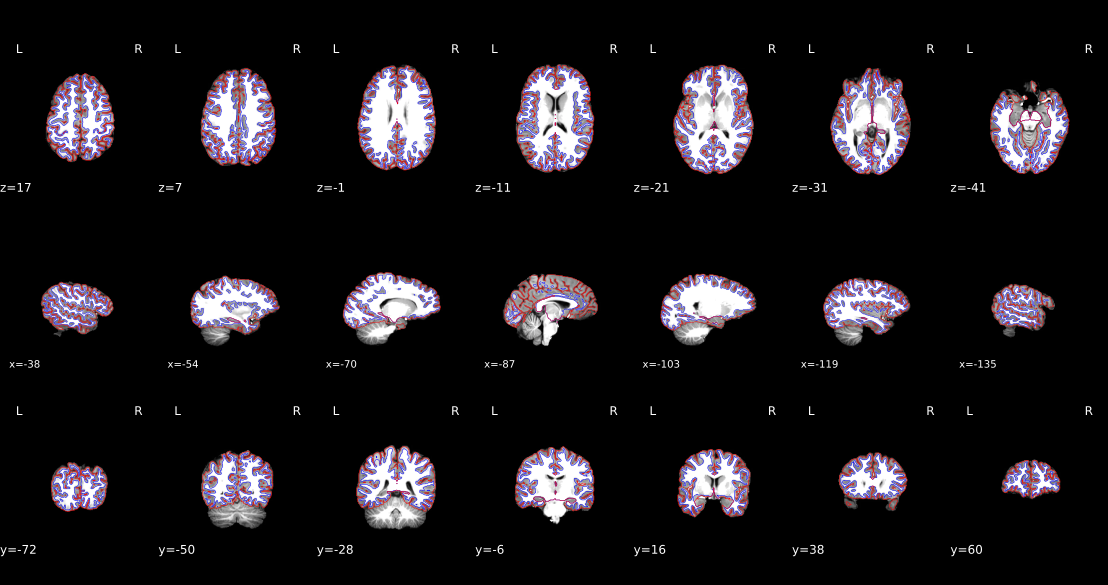

In [5]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_desc-reconall_T1w.svg')

### EPI-space to T1-space

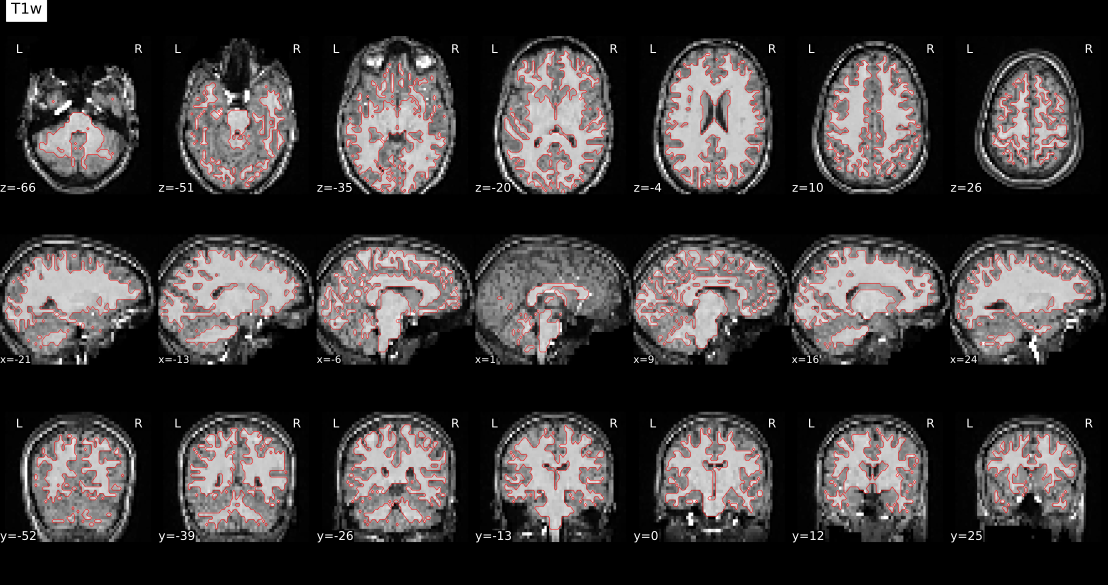

In [6]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_task-flanker_run-1_desc-coreg_bold.svg')

## Brain mask and (anatomical/temporal) CompCor ROIs
Brain mask calculated on the BOLD signal (red contour), along with the regions of interest (ROIs) used for the estimation of physiological and movement confounding components that can be then used as nuisance regressors in analysis.
The anatomical CompCor ROI (magenta contour) is a mask combining CSF and WM (white-matter), where voxels containing a minimal partial volume of GM have been removed.
The temporal CompCor ROI (blue contour) contains the top 2% most variable voxels within the brain mask.
The brain edge (or crown) ROI (green contour) picks signals outside but close to the brain, which are decomposed into 24 principal components.

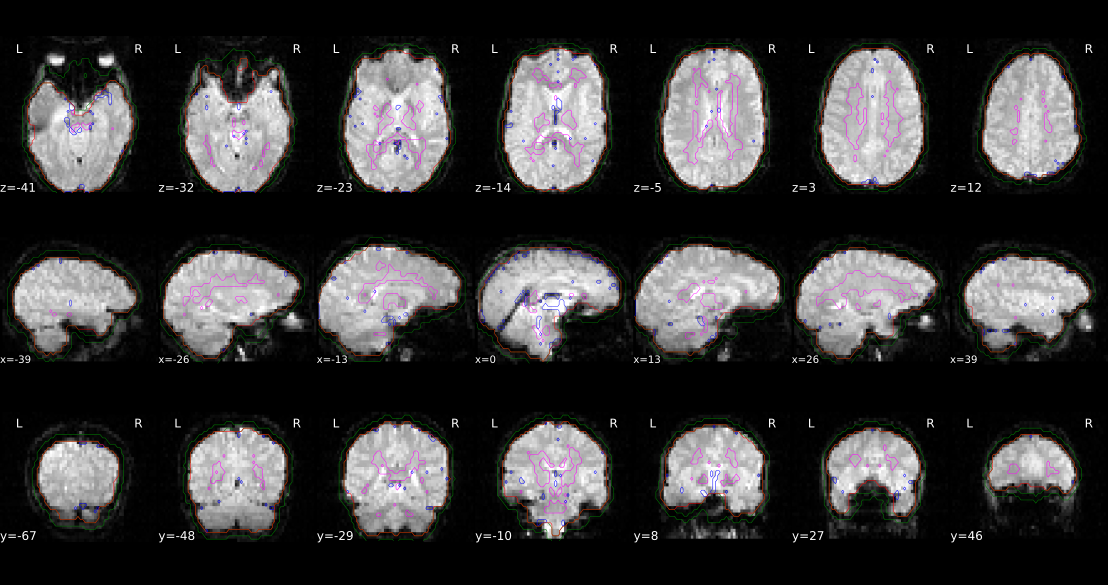

In [7]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_task-flanker_run-1_desc-rois_bold.svg')

### Bold Summary
Summary statistics are plotted, which may reveal trends or artifacts in the BOLD data. Global signals calculated within the whole-brain (GS), within the white-matter (WM) and within cerebro-spinal fluid (CSF) show the mean BOLD signal in their corresponding masks. DVARS and FD show the standardized DVARS and framewise-displacement measures for each time point.
A carpet plot shows the time series for all voxels within the brain mask, or if --cifti-output was enabled, all grayordinates. Voxels are grouped into cortical (dark/light blue), and subcortical (orange) gray matter, cerebellum (green) and white matter and CSF (red), indicated by the color map on the left-hand side.

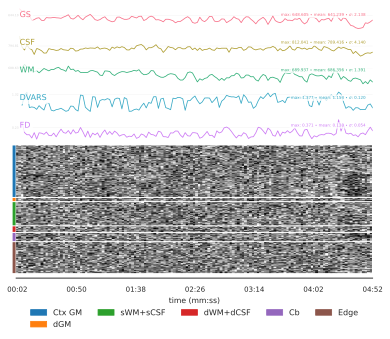

In [8]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_task-flanker_run-1_desc-carpetplot_bold.svg')

#### Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [2]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-04-09T04:35:09.455308+00:00

Python implementation: CPython
Python version       : 3.13.11
IPython version      : 9.9.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-173-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 30
Architecture: 64bit

IPython: 9.9.0

Neurodesktop version: 2026-03-27
